# Classification Robuste et Analyse de Decision en Environnement Critique
## Detection de Fraudes Bancaires — Credit Card Fraud Detection (Kaggle)

**Auteur :** Mustapha EL MIFDALI, Hicham Ouaouche, ILYAS MOUSSNAOUI, ABOUBAKER ID HAMIDE    |  **Module :** Intelligence Artificielle  |  **2025-2026**

---
Dataset : **284 807 transactions** | Ratio de desequilibre : **578:1**

Ce notebook contient les **4 etapes** du projet, entierement executees avec toutes les figures :
1. **EDA & Preparation** — Analyse exploratoire, feature engineering, gestion du desequilibre
2. **Modeles** — Logistic Regression (Elastic Net), Random Forest, XGBoost + Optuna (50 trials)
3. **Evaluation & Calibration** — F1-Macro, AUPRC, MCC, Platt Scaling, Isotonic Regression
4. **Interpretabilite SHAP** — Explications globales et individuelles



---
# Etape 1 : Analyse Exploratoire et Preparation des Donnees

*EDA, feature engineering (7 variables), analyse VIF, 4 methodes de desequilibre*


In [1]:
import sys


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss
from matplotlib.patches import Patch
import pickle

# ─── Chemins ─────────────────────────────────────────────────────────────────
ROOT       = ROOT
DATA_PATH  = ROOT / "data" / "creditcard.csv"
FIG_DIR    = ROOT / "etape1_eda" / "figures"   # ← figures dans le dossier de l'étape
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_PICKLE = ROOT / "etape1_eda" / "prepared_data.pkl"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
C = {
    "maj":    "#4C72B0",
    "min":    "#DD8452",
    "green":  "#2ecc71",
    "purple": "#9b59b6",
    "red":    "#e74c3c",
    "orange": "#f39c12",
    "teal":   "#1abc9c",
    "dark":   "#2c3e50",
}

def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print(f"  ✓ {name}  →  {path}")

# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("ÉTAPE 1 – EDA et Préparation")
print("=" * 65)

df = pd.read_csv(DATA_PATH)
print(f"Shape : {df.shape}")
print(f"Valeurs nulles : {df.isnull().sum().sum()}")
vc = df["Class"].value_counts()
print(f"\nDistribution des classes :\n{vc}")
print(f"Ratio déséquilibre : {vc[0]/vc[1]:.0f}:1")

df_legit = df[df["Class"] == 0]
df_fraud = df[df["Class"] == 1]

NameError: name 'ROOT' is not defined

### FIG 01 – Distribution des classes

  ✓ fig01_class_distribution.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig01_class_distribution.png


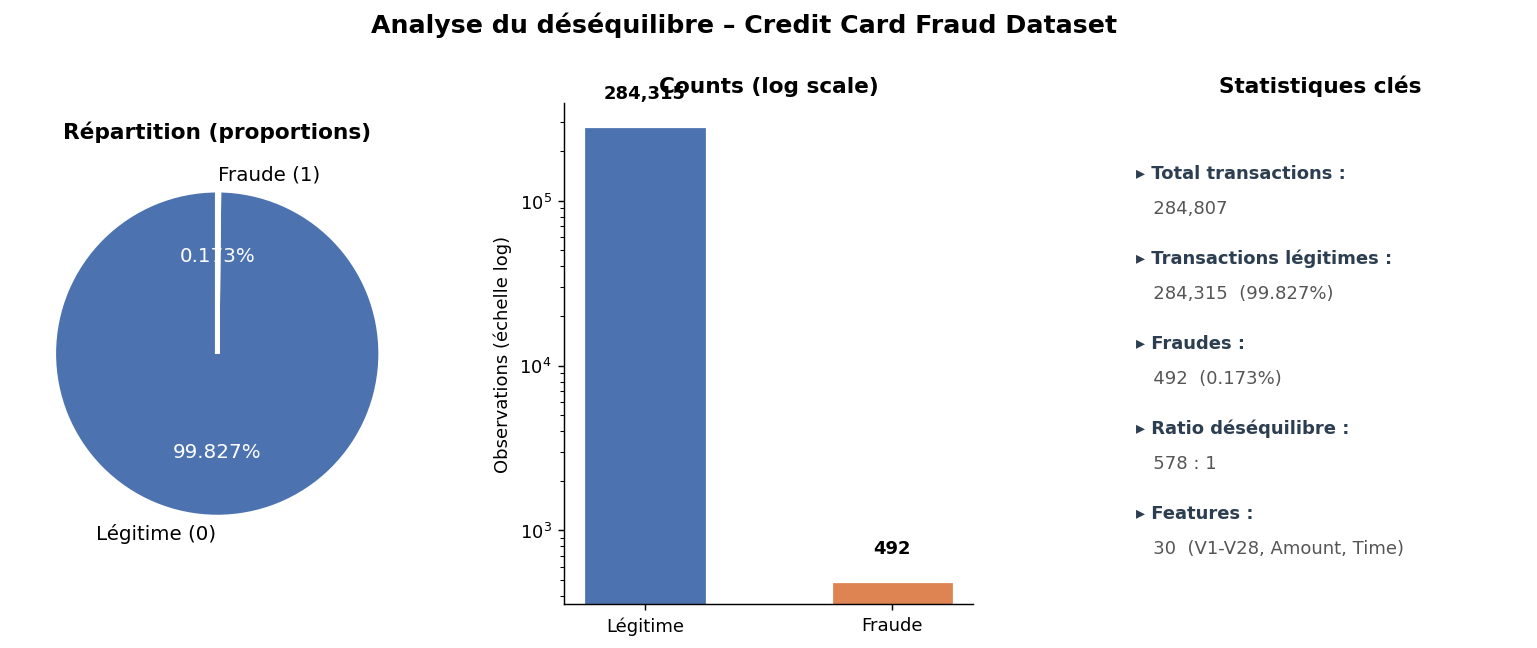

In [ ]:
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Pie
ax0 = fig.add_subplot(gs[0])
wedges, texts, autotexts = ax0.pie(
    vc.values, labels=["Légitime (0)", "Fraude (1)"],
    colors=[C["maj"], C["min"]],
    autopct="%1.3f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 11},
)
autotexts[0].set_color("white"); autotexts[1].set_color("white")
ax0.set_title("Répartition (proportions)", fontsize=12, fontweight="bold")

# Bar (log)
ax1 = fig.add_subplot(gs[1])
bars = ax1.bar(["Légitime", "Fraude"], vc.values,
               color=[C["maj"], C["min"]], width=0.5,
               edgecolor="white", linewidth=1.8)
ax1.set_yscale("log")
ax1.set_ylabel("Observations (échelle log)")
ax1.set_title("Counts (log scale)", fontsize=12, fontweight="bold")
for bar, v in zip(bars, vc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.4,
             f"{v:,}", ha="center", va="bottom", fontweight="bold")

# Donut + ratio
ax2 = fig.add_subplot(gs[2])
ax2.axis("off")
ratio = vc[0] / vc[1]
info = [
    ("Total transactions",    f"{len(df):,}"),
    ("Transactions légitimes",f"{vc[0]:,}  ({vc[0]/len(df)*100:.3f}%)"),
    ("Fraudes",               f"{vc[1]:,}  ({vc[1]/len(df)*100:.3f}%)"),
    ("Ratio déséquilibre",    f"{ratio:.0f} : 1"),
    ("Features",              f"{df.shape[1]-1}  (V1-V28, Amount, Time)"),
]
y_pos = 0.85
for label, val in info:
    ax2.text(0.05, y_pos, f"▸ {label} :", fontsize=10,
             fontweight="bold", transform=ax2.transAxes, color=C["dark"])
    ax2.text(0.05, y_pos - 0.07, f"   {val}", fontsize=10,
             transform=ax2.transAxes, color="#555")
    y_pos -= 0.17

ax2.set_title("Statistiques clés", fontsize=12, fontweight="bold")

plt.suptitle("Analyse du déséquilibre – Credit Card Fraud Dataset",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "fig01_class_distribution.png")
plt.show()

### FIG 02 – Amount & Time

  ✓ fig02_amount_time_analysis.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig02_amount_time_analysis.png


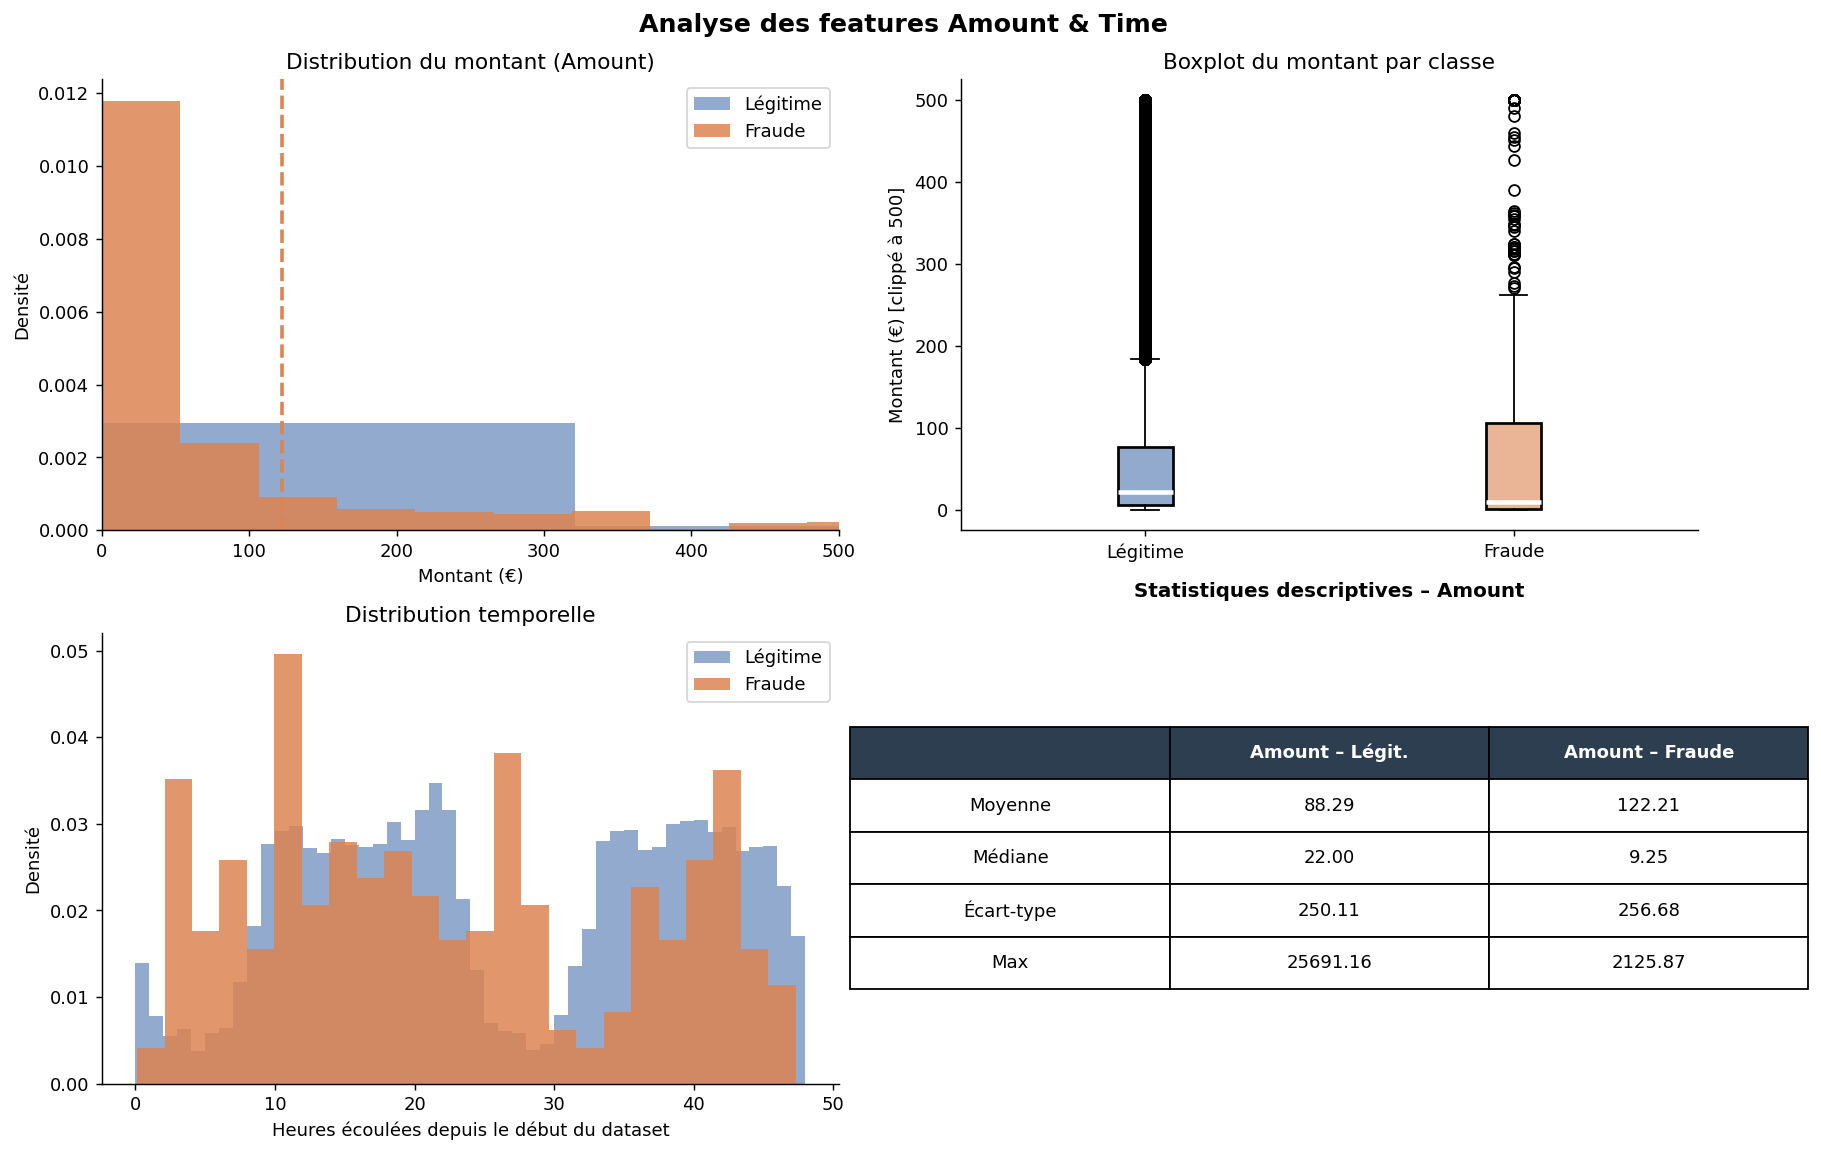

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Amount hist
ax = axes[0, 0]
ax.hist(df_legit["Amount"], bins=80, color=C["maj"], alpha=0.6,
        label="Légitime", density=True)
ax.hist(df_fraud["Amount"], bins=40, color=C["min"], alpha=0.85,
        label="Fraude", density=True)
ax.set_xlabel("Montant (€)"); ax.set_ylabel("Densité")
ax.set_xlim(0, 500); ax.legend()
ax.set_title("Distribution du montant (Amount)")
ax.axvline(df_fraud["Amount"].mean(), color=C["min"], lw=2, linestyle="--",
           label=f"Moy. fraude = {df_fraud['Amount'].mean():.1f}€")

# Amount boxplot
ax = axes[0, 1]
bp = ax.boxplot(
    [df_legit["Amount"].clip(0, 500).values, df_fraud["Amount"].clip(0, 500).values],
    labels=["Légitime", "Fraude"], patch_artist=True,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color="white", linewidth=2.5),
)
bp["boxes"][0].set_facecolor(C["maj"] + "99")
bp["boxes"][1].set_facecolor(C["min"] + "99")
ax.set_ylabel("Montant (€) [clippé à 500]")
ax.set_title("Boxplot du montant par classe")

# Time hist
ax = axes[1, 0]
ax.hist(df_legit["Time"] / 3600, bins=48, color=C["maj"], alpha=0.6,
        label="Légitime", density=True)
ax.hist(df_fraud["Time"] / 3600, bins=24, color=C["min"], alpha=0.85,
        label="Fraude", density=True)
ax.set_xlabel("Temps (heures)"); ax.set_ylabel("Densité")
ax.legend(); ax.set_title("Distribution temporelle")
ax.set_xlabel("Heures écoulées depuis le début du dataset")

# Stats table
ax = axes[1, 1]
ax.axis("off")
stats = pd.DataFrame({
    "": ["Moyenne", "Médiane", "Écart-type", "Max"],
    "Amount – Légit.": [
        f"{df_legit['Amount'].mean():.2f}",
        f"{df_legit['Amount'].median():.2f}",
        f"{df_legit['Amount'].std():.2f}",
        f"{df_legit['Amount'].max():.2f}",
    ],
    "Amount – Fraude": [
        f"{df_fraud['Amount'].mean():.2f}",
        f"{df_fraud['Amount'].median():.2f}",
        f"{df_fraud['Amount'].std():.2f}",
        f"{df_fraud['Amount'].max():.2f}",
    ],
})
table = ax.table(cellText=stats.values, colLabels=stats.columns,
                 loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1.3, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(C["dark"])
        cell.set_text_props(color="white", fontweight="bold")
ax.set_title("Statistiques descriptives – Amount", pad=20, fontsize=11, fontweight="bold")

plt.suptitle("Analyse des features Amount & Time", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig02_amount_time_analysis.png")
plt.show()

### Feature engineering + Split stratifié + normalisation + sélection

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

def add_engineered_features(X_df):
    X_fe = X_df.copy()
    # Dataset déjà numérique : encodage non nécessaire, on enrichit via transformations.
    hours = (X_fe["Time"] / 3600.0) % 24.0
    X_fe["Amount_log1p"] = np.log1p(np.clip(X_fe["Amount"], a_min=0, a_max=None))
    X_fe["Amount_sq"] = X_fe["Amount"] ** 2
    X_fe["Time_sin"] = np.sin(2 * np.pi * hours / 24.0)
    X_fe["Time_cos"] = np.cos(2 * np.pi * hours / 24.0)
    X_fe["V1_V2_inter"] = X_fe["V1"] * X_fe["V2"]
    X_fe["V14_V17_inter"] = X_fe["V14"] * X_fe["V17"]
    return X_fe

X_train = add_engineered_features(X_train)
X_test  = add_engineered_features(X_test)

scale_cols = ["Amount", "Time", "Amount_log1p", "Amount_sq"]
scaler = StandardScaler()
X_train.loc[:, scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test.loc[:, scale_cols] = scaler.transform(X_test[scale_cols])

mi_sample_n = min(60000, len(X_train))
mi_idx = np.random.choice(len(X_train), mi_sample_n, replace=False)
mi_vals = mutual_info_classif(
    X_train.iloc[mi_idx], y_train.iloc[mi_idx], random_state=RANDOM_STATE
)
mi_series = pd.Series(mi_vals, index=X_train.columns).sort_values(ascending=False)

required_feats = ["V14", "V17", "V12", "V10", "V16", "Amount", "Time"]
selected_features = mi_series.head(min(30, len(mi_series))).index.tolist()
for feat in required_feats:
    if feat in X_train.columns and feat not in selected_features:
        selected_features.append(feat)

X_train = X_train[selected_features].copy()
X_test = X_test[selected_features].copy()

print("\nFeature engineering avancé : 7 variables créées (encodage non applicable au dataset).")
print(f"Mutual Information calculée sur un échantillon de {mi_sample_n:,} observations.")
print(f"Sélection statistique (Mutual Information) : {len(selected_features)} features conservées.")
print("Top 8 MI :")
print(mi_series.head(8).round(5).to_string())

print(f"\nTrain : {X_train.shape} | Test : {X_test.shape}")
print(f"Fraudes train : {y_train.sum()} ({y_train.mean():.4%})")


Feature engineering avancé : 7 variables créées (encodage non applicable au dataset).
Mutual Information calculée sur un échantillon de 60,000 observations.
Sélection statistique (Mutual Information) : 30 features conservées.
Top 8 MI :
V14_V17_inter    0.00676
V17              0.00641
V14              0.00620
V12              0.00598
V10              0.00593
V11              0.00512
V16              0.00424
V4               0.00384

Train : (227845, 30) | Test : (56962, 30)
Fraudes train : 394 (0.1729%)


### FIG 03 – Matrice de corrélation

  ✓ fig03_correlation_matrix.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig03_correlation_matrix.png


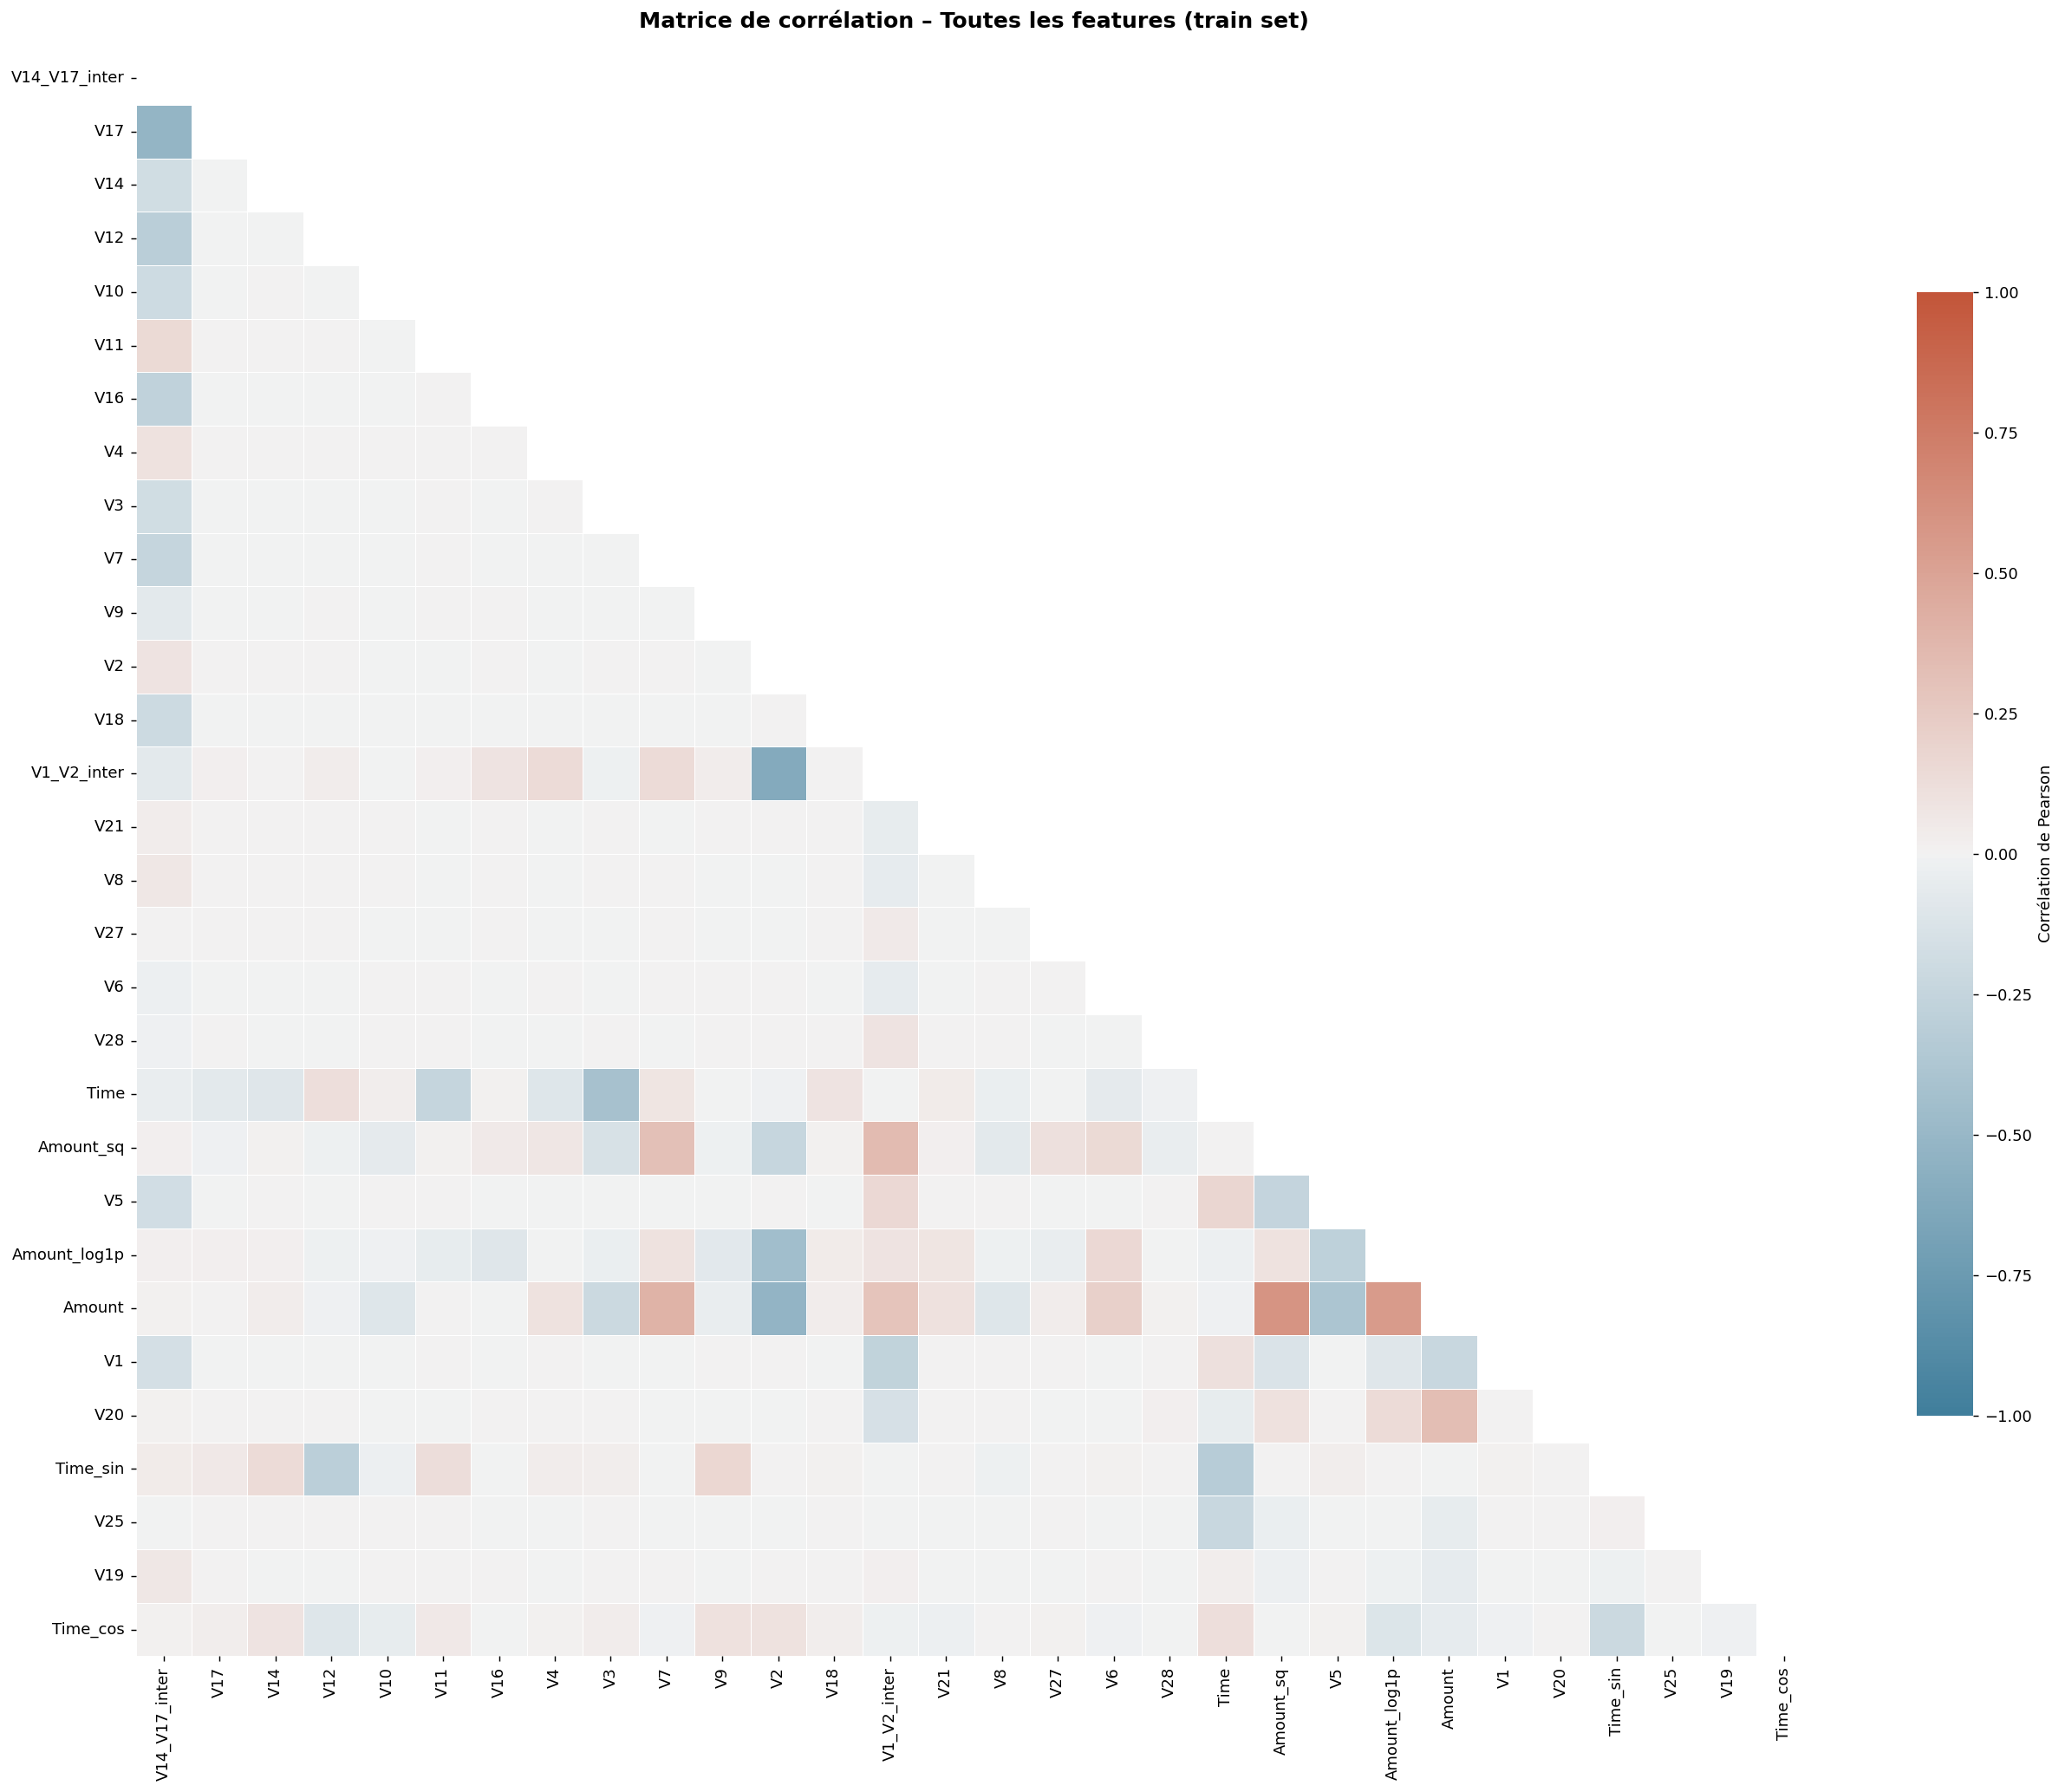

In [ ]:
fig, ax = plt.subplots(figsize=(20, 16))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.7, "label": "Corrélation de Pearson"})
ax.set_title("Matrice de corrélation – Toutes les features (train set)",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
save_fig(fig, "fig03_correlation_matrix.png")
plt.show()

### FIG 04 – Corrélations avec la target

  ✓ fig04_correlation_with_target.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig04_correlation_with_target.png


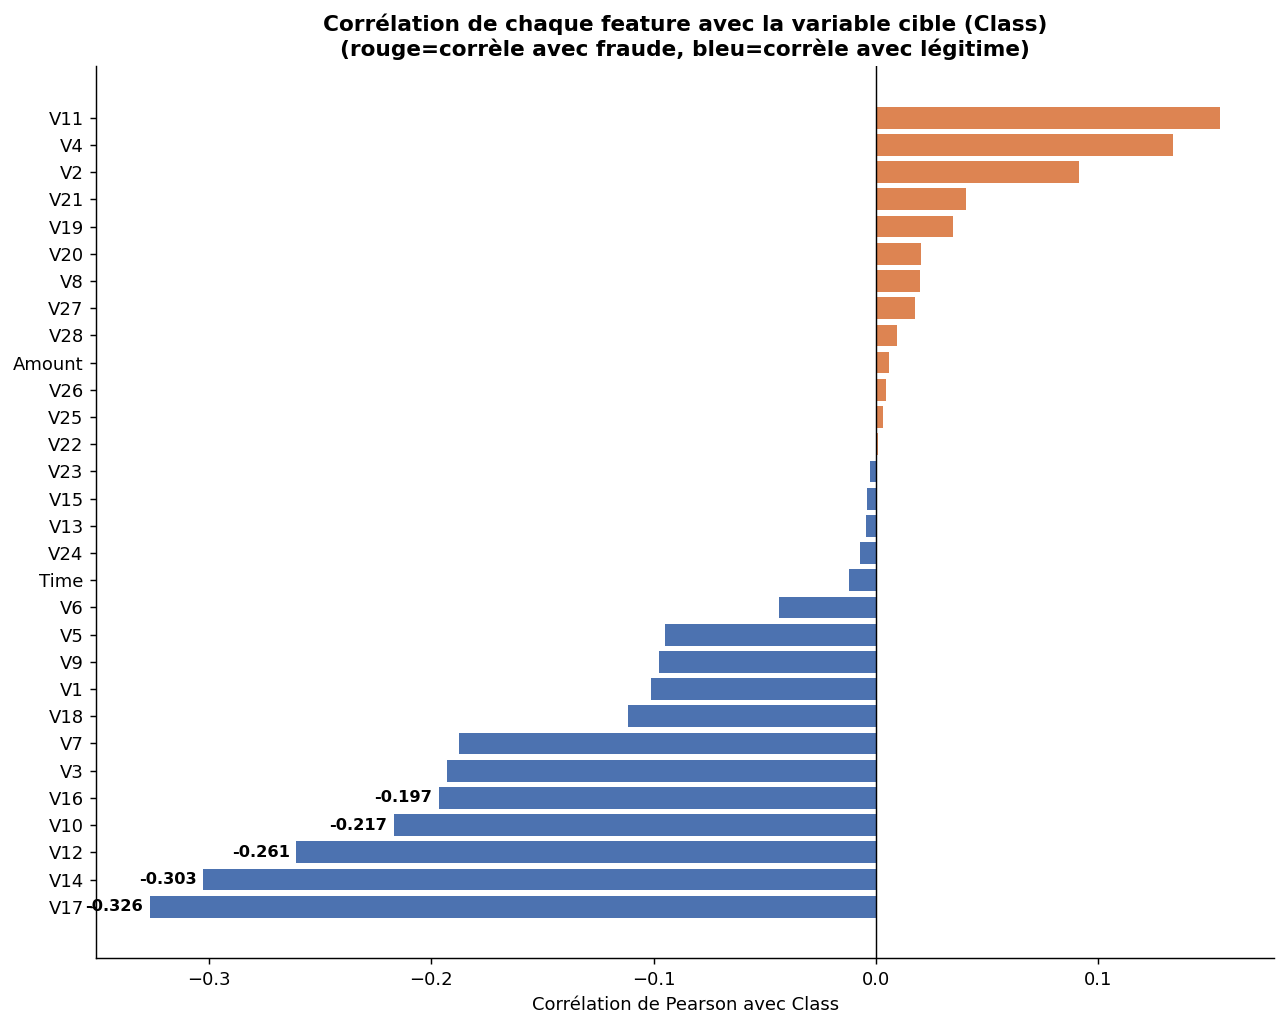

In [ ]:
corr_target = df.corr()["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
colors_c = [C["min"] if v > 0 else C["maj"] for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors_c)
ax.axvline(0, color="black", linewidth=0.8)

top5 = corr_target.abs().nlargest(5).index
for feat in top5:
    val = corr_target[feat]
    ax.text(val + (0.003 if val >= 0 else -0.003),
            list(corr_target.index).index(feat),
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9, fontweight="bold")

ax.set_xlabel("Corrélation de Pearson avec Class")
ax.set_title("Corrélation de chaque feature avec la variable cible (Class)\n"
             "(rouge=corrèle avec fraude, bleu=corrèle avec légitime)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig04_correlation_with_target.png")
plt.show()

### VIF

In [ ]:
print("\n─── Calcul du VIF ───")
sample_vif = X_train.sample(5000, random_state=RANDOM_STATE).reset_index(drop=True)
vif_data = pd.DataFrame({
    "Feature": sample_vif.columns,
    "VIF": [variance_inflation_factor(sample_vif.values, i)
            for i in range(sample_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_data.head(10).to_string(index=False))


─── Calcul du VIF ───
     Feature       VIF
      Amount 16.798265
          V2  7.624233
   Amount_sq  5.658412
 V1_V2_inter  4.549006
          V7  3.593047
          V5  2.548928
Amount_log1p  2.403771
         V20  2.004744
          V1  1.996997
          V3  1.965679


### FIG 05 – VIF

  ✓ fig05_vif.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig05_vif.png


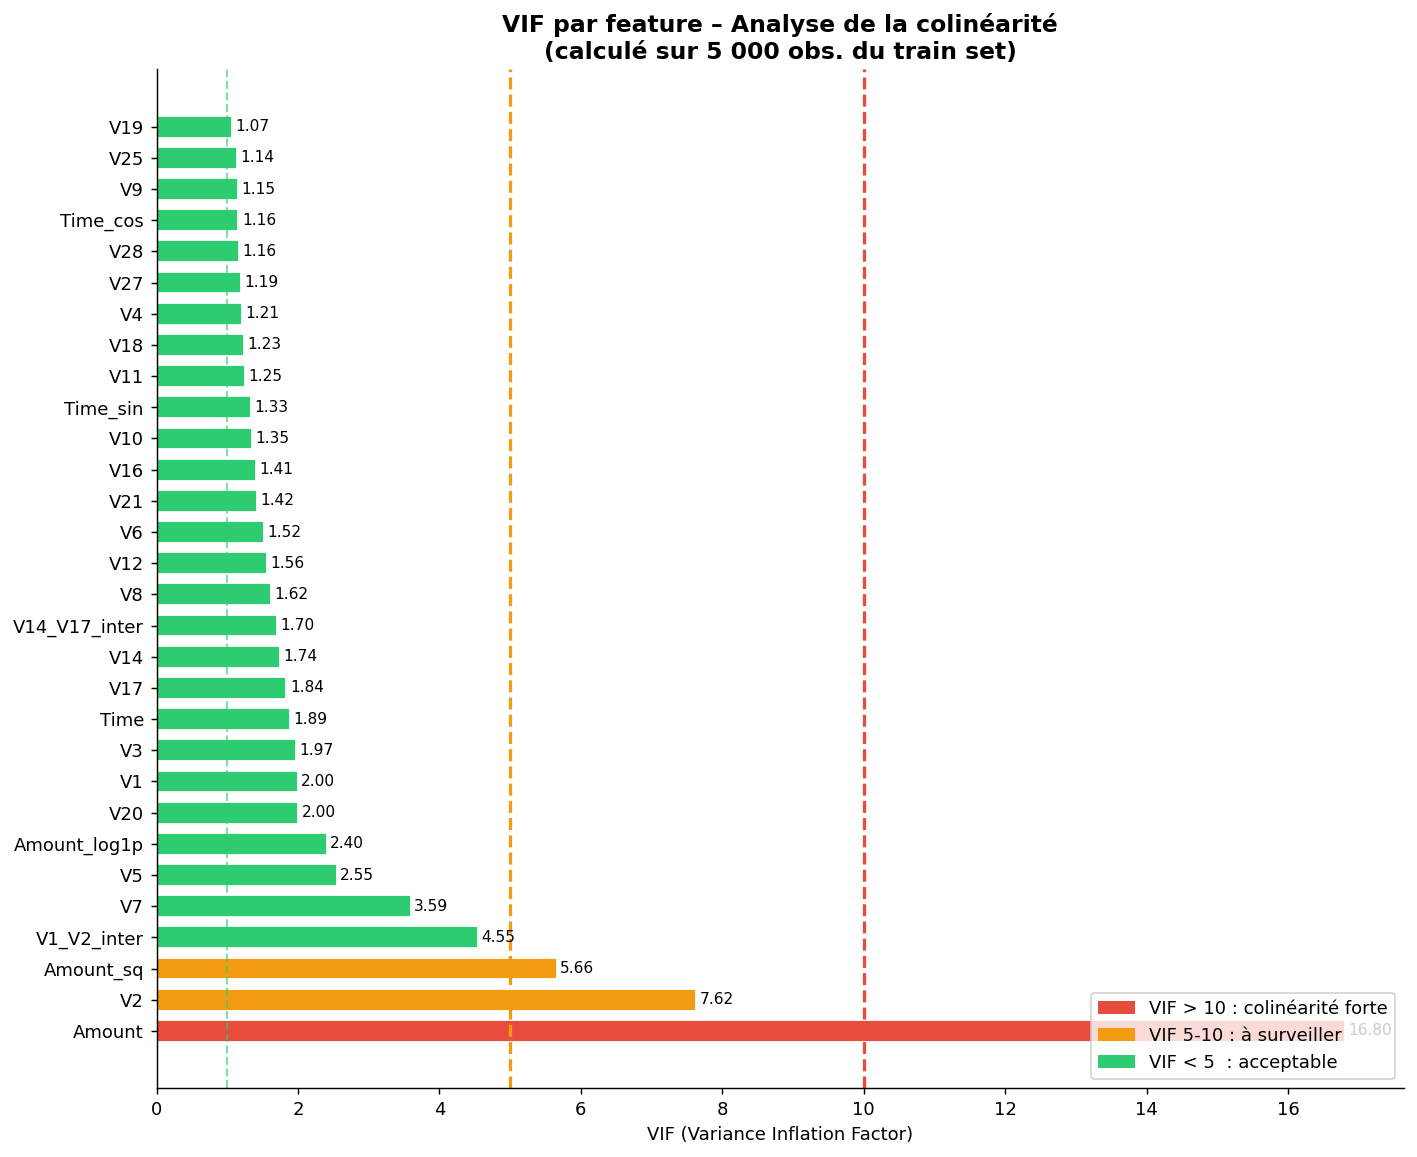

In [ ]:
def color_vif(v):
    if v > 10: return C["red"]
    if v > 5:  return C["orange"]
    return C["green"]

fig, ax = plt.subplots(figsize=(11, 9))
colors_vif = [color_vif(v) for v in vif_data["VIF"]]
bars = ax.barh(vif_data["Feature"], vif_data["VIF"],
               color=colors_vif, edgecolor="white", height=0.7)
ax.axvline(10, color=C["red"],    linestyle="--", linewidth=1.8)
ax.axvline(5,  color=C["orange"], linestyle="--", linewidth=1.8)
ax.axvline(1,  color=C["green"],  linestyle="--", linewidth=1.2, alpha=0.6)

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=8.5)

legend_els = [
    Patch(facecolor=C["red"],    label="VIF > 10 : colinéarité forte"),
    Patch(facecolor=C["orange"], label="VIF 5-10 : à surveiller"),
    Patch(facecolor=C["green"],  label="VIF < 5  : acceptable"),
]
ax.legend(handles=legend_els, loc="lower right", fontsize=10)
ax.set_xlabel("VIF (Variance Inflation Factor)")
ax.set_title("VIF par feature – Analyse de la colinéarité\n(calculé sur 5 000 obs. du train set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig05_vif.png")
plt.show()

### GESTION DU DÉSÉQUILIBRE – 4 méthodes

In [ ]:
print("\n─── Calcul des 4 méthodes de gestion du déséquilibre ───")

# Méthode 1 : class_weight='balanced' (niveau algorithmique)
cw_arr  = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw_arr))
print(f"[1] Class weights : {cw_dict}")

# Méthode 2 : SMOTE (sur-échantillonnage synthétique)
print("[2] SMOTE …")
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_tr_smote, y_tr_smote = smote.fit_resample(X_train, y_train)
print(f"    Shape : {X_tr_smote.shape} | fraudes : {y_tr_smote.sum()}")

# Méthode 3 : ADASYN (sur-échantillonnage adaptatif)
print("[3] ADASYN …")
adasyn = ADASYN(random_state=RANDOM_STATE, n_neighbors=5)
X_tr_adasyn, y_tr_adasyn = adasyn.fit_resample(X_train, y_train)
print(f"    Shape : {X_tr_adasyn.shape} | fraudes : {y_tr_adasyn.sum()}")

# Méthode 4 : NearMiss (sous-échantillonnage)
print("[4] NearMiss …")
nm = NearMiss(version=1, n_neighbors=3)
X_tr_nm, y_tr_nm = nm.fit_resample(X_train, y_train)
print(f"    Shape : {X_tr_nm.shape} | fraudes : {y_tr_nm.sum()}")


─── Calcul des 4 méthodes de gestion du déséquilibre ───
[1] Class weights : {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}
[2] SMOTE …
    Shape : (454902, 30) | fraudes : 227451
[3] ADASYN …
    Shape : (454908, 30) | fraudes : 227457
[4] NearMiss …
    Shape : (788, 30) | fraudes : 394


### FIG 06 – Comparaison des 4 méthodes (vue globale)

  ✓ fig06_imbalance_methods_comparison.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig06_imbalance_methods_comparison.png


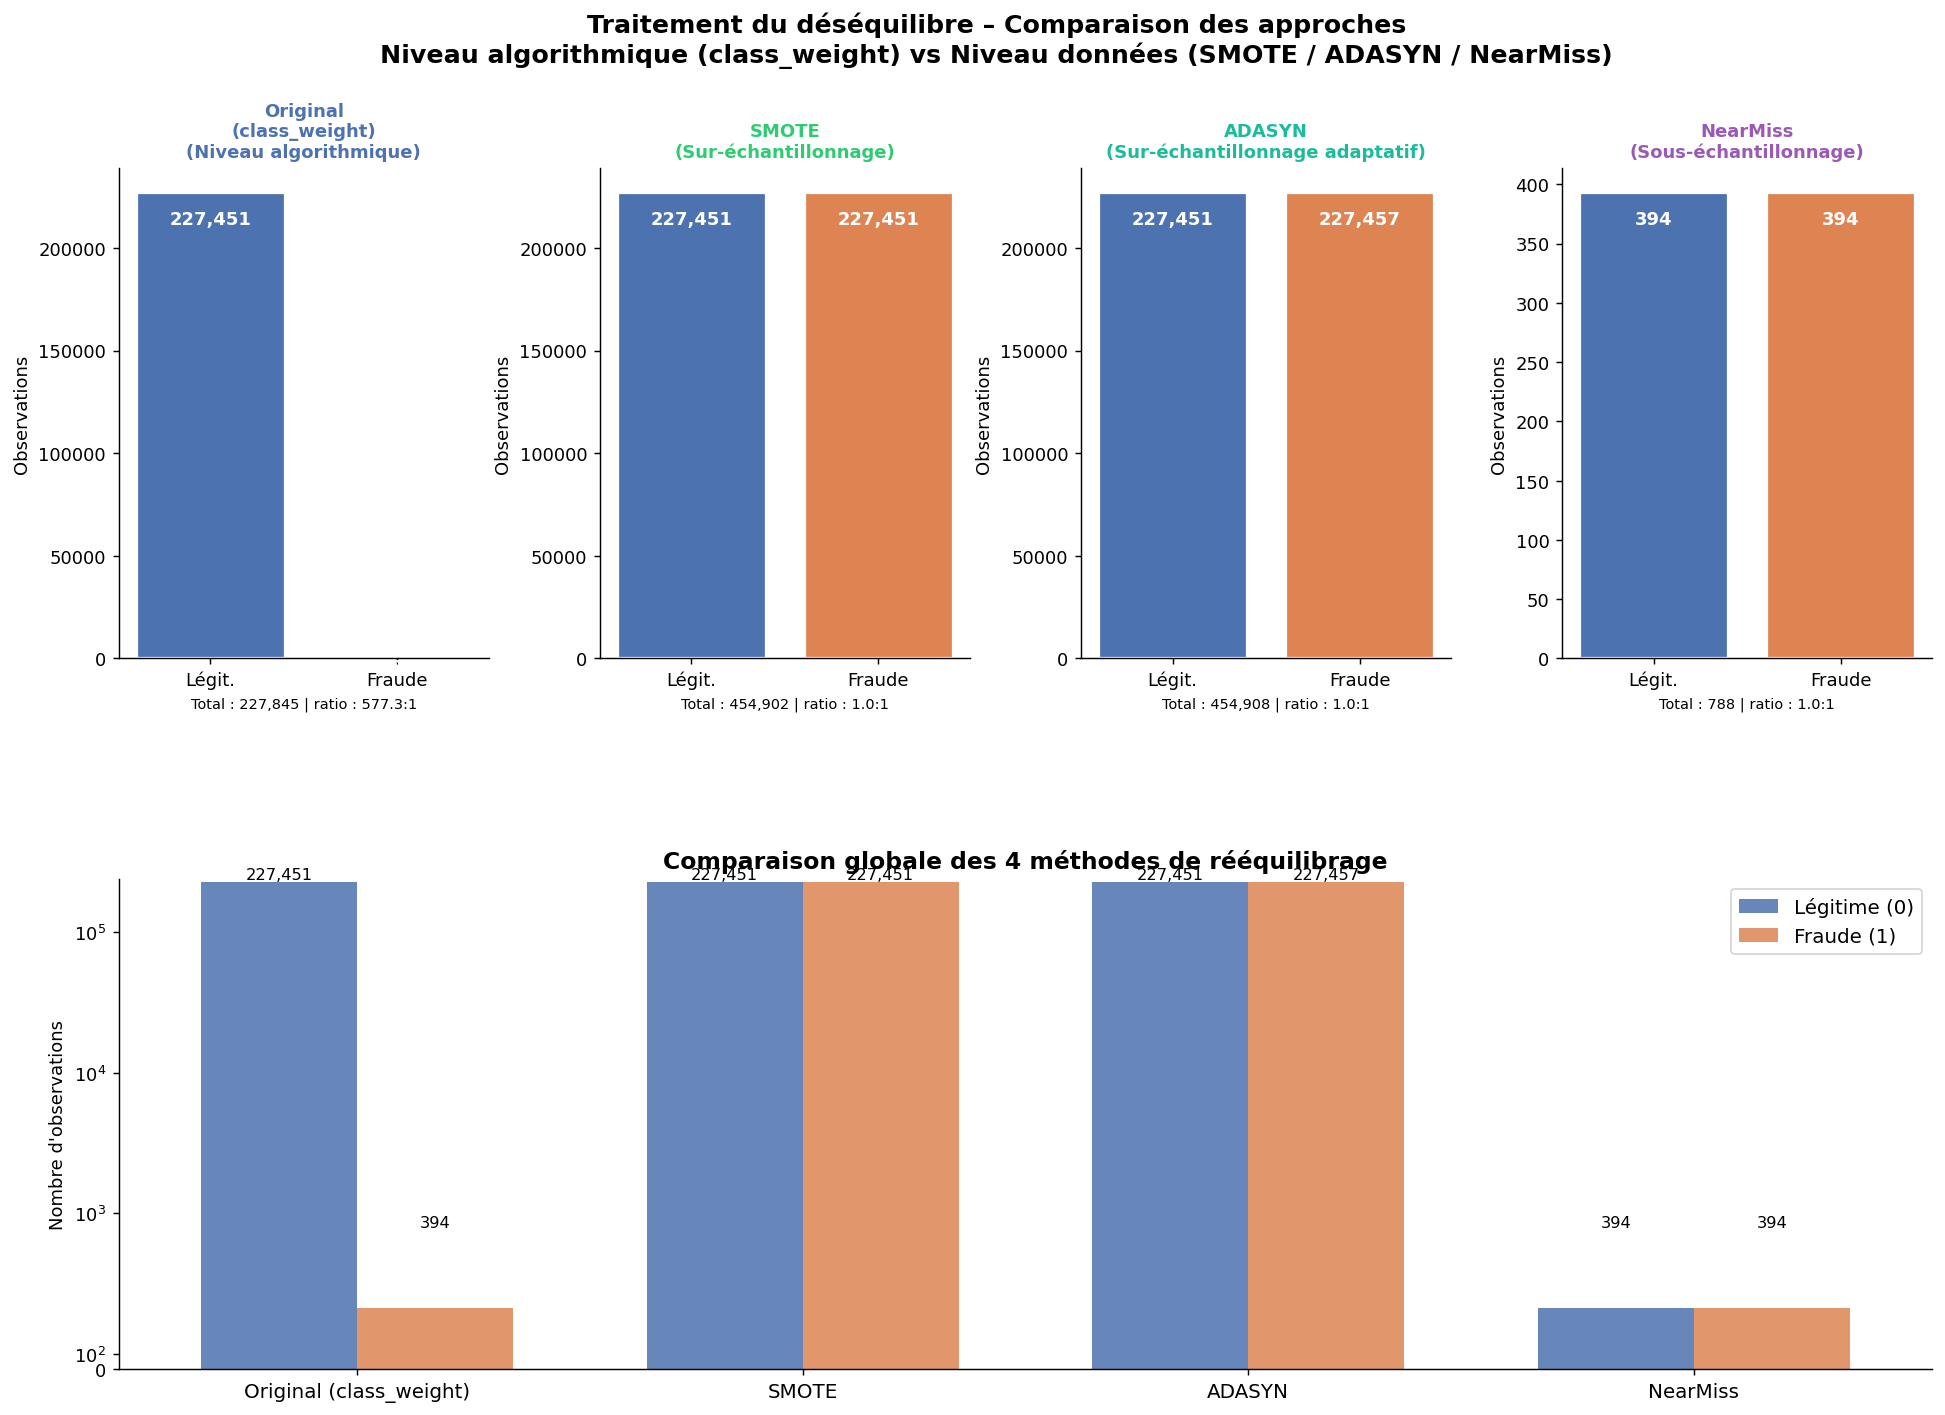

In [ ]:
methods_info = [
    ("Original\n(class_weight)", y_train,     C["maj"],    "Niveau algorithmique"),
    ("SMOTE",                    y_tr_smote,  C["green"],  "Sur-échantillonnage"),
    ("ADASYN",                   C["teal"],   C["teal"],   "Sur-échantillonnage"),
    ("NearMiss",                 y_tr_nm,     C["purple"], "Sous-échantillonnage"),
]

# Compter classe 0 et 1 pour chaque méthode
counts_list = [
    ("Original\n(class_weight)", pd.Series(y_train).value_counts(),       "Niveau algorithmique"),
    ("SMOTE",                    pd.Series(y_tr_smote).value_counts(),    "Sur-échantillonnage"),
    ("ADASYN",                   pd.Series(y_tr_adasyn).value_counts(),   "Sur-échantillonnage adaptatif"),
    ("NearMiss",                 pd.Series(y_tr_nm).value_counts(),       "Sous-échantillonnage"),
]

colors_methods = [C["maj"], C["green"], C["teal"], C["purple"]]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.3)

# Ligne 1 : barchart par méthode
for col_i, (name, counts_m, desc) in enumerate(counts_list):
    ax = fig.add_subplot(gs[0, col_i])
    c0 = counts_m.get(0, 0)
    c1 = counts_m.get(1, 0)
    b = ax.bar(["Légit.", "Fraude"], [c0, c1],
               color=[C["maj"], C["min"]], edgecolor="white", linewidth=1.8)
    for bar, val in zip(b, [c0, c1]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 0.96,
                f"{val:,}", ha="center", va="top",
                color="white", fontweight="bold", fontsize=10)
    ax.set_title(f"{name}\n({desc})", fontsize=10, fontweight="bold",
                 color=colors_methods[col_i])
    ax.set_ylabel("Observations")
    total = c0 + c1
    ratio_local = c0 / max(c1, 1)
    ax.set_xlabel(f"Total : {total:,} | ratio : {ratio_local:.1f}:1", fontsize=8)

# Ligne 2 : comparaison synthétique (grouped bar)
ax_comp = fig.add_subplot(gs[1, :])
method_names = [c[0].replace("\n", " ") for c in counts_list]
x_pos = np.arange(len(method_names))
w = 0.35
legit_counts  = [c[1].get(0, 0) for c in counts_list]
fraud_counts  = [c[1].get(1, 0) for c in counts_list]

b1 = ax_comp.bar(x_pos - w/2, legit_counts, width=w,
                 color=C["maj"], alpha=0.85, label="Légitime (0)")
b2 = ax_comp.bar(x_pos + w/2, fraud_counts, width=w,
                 color=C["min"], alpha=0.85, label="Fraude (1)")

for bar, val in zip(list(b1) + list(b2), legit_counts + fraud_counts):
    ax_comp.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

ax_comp.set_xticks(x_pos)
ax_comp.set_xticklabels(method_names, fontsize=11)
ax_comp.set_ylabel("Nombre d'observations")
ax_comp.set_title("Comparaison globale des 4 méthodes de rééquilibrage",
                  fontsize=13, fontweight="bold")
ax_comp.legend(fontsize=11)
ax_comp.set_yscale("symlog", linthresh=1000)

plt.suptitle("Traitement du déséquilibre – Comparaison des approches\n"
             "Niveau algorithmique (class_weight) vs Niveau données (SMOTE / ADASYN / NearMiss)",
             fontsize=14, fontweight="bold")
save_fig(fig, "fig06_imbalance_methods_comparison.png")
plt.show()

### FIG 07 – Détail SMOTE : espace original vs augmenté


─── Figures détail par méthode ───
  ✓ fig07_smote_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig07_smote_detail.png


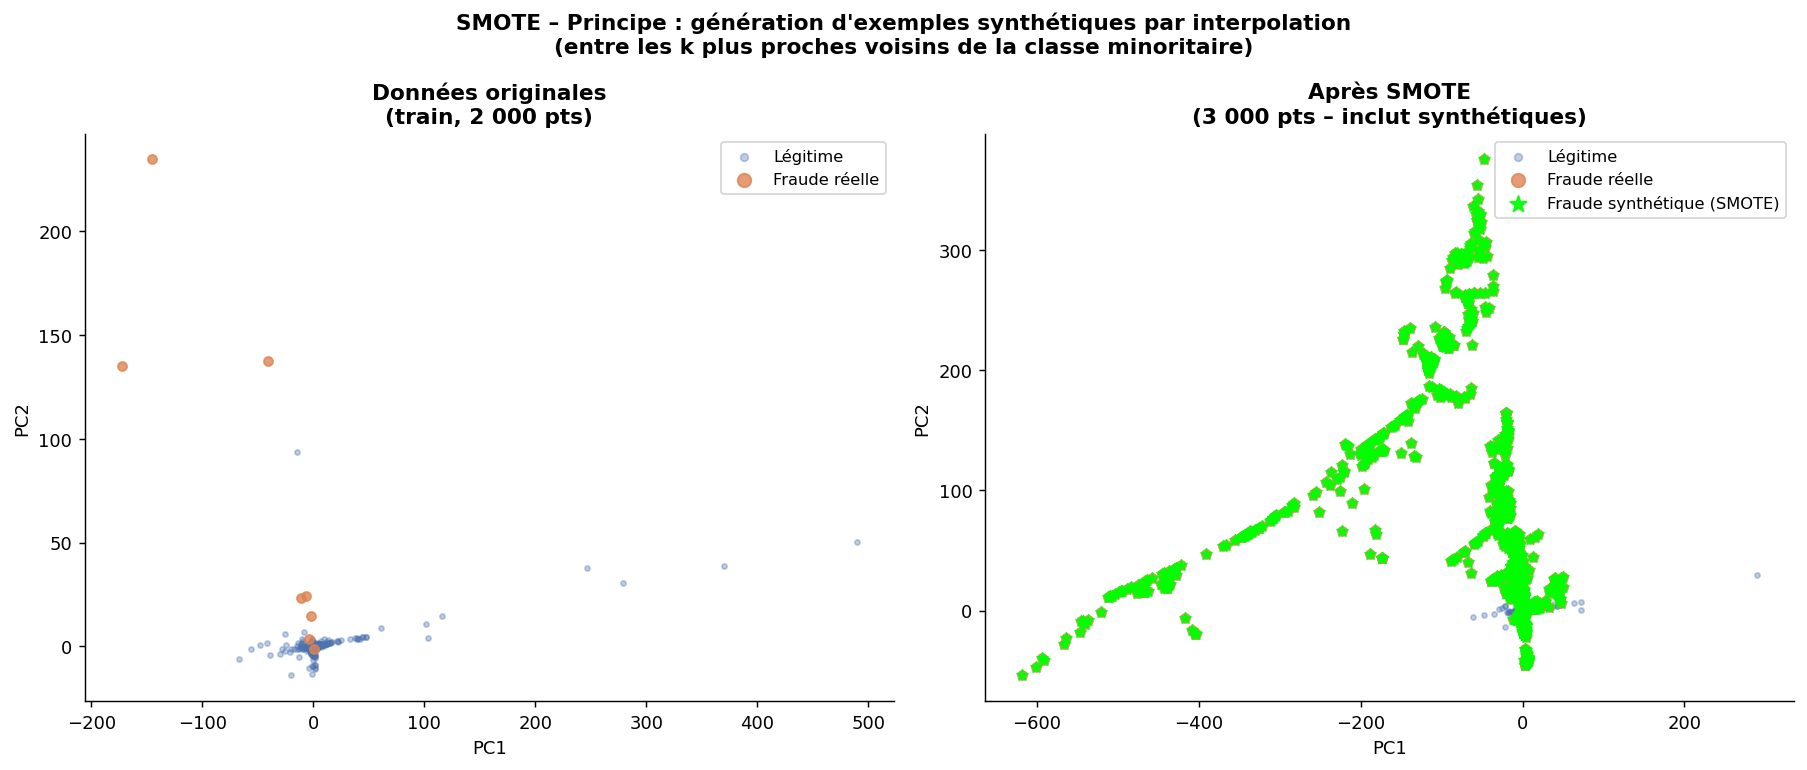

In [ ]:
print("\n─── Figures détail par méthode ───")

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)

# PCA sur le train original pour référence
# On refait proprement
idx_sample = np.random.choice(len(X_train), 2000, replace=False)
X_orig_2k  = X_train.iloc[idx_sample].values
y_orig_2k  = y_train.iloc[idx_sample].values
pca2.fit(X_orig_2k)
X_orig_pca = pca2.transform(X_orig_2k)

# SMOTE – échantillon
idx_smote = np.random.choice(len(X_tr_smote), min(3000, len(X_tr_smote)), replace=False)
X_smote_pca = pca2.transform(X_tr_smote.values[idx_smote])
y_smote_samp = y_tr_smote.values[idx_smote]

# Identifier les points synthétiques (approximation : ceux au-delà de l'index original)
n_orig_train = len(X_train)
synthetic_mask = idx_smote >= n_orig_train

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (X_pca, y_s, title, show_synth, s_mask) in zip(axes, [
    (X_orig_pca, y_orig_2k, "Données originales\n(train, 2 000 pts)", False, None),
    (X_smote_pca, y_smote_samp, "Après SMOTE\n(3 000 pts – inclut synthétiques)", True, synthetic_mask),
]):
    ax.scatter(X_pca[y_s==0, 0], X_pca[y_s==0, 1], c=C["maj"], s=8,
               alpha=0.35, label="Légitime")
    ax.scatter(X_pca[y_s==1, 0], X_pca[y_s==1, 1], c=C["min"], s=25,
               alpha=0.8, label="Fraude réelle")
    if show_synth and s_mask is not None:
        synth_fraud = (y_s == 1) & s_mask
        ax.scatter(X_pca[synth_fraud, 0], X_pca[synth_fraud, 1],
                   c="lime", s=40, alpha=0.9, marker="*",
                   label="Fraude synthétique (SMOTE)", zorder=5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=9, markerscale=1.5)

plt.suptitle("SMOTE – Principe : génération d'exemples synthétiques par interpolation\n"
             "(entre les k plus proches voisins de la classe minoritaire)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig07_smote_detail.png")
plt.show()

### FIG 08 – Détail ADASYN

  ✓ fig08_adasyn_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig08_adasyn_detail.png


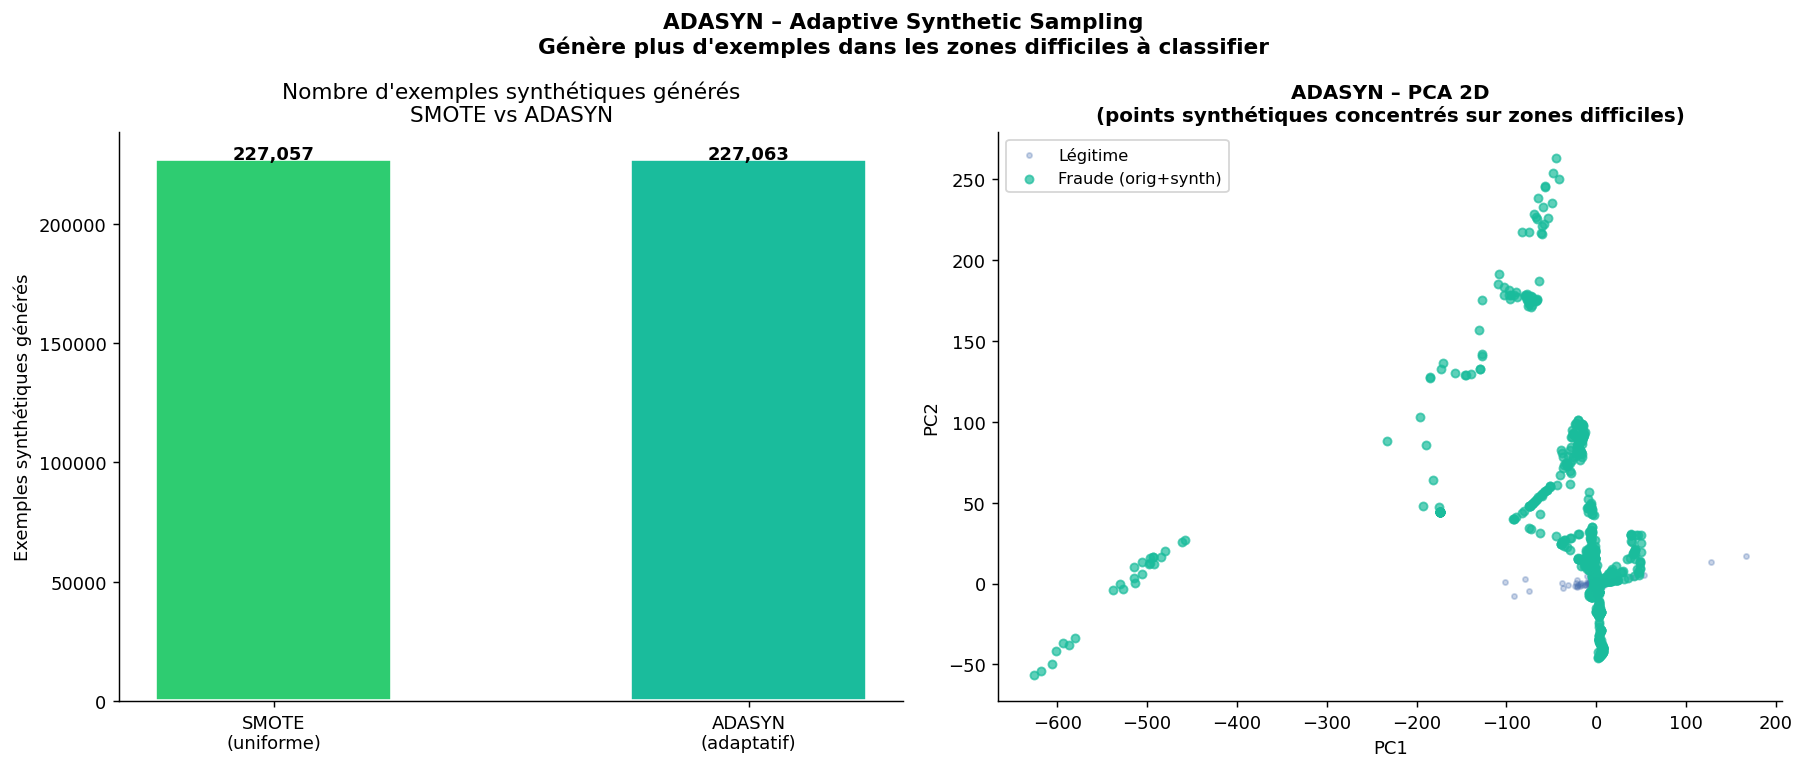

In [ ]:
idx_adasyn = np.random.choice(len(X_tr_adasyn), min(3000, len(X_tr_adasyn)), replace=False)
X_adasyn_pca = pca2.transform(X_tr_adasyn.values[idx_adasyn]
                               if hasattr(X_tr_adasyn, 'values') else X_tr_adasyn[idx_adasyn])
y_adasyn_samp = (y_tr_adasyn.values[idx_adasyn]
                  if hasattr(y_tr_adasyn, 'values') else y_tr_adasyn[idx_adasyn])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution du nombre de synthétiques par région (histogram)
ax = axes[0]
n_synth_adasyn = len(X_tr_adasyn) - n_orig_train
n_synth_smote  = len(X_tr_smote)  - n_orig_train
ax.bar(["SMOTE\n(uniforme)", "ADASYN\n(adaptatif)"],
       [n_synth_smote, n_synth_adasyn],
       color=[C["green"], C["teal"]], edgecolor="white", linewidth=2, width=0.5)
ax.set_ylabel("Exemples synthétiques générés")
ax.set_title("Nombre d'exemples synthétiques générés\nSMOTE vs ADASYN")
for x, val in enumerate([n_synth_smote, n_synth_adasyn]):
    ax.text(x, val + 50, f"{val:,}", ha="center", fontweight="bold")

# PCA ADASYN
ax = axes[1]
ax.scatter(X_adasyn_pca[y_adasyn_samp==0, 0], X_adasyn_pca[y_adasyn_samp==0, 1],
           c=C["maj"], s=8, alpha=0.3, label="Légitime")
ax.scatter(X_adasyn_pca[y_adasyn_samp==1, 0], X_adasyn_pca[y_adasyn_samp==1, 1],
           c=C["teal"], s=20, alpha=0.7, label="Fraude (orig+synth)")
ax.set_title("ADASYN – PCA 2D\n(points synthétiques concentrés sur zones difficiles)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9)

plt.suptitle("ADASYN – Adaptive Synthetic Sampling\n"
             "Génère plus d'exemples dans les zones difficiles à classifier",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig08_adasyn_detail.png")
plt.show()

### FIG 09 – Détail NearMiss

  ✓ fig09_nearmiss_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig09_nearmiss_detail.png


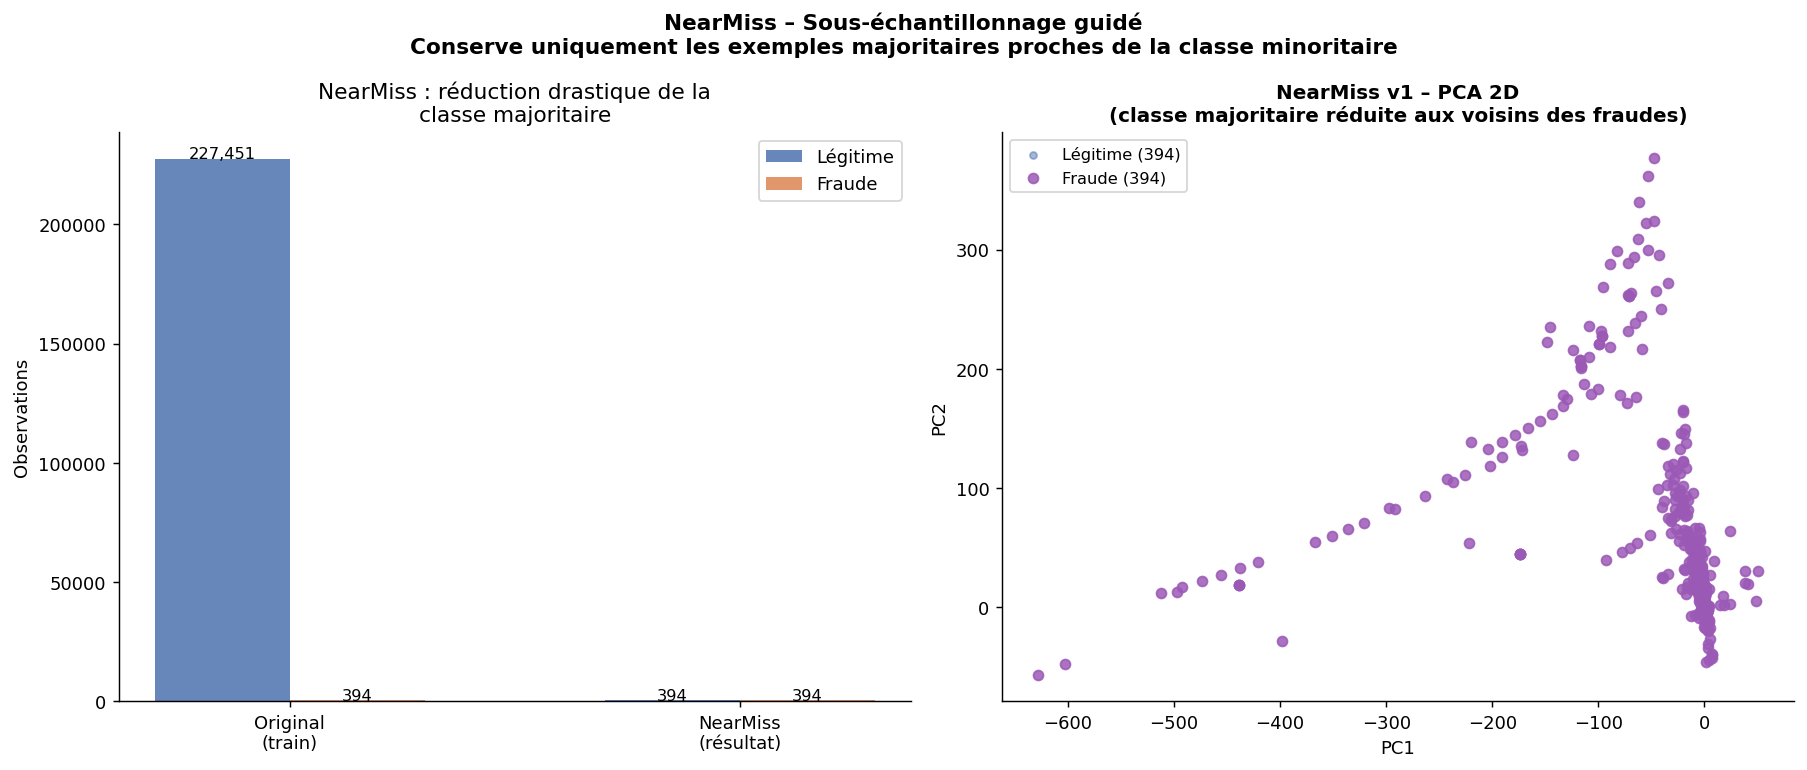

In [ ]:
idx_nm = np.random.choice(len(X_tr_nm), min(len(X_tr_nm), 2000), replace=False)
X_nm_2d  = pca2.transform(X_tr_nm.values[idx_nm]
                           if hasattr(X_tr_nm, 'values') else X_tr_nm[idx_nm])
y_nm_2d  = (y_tr_nm.values[idx_nm]
             if hasattr(y_tr_nm, 'values') else y_tr_nm[idx_nm])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Évolution du dataset
ax = axes[0]
stages = ["Original\n(train)", "NearMiss\n(résultat)"]
counts_stages = [
    [n_orig_train - y_train.sum(), y_train.sum()],
    [(y_tr_nm == 0).sum(), (y_tr_nm == 1).sum()],
]
x_pos_nm = np.arange(2)
w_nm = 0.3
for i, (lbl, col) in enumerate([("Légitime", C["maj"]), ("Fraude", C["min"])]):
    vals = [counts_stages[j][i] for j in range(2)]
    ax.bar(x_pos_nm + (i-0.5)*w_nm, vals, width=w_nm,
           color=col, alpha=0.85, label=lbl)
    for x, v in zip(x_pos_nm + (i-0.5)*w_nm, vals):
        ax.text(x, v + 200, f"{v:,}", ha="center", fontsize=9)
ax.set_xticks(x_pos_nm); ax.set_xticklabels(stages)
ax.set_ylabel("Observations")
ax.set_title("NearMiss : réduction drastique de la\nclasse majoritaire")
ax.legend()

# PCA NearMiss
ax = axes[1]
ax.scatter(X_nm_2d[y_nm_2d==0, 0], X_nm_2d[y_nm_2d==0, 1],
           c=C["maj"], s=15, alpha=0.5, label=f"Légitime ({(y_tr_nm==0).sum():,})")
ax.scatter(X_nm_2d[y_nm_2d==1, 0], X_nm_2d[y_nm_2d==1, 1],
           c=C["purple"], s=30, alpha=0.85, label=f"Fraude ({(y_tr_nm==1).sum():,})")
ax.set_title("NearMiss v1 – PCA 2D\n(classe majoritaire réduite aux voisins des fraudes)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9)

plt.suptitle("NearMiss – Sous-échantillonnage guidé\n"
             "Conserve uniquement les exemples majoritaires proches de la classe minoritaire",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig09_nearmiss_detail.png")
plt.show()

### FIG 10 – Class Weight : visualisation de l'effet

  ✓ fig10_classweight_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig10_classweight_detail.png


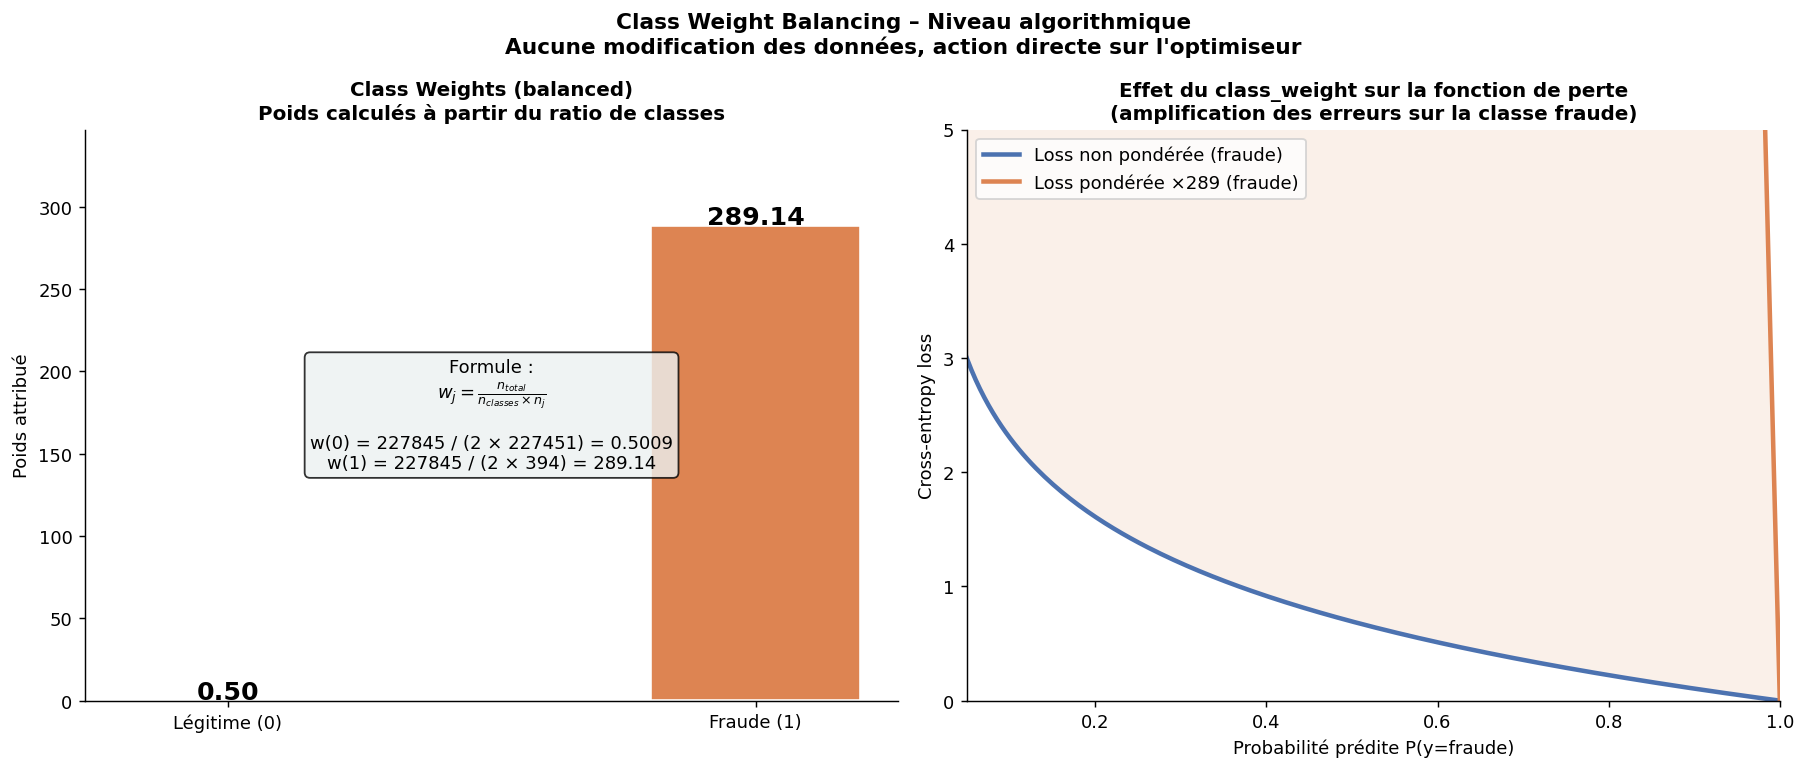

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Visualisation des poids
ax = axes[0]
classes_labels = ["Légitime (0)", "Fraude (1)"]
weights_vals   = [cw_dict[0], cw_dict[1]]
bars_w = ax.bar(classes_labels, weights_vals,
                color=[C["maj"], C["min"]], edgecolor="white", linewidth=2, width=0.4)
for bar, val in zip(bars_w, weights_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.2f}", ha="center", fontweight="bold", fontsize=14)
ax.set_ylabel("Poids attribué")
ax.set_title("Class Weights (balanced)\nPoids calculés à partir du ratio de classes",
             fontsize=11, fontweight="bold")
ax.set_ylim(0, max(weights_vals) * 1.2)

# Annotation de la formule
formula_text = (
    "Formule :\n"
    r"$w_j = \frac{n_{total}}{n_{classes} \times n_j}$"
    f"\n\nw(0) = {len(y_train)} / (2 × {(y_train==0).sum()}) = {cw_dict[0]:.4f}"
    f"\nw(1) = {len(y_train)} / (2 × {(y_train==1).sum()}) = {cw_dict[1]:.2f}"
)
ax.text(0.5, 0.5, formula_text, transform=ax.transAxes,
        fontsize=10, ha="center", va="center",
        bbox=dict(boxstyle="round", facecolor="#ecf0f1", alpha=0.8))

# Comparaison : impact sur la loss (schématique)
ax2 = axes[1]
x_range = np.linspace(0, 1, 200)
loss_unweighted = -np.log(x_range + 1e-9)
loss_weighted   = cw_dict[1] * (-np.log(x_range + 1e-9))

ax2.plot(x_range, loss_unweighted, color=C["maj"], lw=2.5, label="Loss non pondérée (fraude)")
ax2.plot(x_range, loss_weighted,   color=C["min"], lw=2.5, label=f"Loss pondérée ×{cw_dict[1]:.0f} (fraude)")
ax2.fill_between(x_range, loss_unweighted, loss_weighted,
                 alpha=0.12, color=C["min"])
ax2.set_xlim(0.05, 1); ax2.set_ylim(0, 5)
ax2.set_xlabel("Probabilité prédite P(y=fraude)")
ax2.set_ylabel("Cross-entropy loss")
ax2.set_title("Effet du class_weight sur la fonction de perte\n"
              "(amplification des erreurs sur la classe fraude)",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=10)

plt.suptitle("Class Weight Balancing – Niveau algorithmique\n"
             "Aucune modification des données, action directe sur l'optimiseur",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig10_classweight_detail.png")
plt.show()

### FIG 11 – PCA 2D des 4 espaces rééchantillonnés (vue comparative)

  ✓ fig11_methods_pca_2d.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig11_methods_pca_2d.png


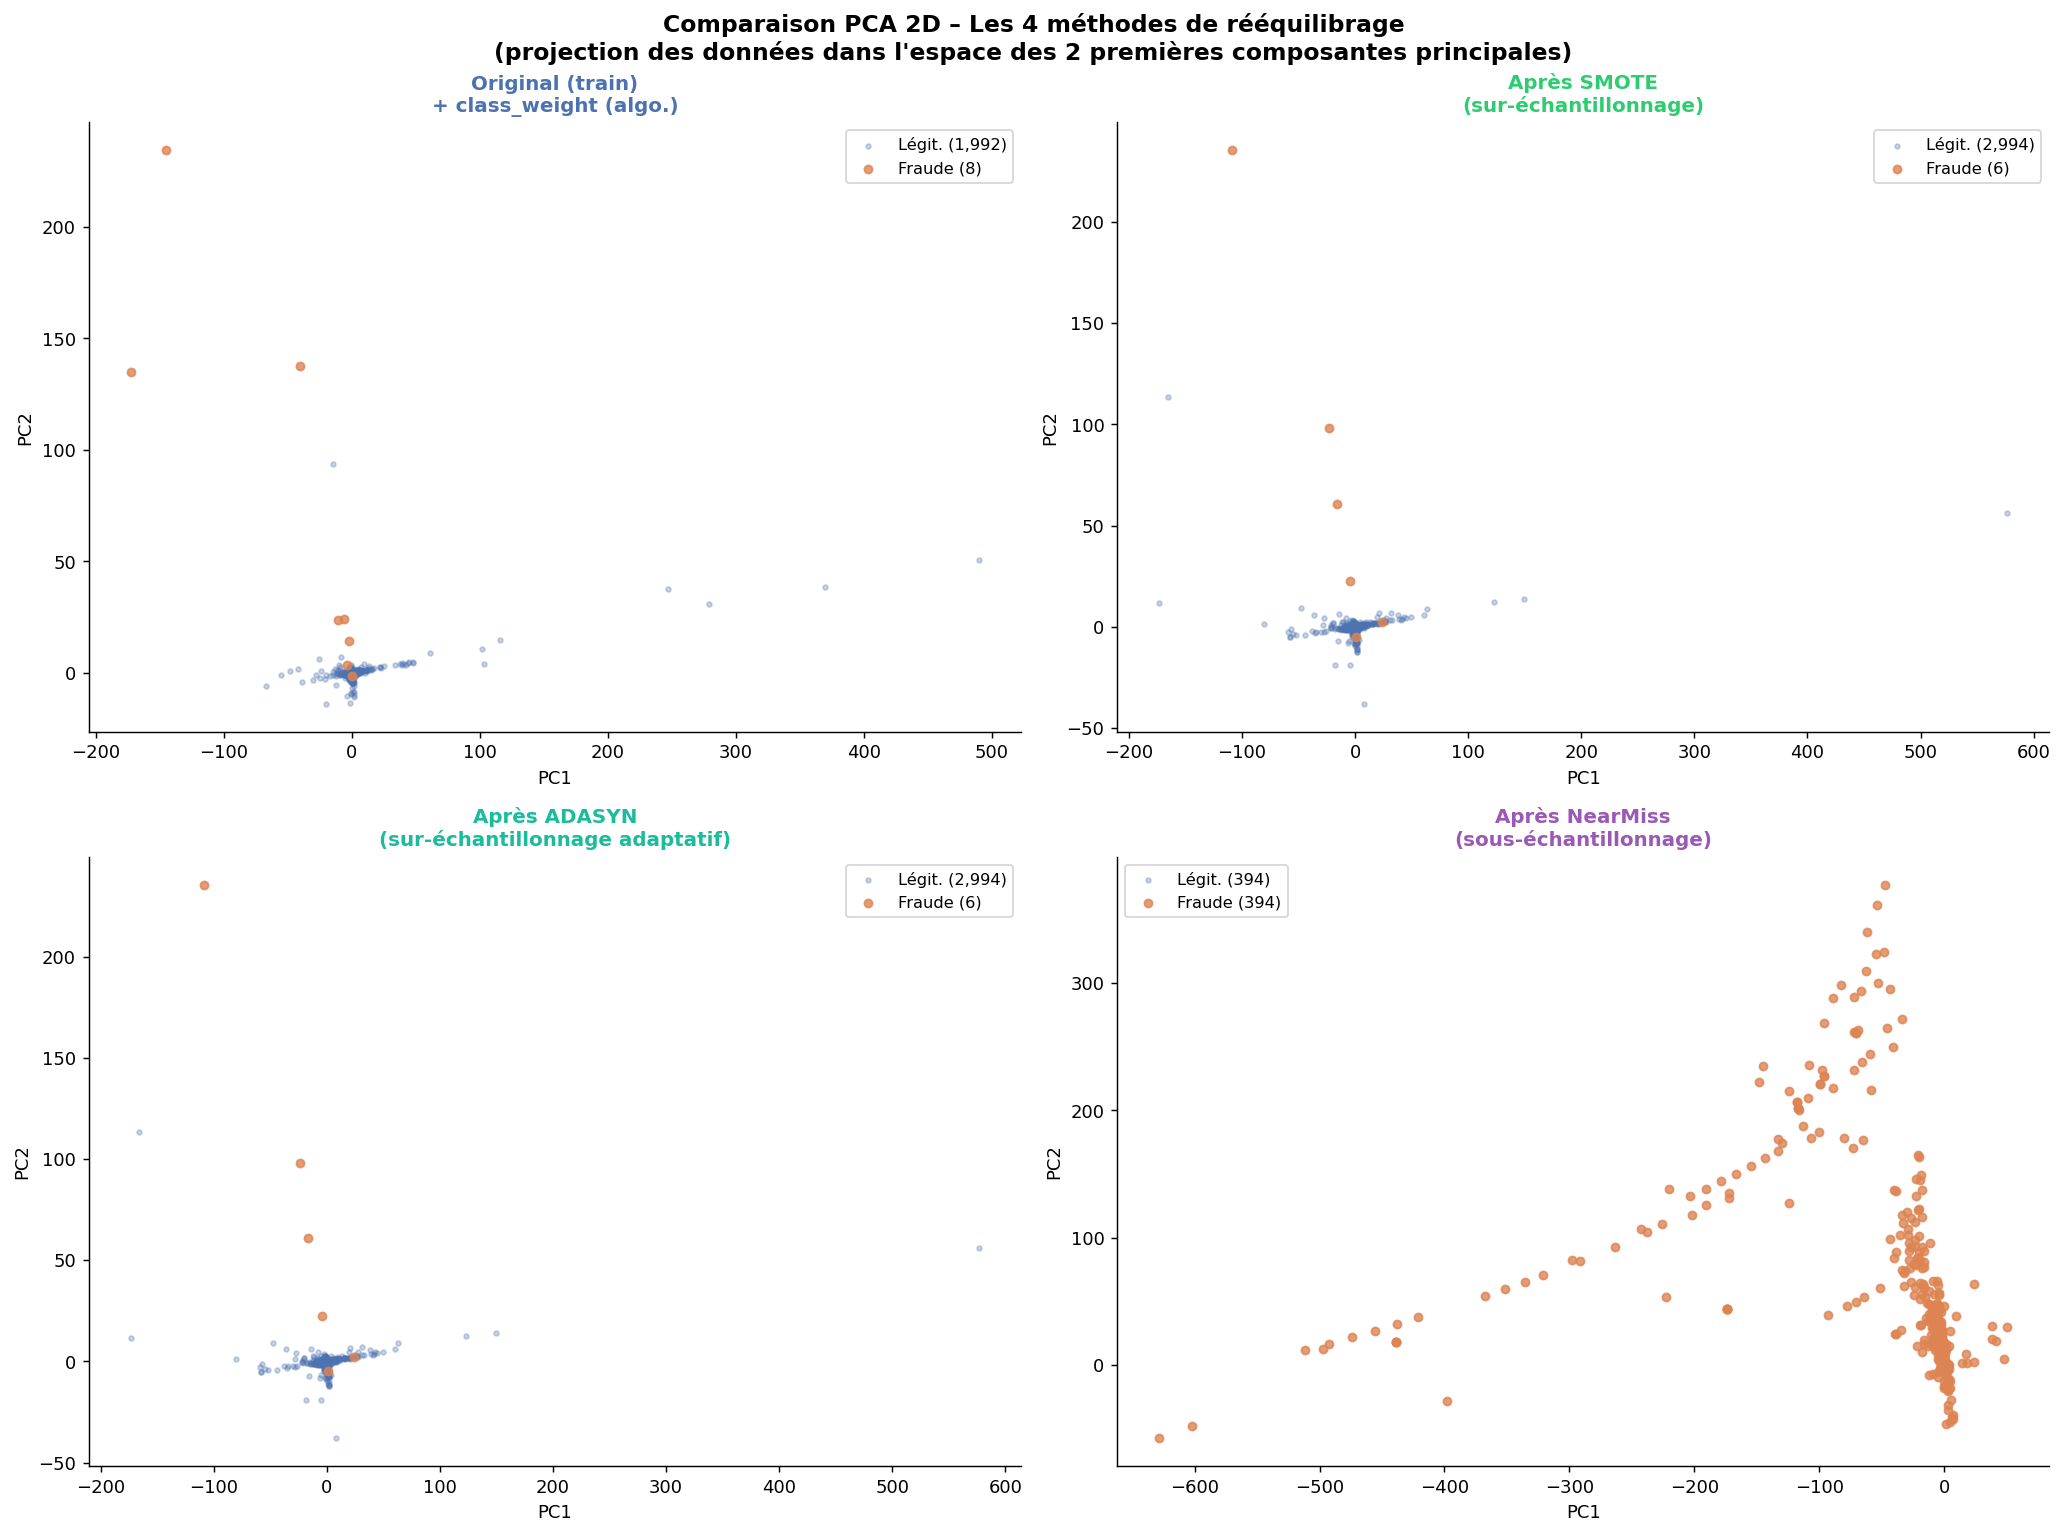

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

datasets = [
    ("Original (train)\n+ class_weight (algo.)", X_orig_2k, y_orig_2k,
     C["maj"], "•", "class_weight"),
    ("Après SMOTE\n(sur-échantillonnage)",
     X_tr_smote.values[:3000] if hasattr(X_tr_smote, 'values') else X_tr_smote[:3000],
     y_tr_smote.values[:3000] if hasattr(y_tr_smote, 'values') else y_tr_smote[:3000],
     C["green"], "•", "SMOTE"),
    ("Après ADASYN\n(sur-échantillonnage adaptatif)",
     X_tr_adasyn.values[:3000] if hasattr(X_tr_adasyn, 'values') else X_tr_adasyn[:3000],
     y_tr_adasyn.values[:3000] if hasattr(y_tr_adasyn, 'values') else y_tr_adasyn[:3000],
     C["teal"], "•", "ADASYN"),
    ("Après NearMiss\n(sous-échantillonnage)",
     X_tr_nm.values if hasattr(X_tr_nm, 'values') else X_tr_nm,
     y_tr_nm.values if hasattr(y_tr_nm, 'values') else y_tr_nm,
     C["purple"], "•", "NearMiss"),
]

for ax, (title, X_d, y_d, col, mk, method) in zip(axes, datasets):
    X_d_arr = X_d if isinstance(X_d, np.ndarray) else np.array(X_d)
    y_d_arr = y_d if isinstance(y_d, np.ndarray) else np.array(y_d)
    n_plot  = min(3000, len(X_d_arr))
    idx_p   = np.random.choice(len(X_d_arr), n_plot, replace=False)
    X_2d    = pca2.transform(X_d_arr[idx_p])
    y_2d    = y_d_arr[idx_p]

    ax.scatter(X_2d[y_2d==0, 0], X_2d[y_2d==0, 1],
               c=C["maj"], s=7, alpha=0.3, label=f"Légit. ({(y_d_arr==0).sum():,})")
    ax.scatter(X_2d[y_2d==1, 0], X_2d[y_2d==1, 1],
               c=C["min"], s=20, alpha=0.8, label=f"Fraude ({(y_d_arr==1).sum():,})")
    ax.set_title(title, fontsize=11, fontweight="bold", color=col)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=9)

plt.suptitle("Comparaison PCA 2D – Les 4 méthodes de rééquilibrage\n"
             "(projection des données dans l'espace des 2 premières composantes principales)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig11_methods_pca_2d.png")
plt.show()

### FIG 12 – Distributions V1-V28

  ✓ fig12_pca_features_distribution.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig12_pca_features_distribution.png


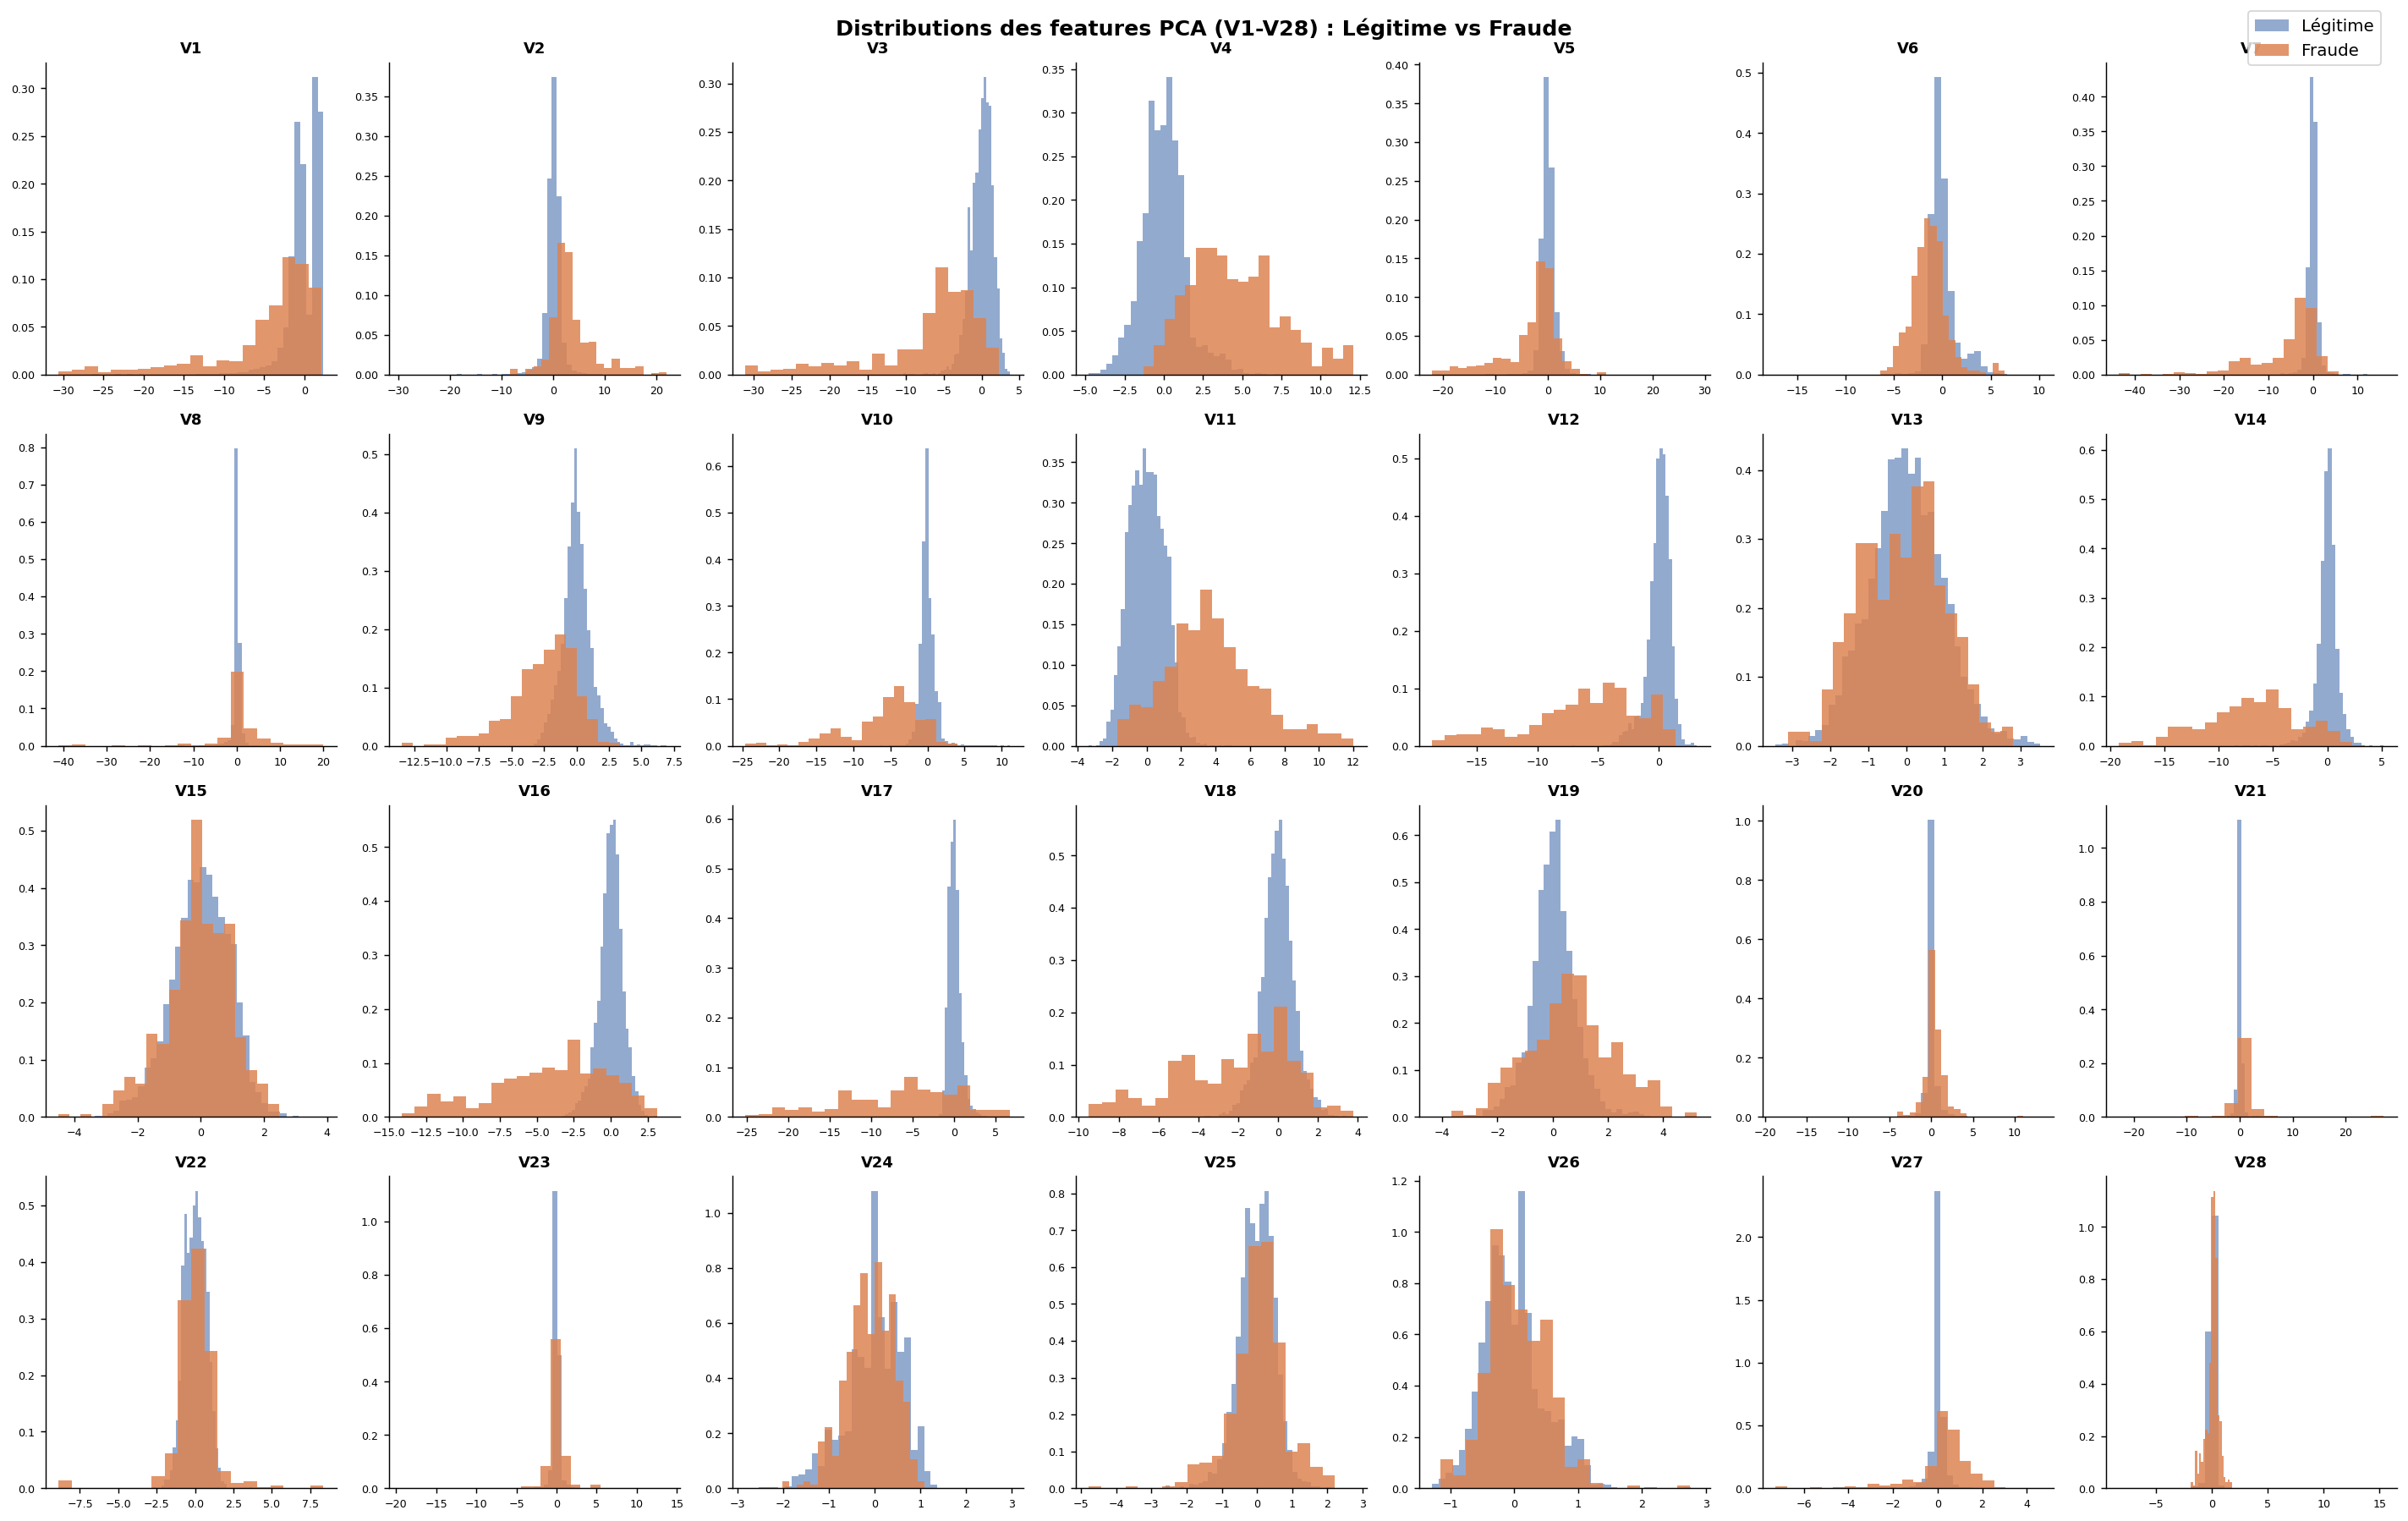

In [ ]:
v_features   = [f"V{i}" for i in range(1, 29)]
sample_legit = df[df["Class"] == 0][v_features].sample(5000, random_state=RANDOM_STATE)
sample_fraud = df[df["Class"] == 1][v_features]

fig, axes = plt.subplots(4, 7, figsize=(22, 14))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    ax = axes[i]
    ax.hist(sample_legit[feat], bins=40, color=C["maj"], alpha=0.6, density=True)
    ax.hist(sample_fraud[feat], bins=20, color=C["min"], alpha=0.85, density=True)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)

handles = [
    Patch(facecolor=C["maj"], alpha=0.6, label="Légitime"),
    Patch(facecolor=C["min"], alpha=0.85, label="Fraude"),
]
fig.legend(handles=handles, loc="upper right", fontsize=11, bbox_to_anchor=(0.99, 0.99))
plt.suptitle("Distributions des features PCA (V1-V28) : Légitime vs Fraude",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig12_pca_features_distribution.png")
plt.show()

### SAUVEGARDE pickle

In [ ]:
prepared = {
    "X_train":        X_train,
    "X_test":         X_test,
    "y_train":        y_train,
    "y_test":         y_test,
    "X_train_smote":  X_tr_smote,
    "y_train_smote":  y_tr_smote,
    "X_train_adasyn": X_tr_adasyn,
    "y_train_adasyn": y_tr_adasyn,
    "X_train_nm":     X_tr_nm,
    "y_train_nm":     y_tr_nm,
    "class_weight":   cw_dict,
    "scaler":         scaler,
    "scale_cols":     scale_cols,
    "mi_scores":      mi_series,
    "selected_features": selected_features,
    "vif_data":       vif_data,
}
with open(OUT_PICKLE, "wb") as f:
    pickle.dump(prepared, f)

print(f"\n✓ Données sauvegardées → {OUT_PICKLE}")
print("\n" + "─" * 65)
print(f"ÉTAPE 1 TERMINÉE – 12 figures générées dans :")
print(f"  {FIG_DIR}")
print("─" * 65)


✓ Données sauvegardées → C:\Users\DELL\Desktop\IA_P1\etape1_eda\prepared_data.pkl

─────────────────────────────────────────────────────────────────
ÉTAPE 1 TERMINÉE – 12 figures générées dans :
  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures
─────────────────────────────────────────────────────────────────



---
# Etape 2 : Developpement des Modeles

*Logistic Regression Elastic Net, Random Forest + Proximite, XGBoost + Optuna 50 trials*


In [ ]:
import sys


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, matthews_corrcoef,
    f1_score, precision_recall_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, learning_curve, train_test_split as tts
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from matplotlib.patches import Patch
import pickle

# ─── Chemins ─────────────────────────────────────────────────────────────────
ROOT      = ROOT
FIG_DIR   = ROOT / "etape2_models" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_PKL  = ROOT / "etape1_eda" / "prepared_data.pkl"
OUT_PKL   = ROOT / "etape2_models" / "trained_models.pkl"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})
C = {"maj":"#4C72B0","min":"#DD8452","green":"#2ecc71","purple":"#9b59b6",
     "red":"#e74c3c","orange":"#f39c12","teal":"#1abc9c","dark":"#2c3e50"}

def save_fig(fig, name):
    p = FIG_DIR / name
    fig.savefig(p, bbox_inches="tight", dpi=130)
    print(f"  ✓ {name}")

# ─── Chargement ──────────────────────────────────────────────────────────────
with open(DATA_PKL, "rb") as f: data = pickle.load(f)
X_train = data["X_train"]; X_test  = data["X_test"]
y_train = data["y_train"]; y_test  = data["y_test"]
cw_dict = data["class_weight"]

train_n = min(120000, len(X_train))
if train_n < len(X_train):
    X_train_model, _, y_train_model, _ = tts(
        X_train, y_train, train_size=train_n,
        stratify=y_train, random_state=RANDOM_STATE
    )
else:
    X_train_model, y_train_model = X_train, y_train

print("=" * 65)
print("ÉTAPE 2 – Développement des modèles")
print("=" * 65)
print(f"Train utilisé pour l'entraînement des modèles : {len(X_train_model):,} observations")

ÉTAPE 2 – Développement des modèles
Train utilisé pour l'entraînement des modèles : 120,000 observations


### MODÈLE 1 : RÉGRESSION LOGISTIQUE ELASTIC NET


── Modèle 1 : Logistic Regression Elastic Net ──
✓ LogReg entraîné (subset stratifié: 80,000 obs).
              precision    recall  f1-score   support

      Légit.       1.00      0.93      0.96     56864
      Fraude       0.02      0.93      0.04        98

    accuracy                           0.93     56962
   macro avg       0.51      0.93      0.50     56962
weighted avg       1.00      0.93      0.96     56962

  ✓ fig01_logreg_coefficients.png


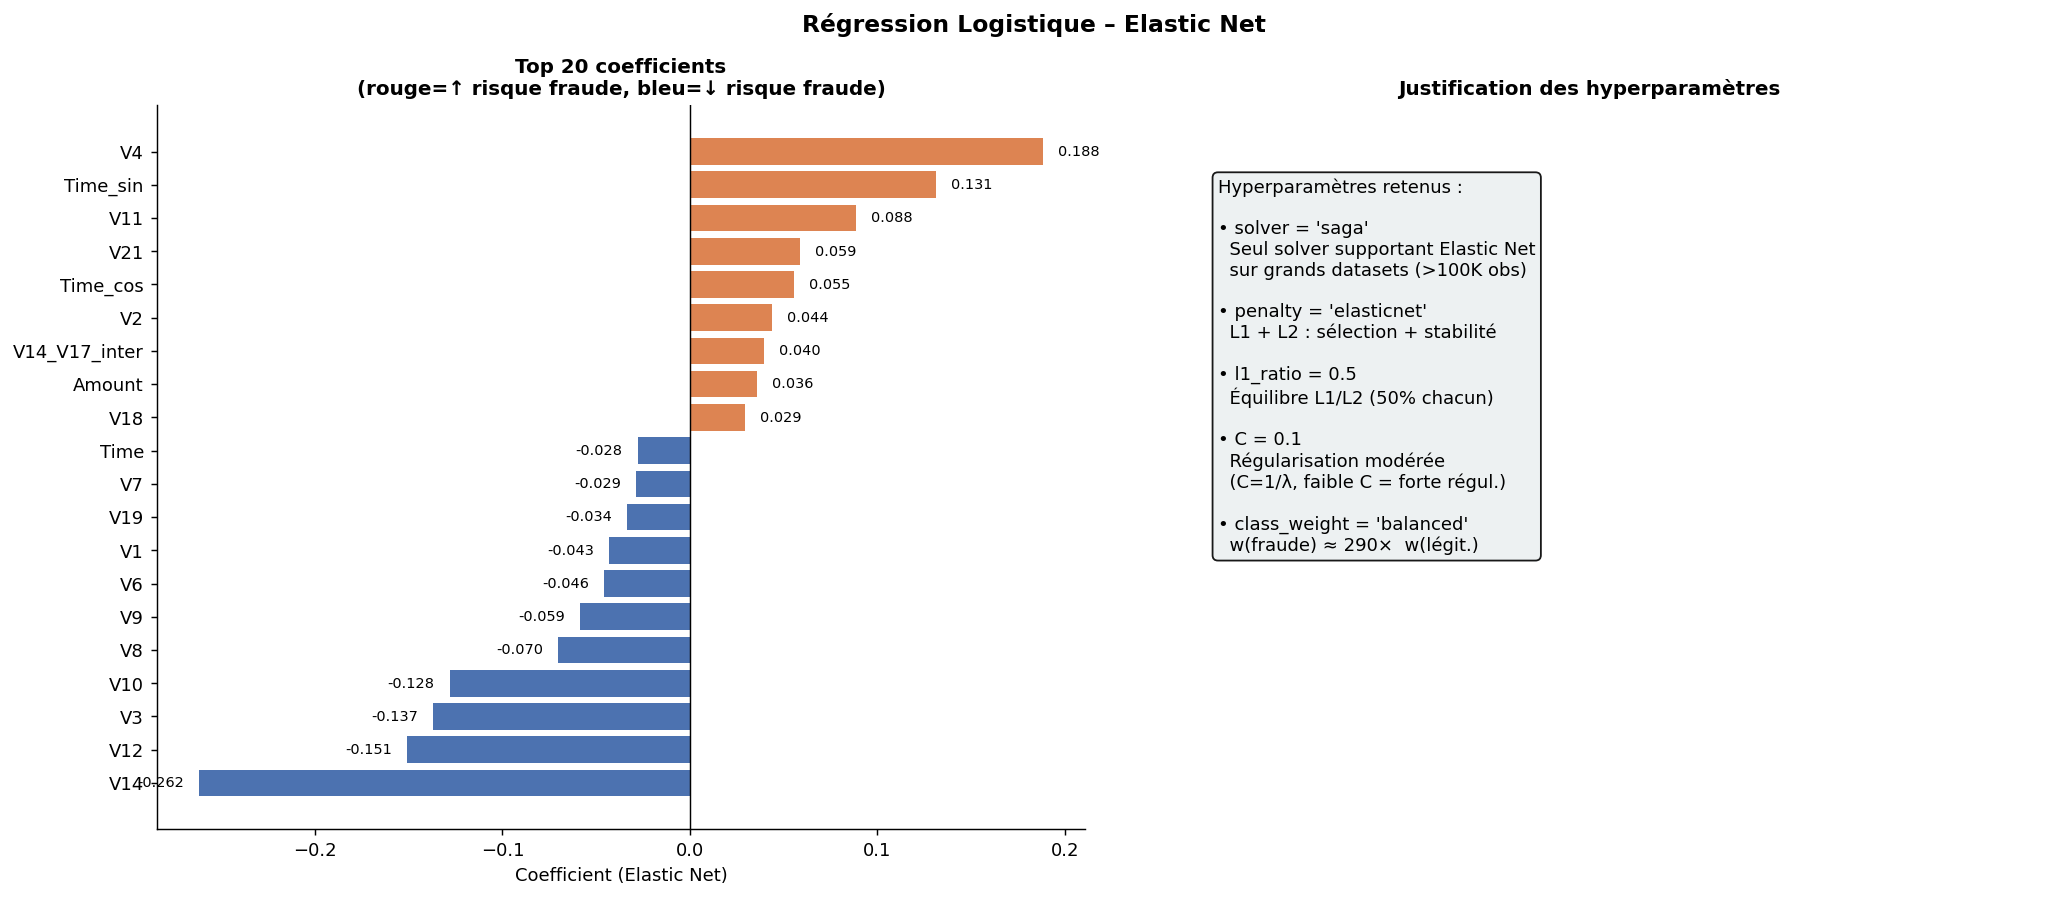

  ✓ fig02_logreg_pr_curve.png


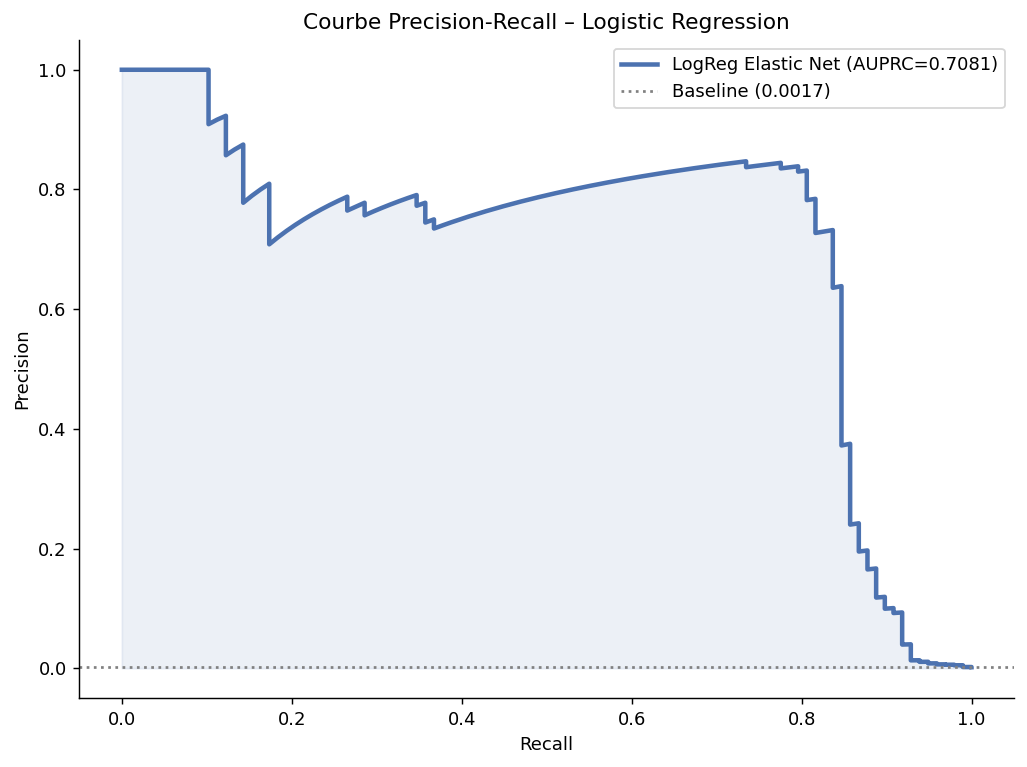

In [ ]:
print("\n── Modèle 1 : Logistic Regression Elastic Net ──")
logreg = LogisticRegression(
    penalty="elasticnet", solver="saga", l1_ratio=0.5,
    C=0.1, class_weight="balanced", max_iter=300, tol=1e-3,
    random_state=RANDOM_STATE, n_jobs=1,
)
lr_sample_n = min(80000, len(X_train_model))
if lr_sample_n < len(X_train_model):
    X_lr, _, y_lr, _ = tts(
        X_train_model, y_train_model, train_size=lr_sample_n,
        stratify=y_train_model, random_state=RANDOM_STATE
    )
else:
    X_lr, y_lr = X_train_model, y_train_model

logreg.fit(X_lr, y_lr)
y_pred_lr  = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]
print(f"✓ LogReg entraîné (subset stratifié: {len(X_lr):,} obs).")
print(classification_report(y_test, y_pred_lr, target_names=["Légit.", "Fraude"]))

# FIG 01 – Coefficients
coefs = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
top20 = coefs.head(20).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_c = [C["min"] if v > 0 else C["maj"] for v in top20]
axes[0].barh(top20.index, top20.values, color=colors_c)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Coefficient (Elastic Net)")
axes[0].set_title("Top 20 coefficients\n(rouge=↑ risque fraude, bleu=↓ risque fraude)",
                   fontsize=11, fontweight="bold")
for i, val in enumerate(top20.values):
    axes[0].text(val+(0.008 if val>=0 else -0.008), i,
                 f"{val:.3f}", va="center",
                 ha="left" if val>=0 else "right", fontsize=8)

# L1 vs L2 proportion (l1_ratio=0.5)
axes[1].axis("off")
info_text = (
    "Hyperparamètres retenus :\n\n"
    "• solver = 'saga'\n"
    "  Seul solver supportant Elastic Net\n"
    "  sur grands datasets (>100K obs)\n\n"
    "• penalty = 'elasticnet'\n"
    "  L1 + L2 : sélection + stabilité\n\n"
    "• l1_ratio = 0.5\n"
    "  Équilibre L1/L2 (50% chacun)\n\n"
    "• C = 0.1\n"
    "  Régularisation modérée\n"
    "  (C=1/λ, faible C = forte régul.)\n\n"
    "• class_weight = 'balanced'\n"
    "  w(fraude) ≈ 290×  w(légit.)"
)
axes[1].text(0.1, 0.9, info_text, transform=axes[1].transAxes,
             fontsize=10, va="top",
             bbox=dict(boxstyle="round", facecolor="#ecf0f1", alpha=0.9))
axes[1].set_title("Justification des hyperparamètres", fontsize=11, fontweight="bold")

plt.suptitle("Régression Logistique – Elastic Net",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig01_logreg_coefficients.png")
plt.show()

# FIG 02 – PR curve LogReg
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr)
auprc_lr = auc(rec_lr, prec_lr)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_lr, prec_lr, color=C["maj"], lw=2.5,
        label=f"LogReg Elastic Net (AUPRC={auprc_lr:.4f})")
ax.axhline(y_test.mean(), color="gray", ls=":", label=f"Baseline ({y_test.mean():.4f})")
ax.fill_between(rec_lr, prec_lr, alpha=0.1, color=C["maj"])
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Courbe Precision-Recall – Logistic Regression")
ax.legend()
plt.tight_layout()
save_fig(fig, "fig02_logreg_pr_curve.png")
plt.show()

### MODÈLE 2 : RANDOM FOREST + PROXIMITÉ


── Modèle 2 : Random Forest ──
✓ RF entraîné.
              precision    recall  f1-score   support

      Légit.       1.00      1.00      1.00     56864
      Fraude       0.83      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

  ✓ fig03_rf_feature_importance.png


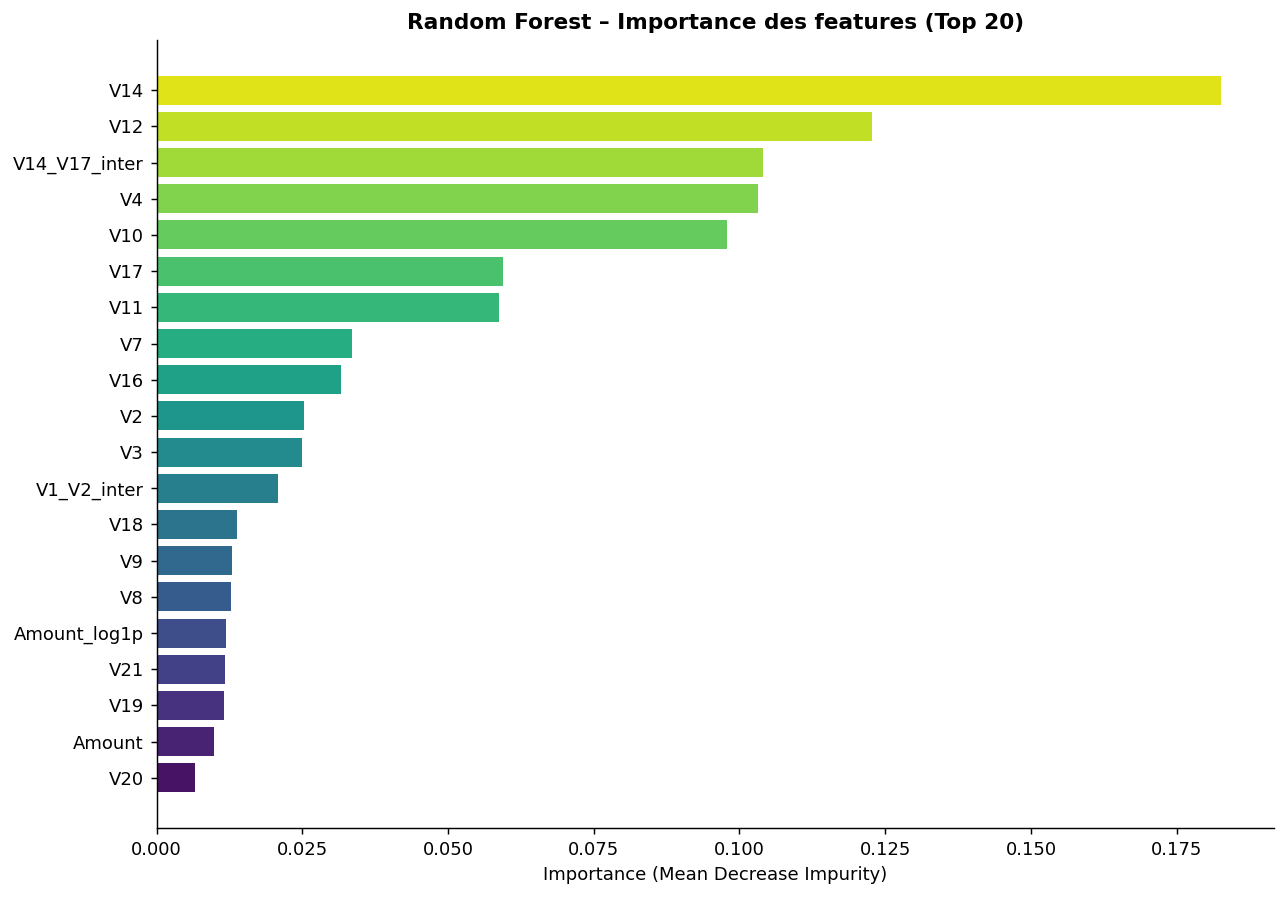


Calcul de la matrice de proximité…
Outliers (top 5%) : 100
  ✓ fig04_rf_proximity_matrix.png


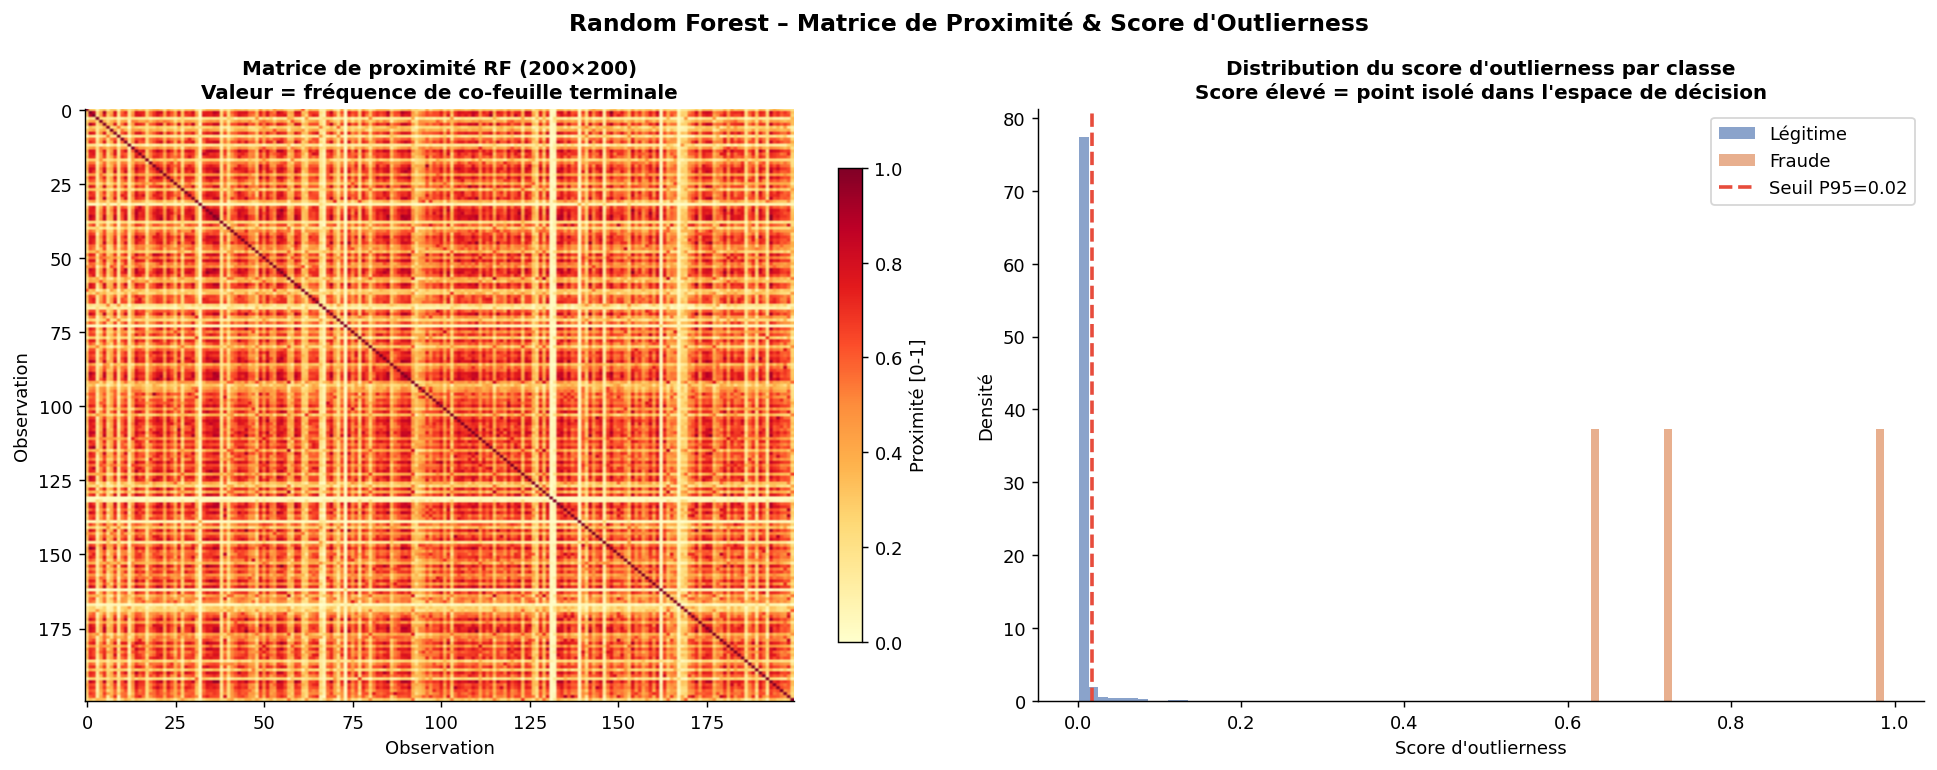

  ✓ fig05_rf_outliers_pca.png


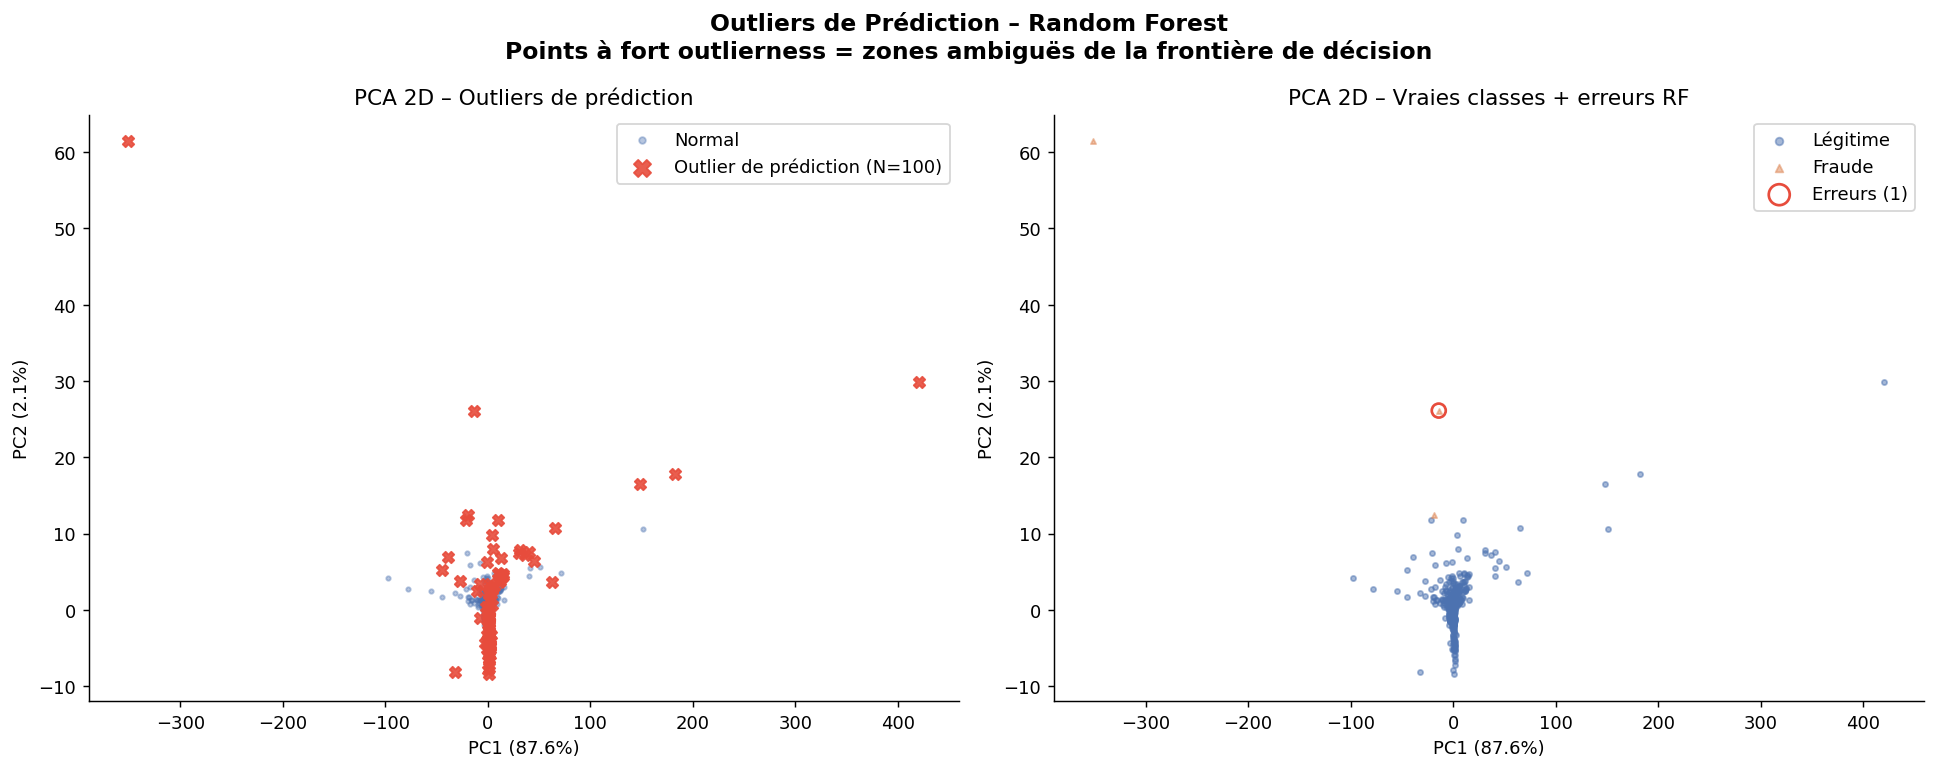

  ✓ fig06_outlier_profiles.png


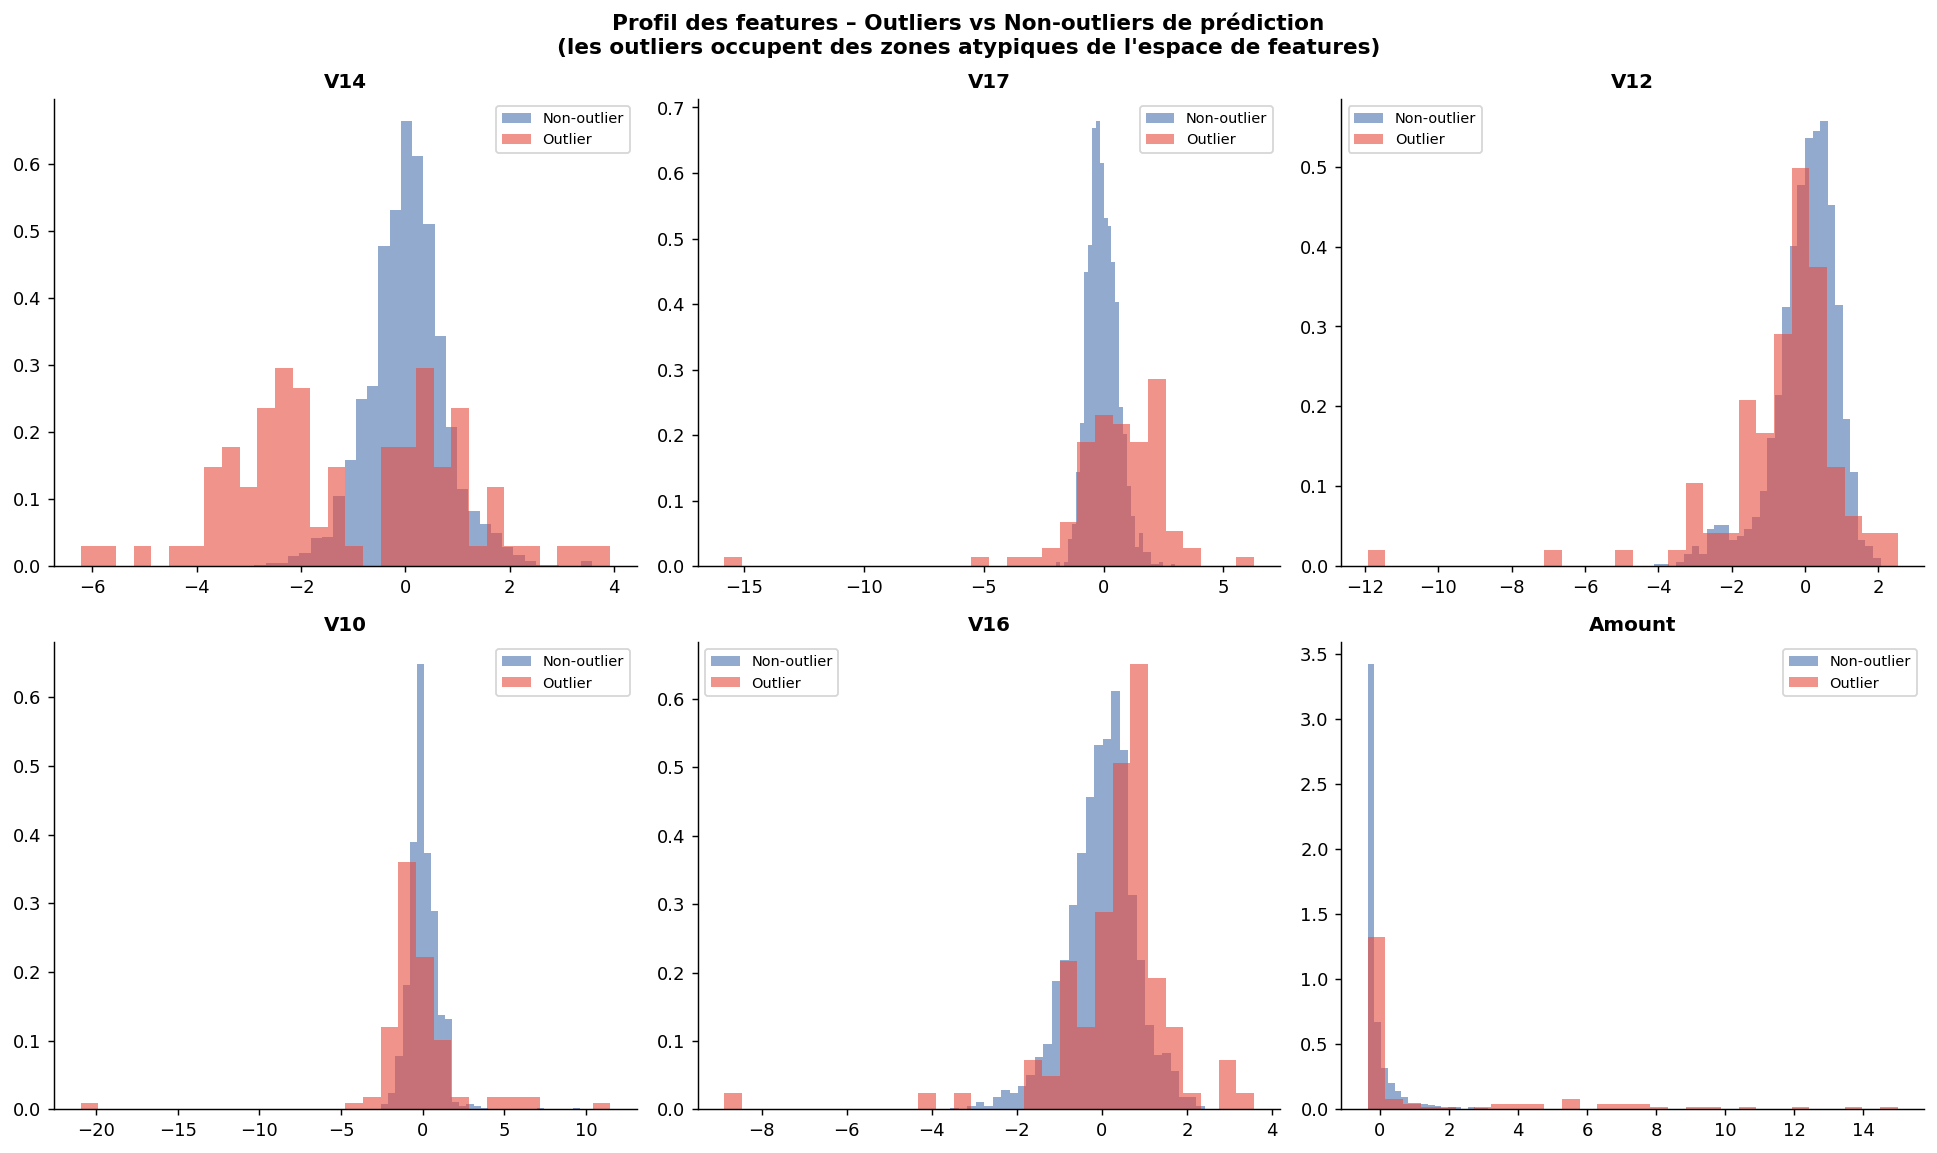


── Analyse des outliers de prédiction RF ──

Outliers (top 5% outlierness) : 100 observations
  • Fraudes  parmi outliers : 3 (3.0%)
  • Légitimes parmi outliers : 97 (97.0%)
  • Taux d'erreur RF – outliers : 1.0%
  • Taux d'erreur RF – non-outliers : 0.0%

Pourquoi le RF hésite sur ces points ?
  1. ZONE DE CHEVAUCHEMENT : les outliers se situent à la frontière des deux classes
     dans l'espace PCA. Le RF agrège les votes des 120 arbres, mais dans ces zones
     le vote est quasi-partagé (ex: 55% légitime / 45% fraude).
  2. FEATURES ATYPIQUES : les profils montrent que les outliers ont des valeurs
     de V14, V12 et V17 hors de leur distribution habituelle (queue de distribution).
     Ces valeurs rares apparaissent peu dans l'entraînement → les arbres n'ont
     pas assez d'exemples pour construire des frontières fiables.
  3. DÉSÉQUILIBRE LOCAL : même avec class_weight='balanced_subsample', les nœuds
     proches de la frontière peuvent être peu peuplés en fraudes, réduisant la

In [ ]:
print("\n── Modèle 2 : Random Forest ──")
rf = RandomForestClassifier(
    n_estimators=120, max_depth=10, min_samples_leaf=6,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train_model, y_train_model)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("✓ RF entraîné.")
print(classification_report(y_test, y_pred_rf, target_names=["Légit.", "Fraude"]))

# FIG 03 – Feature importance RF
imp = pd.Series(rf.feature_importances_, index=X_train.columns)
imp = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
palette_imp = sns.color_palette("viridis", 20)
ax.barh(imp.index[::-1], imp.values[::-1], color=palette_imp)
ax.set_xlabel("Importance (Mean Decrease Impurity)")
ax.set_title("Random Forest – Importance des features (Top 20)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig03_rf_feature_importance.png")
plt.show()

# ── Matrice de proximité ──────────────────────────────────────────────────────
def proximity_matrix(model, X_arr, n=2000, batch=500):
    idx  = np.random.choice(len(X_arr), min(n, len(X_arr)), replace=False)
    Xs   = X_arr[idx]
    lv   = model.apply(Xs)          # (n, n_trees)
    n_t  = lv.shape[1]
    P    = np.zeros((len(idx), len(idx)), dtype=np.float32)
    for s in range(0, len(idx), batch):
        e = min(s+batch, len(idx))
        P[s:e] += (lv[s:e, np.newaxis, :] == lv[np.newaxis, :, :]).sum(2).astype(np.float32)
    P /= n_t
    return P, idx

def outlierness(P):
    return 1.0 / (np.sum(P**2, axis=1) + 1e-8)

print("\nCalcul de la matrice de proximité…")
X_test_arr   = X_test.values
P, s_idx     = proximity_matrix(rf, X_test_arr, n=2000)
out_sc       = outlierness(P)
y_sub        = y_test.iloc[s_idx].values
pred_sub     = rf.predict(X_test_arr[s_idx])
thresh       = np.percentile(out_sc, 95)
is_out       = out_sc > thresh
print(f"Outliers (top 5%) : {is_out.sum()}")

# FIG 04 – Heatmap proximité + distribution outlierness
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap 200×200
n200 = 200
sub200 = np.random.choice(len(P), n200, replace=False)
P200  = P[np.ix_(sub200, sub200)]
im = axes[0].imshow(P200, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0], shrink=0.8, label="Proximité [0-1]")
axes[0].set_title("Matrice de proximité RF (200×200)\n"
                  "Valeur = fréquence de co-feuille terminale",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Observation"); axes[0].set_ylabel("Observation")

# Distribution outlierness
for cls, col, lbl in [(0, C["maj"],"Légitime"),(1, C["min"],"Fraude")]:
    axes[1].hist(out_sc[y_sub==cls], bins=40, color=col, alpha=0.65, density=True, label=lbl)
axes[1].axvline(thresh, color=C["red"], ls="--", lw=2, label=f"Seuil P95={thresh:.2f}")
axes[1].set_xlabel("Score d'outlierness")
axes[1].set_ylabel("Densité")
axes[1].set_title("Distribution du score d'outlierness par classe\n"
                  "Score élevé = point isolé dans l'espace de décision",
                  fontsize=11, fontweight="bold")
axes[1].legend()

plt.suptitle("Random Forest – Matrice de Proximité & Score d'Outlierness",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig04_rf_proximity_matrix.png")
plt.show()

# FIG 05 – PCA 2D outliers
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X_test_arr[s_idx])
correct = (y_sub == pred_sub)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(X_pca[~is_out,0], X_pca[~is_out,1], c=C["maj"], s=6, alpha=0.4, label="Normal")
ax.scatter(X_pca[is_out,0],  X_pca[is_out,1],  c=C["red"], s=40, alpha=0.9,
           marker="X", label=f"Outlier de prédiction (N={is_out.sum()})")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA 2D – Outliers de prédiction")
ax.legend(markerscale=1.5)

ax2 = axes[1]
for cls, col, mk, lbl in [(0,C["maj"],"o","Légitime"),(1,C["min"],"^","Fraude")]:
    m = y_sub == cls
    ax2.scatter(X_pca[m,0], X_pca[m,1], c=col, s=8, alpha=0.5, marker=mk, label=lbl)
ax2.scatter(X_pca[~correct,0], X_pca[~correct,1],
            edgecolors=C["red"], facecolors="none",
            s=60, lw=1.5, label=f"Erreurs ({(~correct).sum()})", zorder=5)
ax2.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax2.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax2.set_title("PCA 2D – Vraies classes + erreurs RF")
ax2.legend(markerscale=1.5)

plt.suptitle("Outliers de Prédiction – Random Forest\n"
             "Points à fort outlierness = zones ambiguës de la frontière de décision",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig05_rf_outliers_pca.png")
plt.show()

# FIG 06 – Profil features des outliers
X_sub_df = X_test.iloc[s_idx].copy()
X_sub_df["is_outlier"] = is_out
X_sub_df["true_class"] = y_sub

top_feats = ["V14","V17","V12","V10","V16","Amount"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, feat in enumerate(top_feats):
    ax = axes[i]
    for grp, col, lbl in [(False, C["maj"],"Non-outlier"), (True, C["red"],"Outlier")]:
        v = X_sub_df[X_sub_df["is_outlier"]==grp][feat]
        ax.hist(v, bins=30, color=col, alpha=0.6, density=True, label=lbl)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Profil des features – Outliers vs Non-outliers de prédiction\n"
             "(les outliers occupent des zones atypiques de l'espace de features)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig06_outlier_profiles.png")
plt.show()

# ── Analyse textuelle des outliers de prédiction ─────────────────────────────
print("\n── Analyse des outliers de prédiction RF ──")
out_mask     = is_out
in_mask      = ~is_out
n_out_fraud  = ((y_sub == 1) & out_mask).sum()
n_out_legit  = ((y_sub == 0) & out_mask).sum()
n_err_out    = ((pred_sub != y_sub) & out_mask).sum()
n_err_in     = ((pred_sub != y_sub) & in_mask).sum()
err_rate_out = n_err_out / max(out_mask.sum(), 1)
err_rate_in  = n_err_in  / max(in_mask.sum(), 1)

print(f"""
Outliers (top 5% outlierness) : {out_mask.sum()} observations
  • Fraudes  parmi outliers : {n_out_fraud} ({n_out_fraud/max(out_mask.sum(),1):.1%})
  • Légitimes parmi outliers : {n_out_legit} ({n_out_legit/max(out_mask.sum(),1):.1%})
  • Taux d'erreur RF – outliers : {err_rate_out:.1%}
  • Taux d'erreur RF – non-outliers : {err_rate_in:.1%}

Pourquoi le RF hésite sur ces points ?
  1. ZONE DE CHEVAUCHEMENT : les outliers se situent à la frontière des deux classes
     dans l'espace PCA. Le RF agrège les votes des 120 arbres, mais dans ces zones
     le vote est quasi-partagé (ex: 55% légitime / 45% fraude).
  2. FEATURES ATYPIQUES : les profils montrent que les outliers ont des valeurs
     de V14, V12 et V17 hors de leur distribution habituelle (queue de distribution).
     Ces valeurs rares apparaissent peu dans l'entraînement → les arbres n'ont
     pas assez d'exemples pour construire des frontières fiables.
  3. DÉSÉQUILIBRE LOCAL : même avec class_weight='balanced_subsample', les nœuds
     proches de la frontière peuvent être peu peuplés en fraudes, réduisant la
     confiance du modèle.
  → Conclusion : Ces outliers correspondent aux transactions "ambiguës" qui
     ressemblent à la fois aux fraudes et aux légitimes, ou qui présentent des
     combinaisons de features rares jamais vues ensemble en entraînement.
""")
# ─────────────────────────────────────────────────────────────────────────────

### MODÈLE 3 : XGBOOST COST-SENSITIVE + OPTUNA


── Modèle 3 : XGBoost Cost-Sensitive + Optuna ──
scale_pos_weight naturel : 575.9
[A] scale_pos_weight → MCC=0.8332
[B] Focal Loss        → MCC=0.0000 (seuil opt=0.02)
  ✓ fig07_cost_sensitive_comparison.png


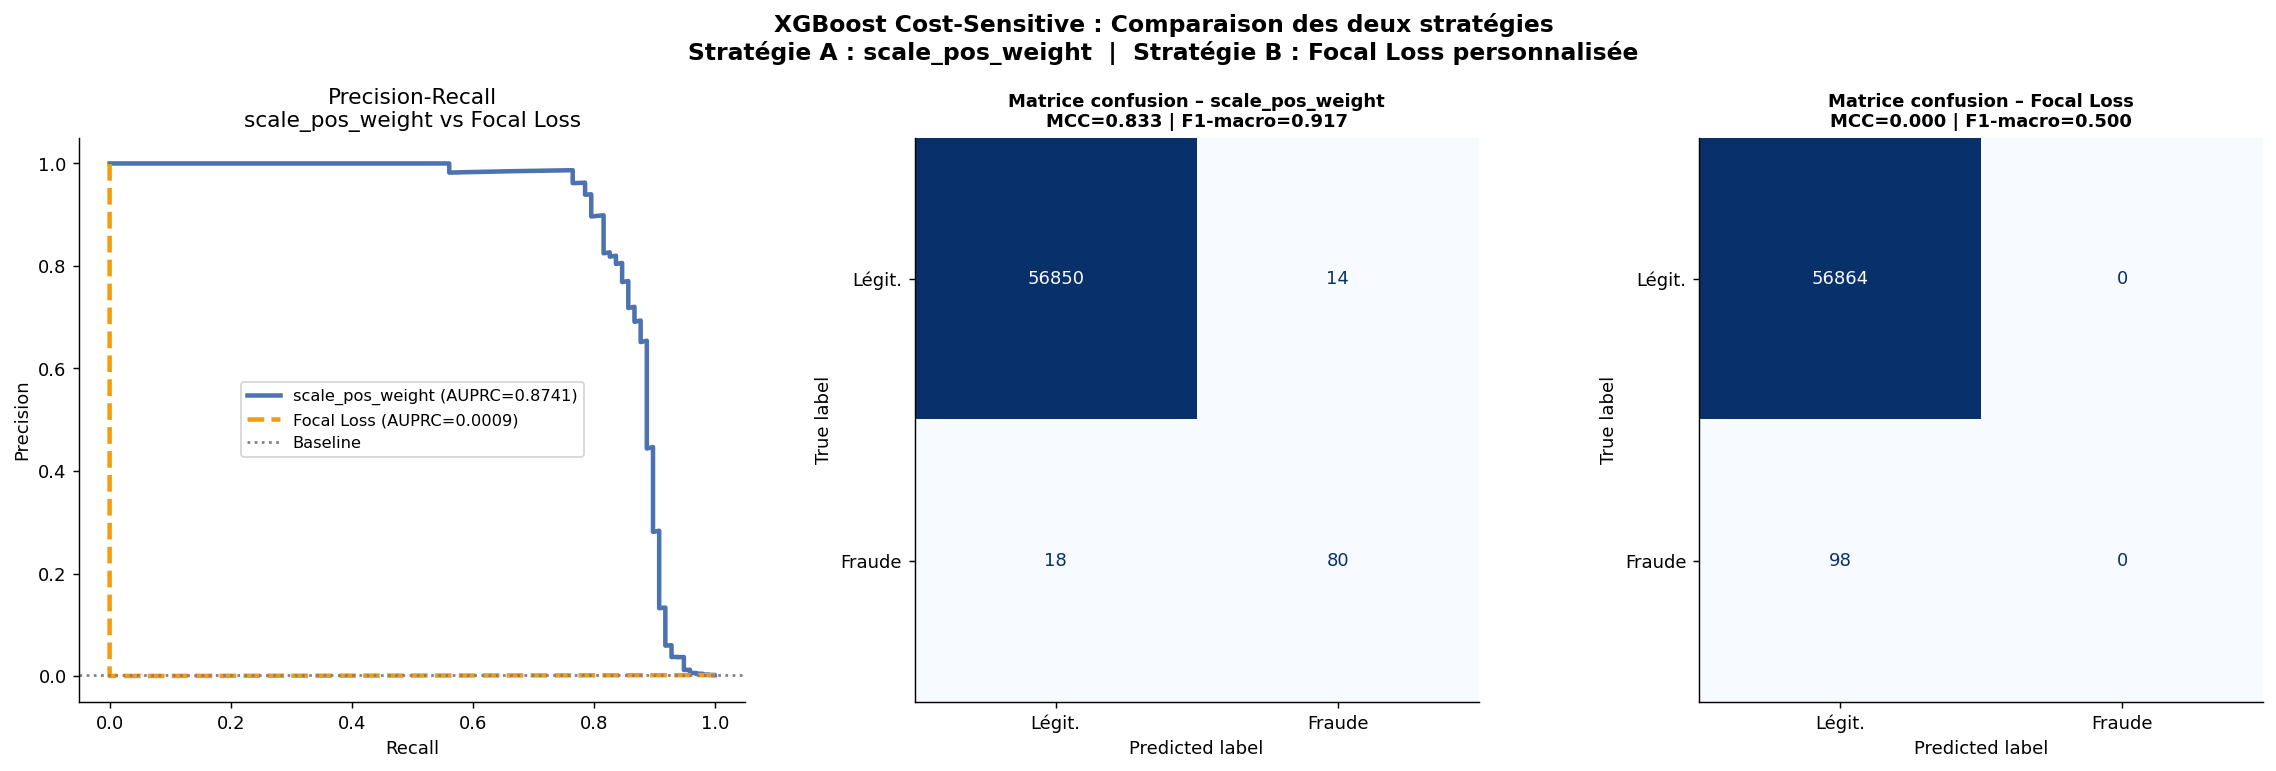


── Justification de l'espace de recherche Optuna ──

  max_depth [3, 10] :
    • min=3 : arbres trop superficiels → underfitting sur données complexes PCA.
    • max=10 : au-delà, risque d'overfitting sur ~100K obs avec 30+ features.
    • Zone optimale typique pour XGBoost sur données tabulaires : 4-8.

  lambda (L2) et alpha (L1) [1e-3, 10], log-uniforme :
    • Régularisation essentielle face au déséquilibre 577:1.
    • Échelle logarithmique : plage de 4 ordres de grandeur
      pour explorer aussi bien les petites (0.001) que grandes (10) valeurs.
    • lambda=L2 stabilise les gradients ; alpha=L1 induit la sparsité.

  learning_rate [0.01, 0.3], log-uniforme :
    • 0.01 : convergence lente mais régulière (besoin de +rounds).
    • 0.3 : apprentissage rapide mais risque d'oscillations.
    • Couplé à n_estimators=200 : permet une exploration équilibrée.

  scale_pos_weight [spw×0.5, spw×1.5] :
    • Centré sur le ratio naturel (~577) ± 50%.
    • Variation modérée : le ratio nat

  0%|          | 0/50 [00:00<?, ?it/s]

✓ Meilleur MCC Optuna : 0.8528
  Params : {'max_depth': 6, 'lambda': 0.44196250930695724, 'alpha': 0.07311336494350935, 'learning_rate': 0.1769495725193969, 'scale_pos_weight': 471.5327550940943, 'subsample': 0.8021286352691814, 'colsample_bytree': 0.6046483846510212}
  ✓ fig08_optuna_history.png


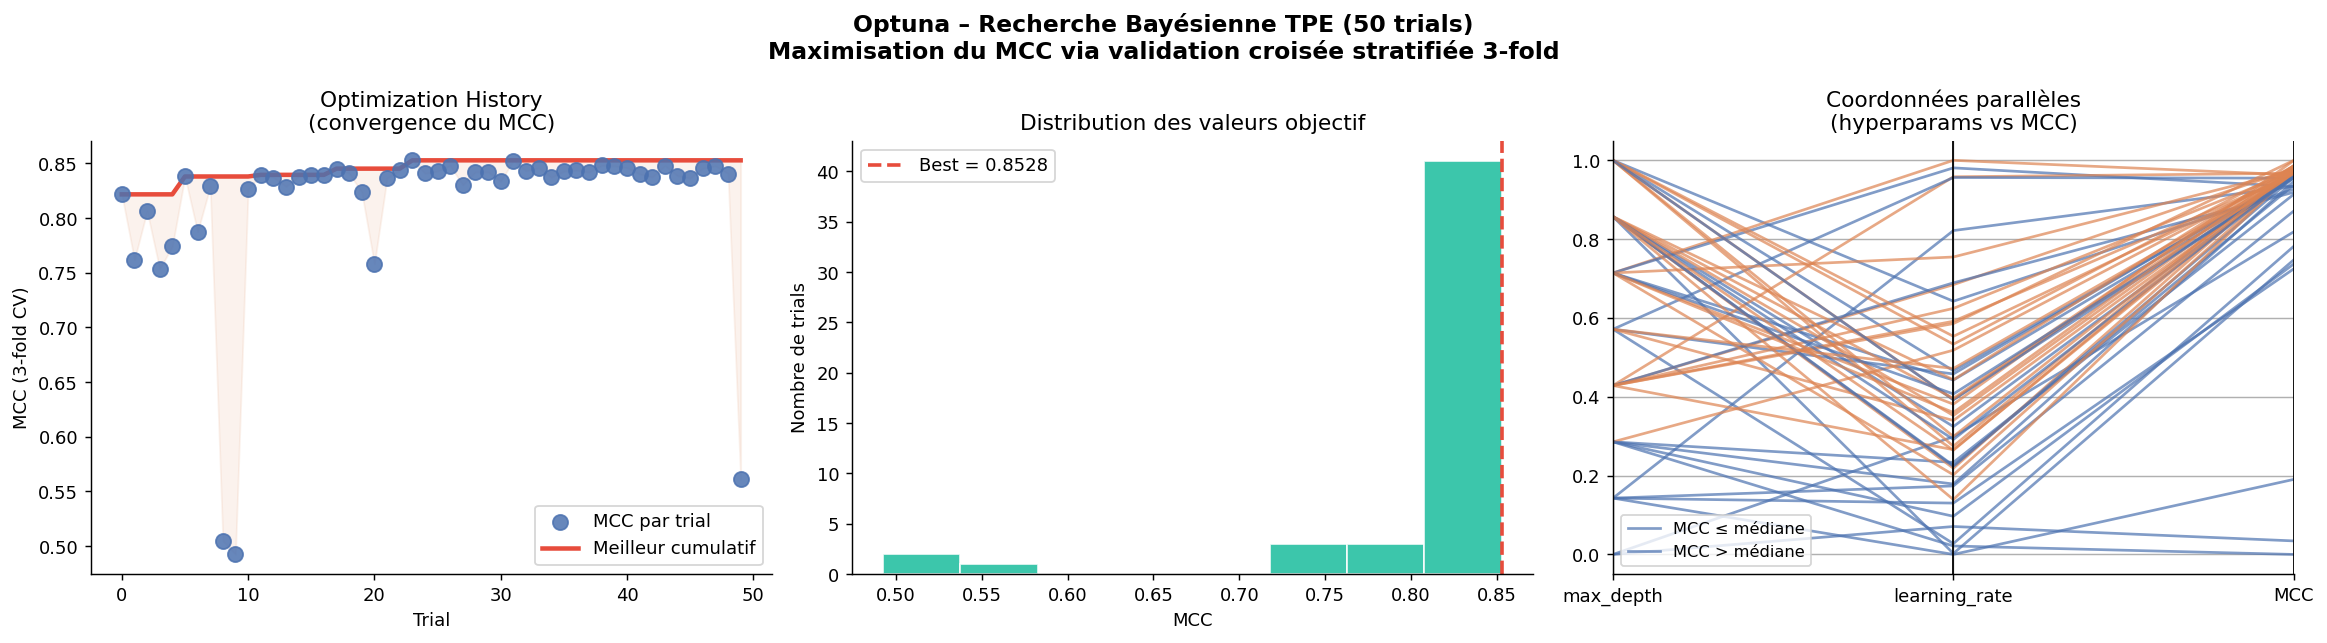

  ✓ fig09_optuna_hp_importance.png


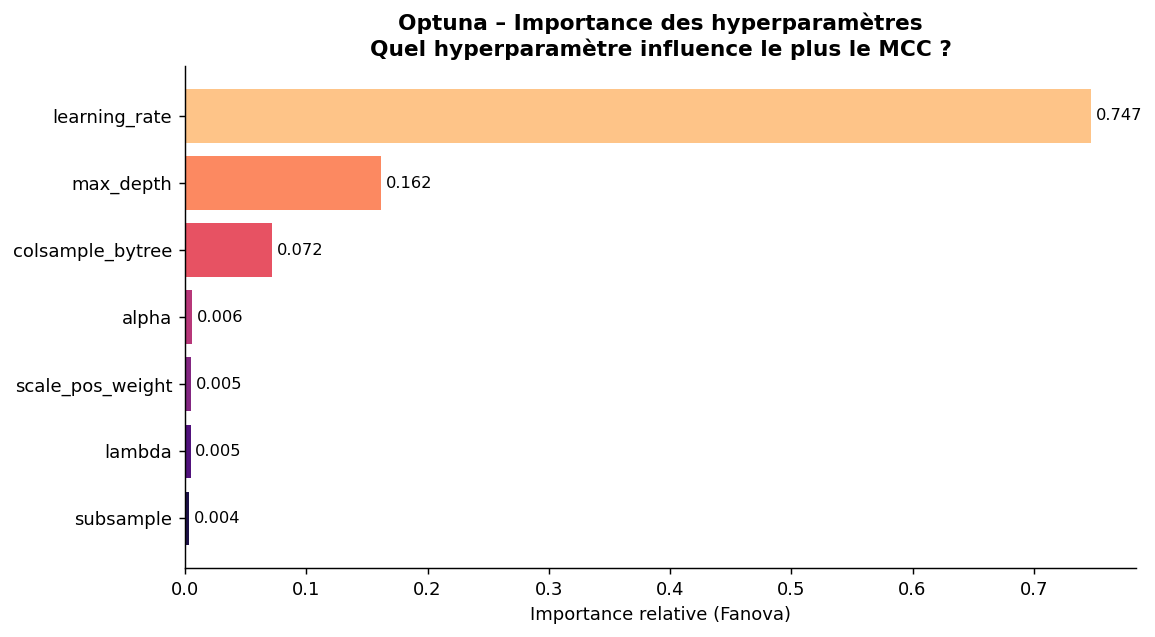


✓ XGBoost final entraîné.
              precision    recall  f1-score   support

      Légit.       1.00      1.00      1.00     56864
      Fraude       0.88      0.86      0.87        98

    accuracy                           1.00     56962
   macro avg       0.94      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Validation croisée stratifiée (3-fold) sur 30,000 observations…
              name  cv_f1_macro_mean  cv_f1_macro_std  cv_mcc_mean  cv_mcc_std
LogReg Elastic Net            0.5629           0.0130       0.2564      0.0185
     Random Forest            0.9184           0.0136       0.8395      0.0263
  XGBoost (Optuna)            0.9273           0.0194       0.8553      0.0391
  ✓ fig10_confusion_matrices.png


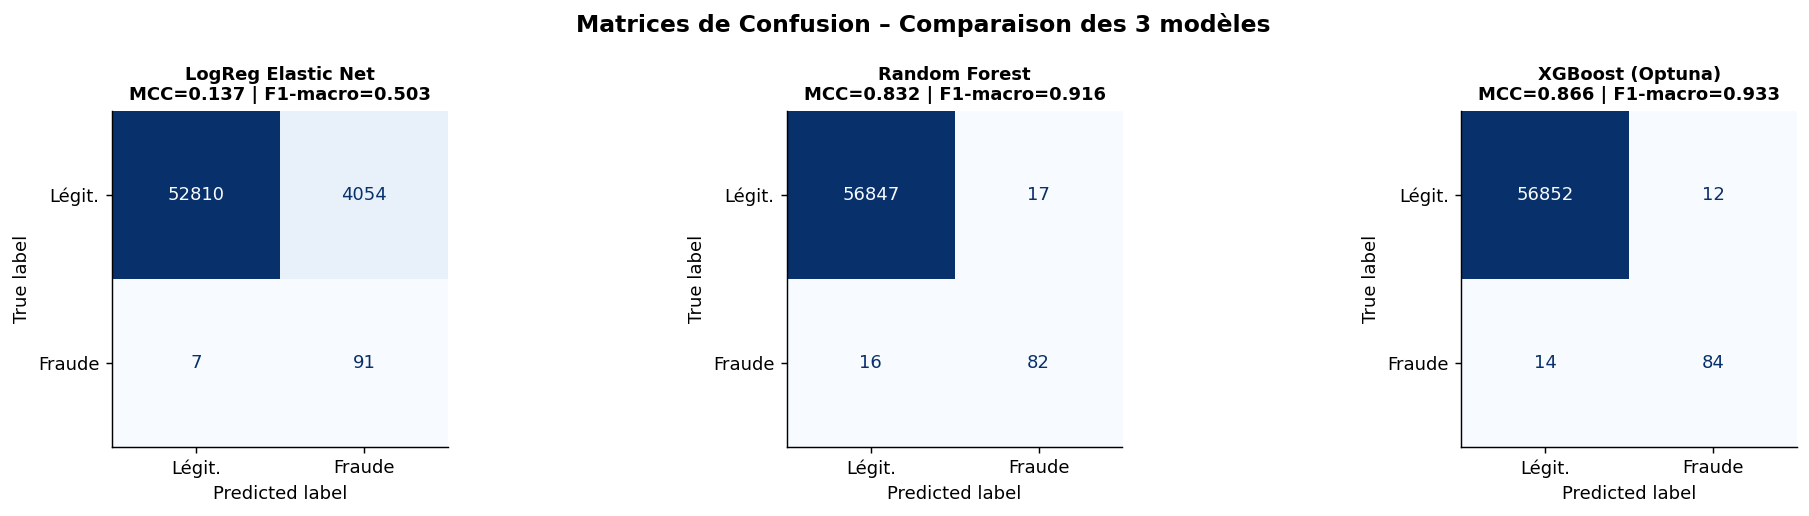


Calcul des learning curves (peut prendre quelques minutes)…
  ✓ fig11_learning_curves.png


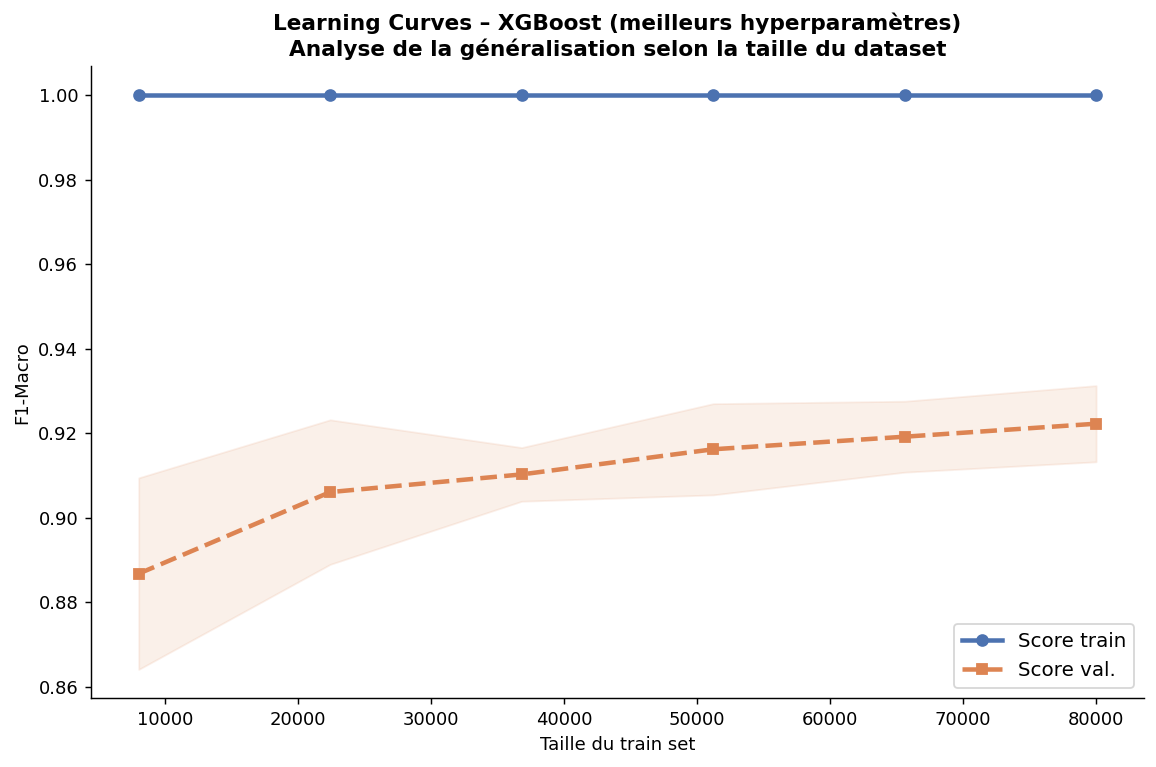


✓ Modèles sauvegardés → C:\Users\DELL\Desktop\IA_P1\etape2_models\trained_models.pkl

─────────────────────────────────────────────────────────────────
ÉTAPE 2 TERMINÉE – 11 figures dans : C:\Users\DELL\Desktop\IA_P1\etape2_models\figures
─────────────────────────────────────────────────────────────────


In [ ]:
print("\n── Modèle 3 : XGBoost Cost-Sensitive + Optuna ──")
neg_count = (y_train_model == 0).sum()
pos_count = (y_train_model == 1).sum()
spw_base  = neg_count / pos_count
print(f"scale_pos_weight naturel : {spw_base:.1f}")

# ── Stratégie A : scale_pos_weight ──────────────────────────────────────────
xgb_spw = xgb.XGBClassifier(
    scale_pos_weight=spw_base, n_estimators=150,
    max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE,
    tree_method="hist", n_jobs=-1, eval_metric="aucpr",
)
xgb_spw.fit(X_train_model, y_train_model, verbose=False)
y_pred_spw  = xgb_spw.predict(X_test)
y_proba_spw = xgb_spw.predict_proba(X_test)[:, 1]
mcc_spw = matthews_corrcoef(y_test, y_pred_spw)
print(f"[A] scale_pos_weight → MCC={mcc_spw:.4f}")

# ── Stratégie B : Focal Loss ─────────────────────────────────────────────────
def focal_loss(y_pred, dtrain, gamma=2.0, alpha=0.25):
    y_true = dtrain.get_label()
    p = 1.0 / (1.0 + np.exp(-y_pred))
    p_t = np.where(y_true==1, p, 1-p)
    a_t = np.where(y_true==1, alpha, 1-alpha)
    grad = -a_t*(1-p_t)**gamma*(gamma*p_t*np.log(p_t+1e-7)+p_t-1)
    hess = np.abs(a_t*(1-p_t)**gamma*(
        2*gamma*(1-p_t)*np.log(p_t+1e-7)+gamma*(gamma-1)*p_t+2*(1-p_t)+p_t-1
    )) + 1e-6
    return grad, hess

xgb_fl = xgb.XGBClassifier(
    n_estimators=150, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE,
    tree_method="hist", n_jobs=-1, eval_metric="aucpr",
)
dtrain_fl, X_val_fl, ytrain_fl, yval_fl = tts(
    X_train_model, y_train_model, test_size=0.20,
    stratify=y_train_model, random_state=RANDOM_STATE
)
dtrain = xgb.DMatrix(dtrain_fl, label=ytrain_fl)
dval   = xgb.DMatrix(X_val_fl, label=yval_fl)
dtest  = xgb.DMatrix(X_test,  label=y_test)
params_fl = dict(max_depth=6, learning_rate=0.1, eval_metric="aucpr",
                 tree_method="hist", seed=RANDOM_STATE, verbosity=0)
booster_fl = xgb.train(params_fl, dtrain, num_boost_round=150, obj=focal_loss)

# Seuil optimisé sur validation pour éviter l'effondrement à 0.5
y_proba_val_fl = booster_fl.predict(dval)
th_grid = np.linspace(0.02, 0.98, 97)
mcc_grid = [matthews_corrcoef(yval_fl, (y_proba_val_fl >= t).astype(int)) for t in th_grid]
best_th_fl = th_grid[int(np.argmax(mcc_grid))]

y_proba_fl = booster_fl.predict(dtest)
y_pred_fl  = (y_proba_fl >= best_th_fl).astype(int)
mcc_fl = matthews_corrcoef(y_test, y_pred_fl)
print(f"[B] Focal Loss        → MCC={mcc_fl:.4f} (seuil opt={best_th_fl:.2f})")

# FIG 07 – Comparaison scale_pos_weight vs focal loss
prec_spw, rec_spw, _ = precision_recall_curve(y_test, y_proba_spw)
prec_fl,  rec_fl,  _ = precision_recall_curve(y_test, y_proba_fl)
auprc_spw = auc(rec_spw, prec_spw)
auprc_fl  = auc(rec_fl,  prec_fl)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PR curves
ax = axes[0]
ax.plot(rec_spw, prec_spw, color=C["maj"], lw=2.5,
        label=f"scale_pos_weight (AUPRC={auprc_spw:.4f})")
ax.plot(rec_fl, prec_fl, color=C["orange"], lw=2.5, ls="--",
        label=f"Focal Loss (AUPRC={auprc_fl:.4f})")
ax.axhline(y_test.mean(), color="gray", ls=":", label="Baseline")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall\nscale_pos_weight vs Focal Loss")
ax.legend(fontsize=9)

# Confusion matrices côte à côte
for ax_i, (name_m, y_pred_m, col_m) in zip([axes[1], axes[2]], [
    ("scale_pos_weight", y_pred_spw, C["maj"]),
    ("Focal Loss",       y_pred_fl,  C["orange"]),
]):
    cm   = confusion_matrix(y_test, y_pred_m)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Légit.", "Fraude"])
    disp.plot(ax=ax_i, cmap="Blues", colorbar=False)
    mcc_m = matthews_corrcoef(y_test, y_pred_m)
    f1_m  = f1_score(y_test, y_pred_m, average="macro")
    ax_i.set_title(f"Matrice confusion – {name_m}\n"
                   f"MCC={mcc_m:.3f} | F1-macro={f1_m:.3f}",
                   fontsize=10, fontweight="bold")

plt.suptitle("XGBoost Cost-Sensitive : Comparaison des deux stratégies\n"
             "Stratégie A : scale_pos_weight  |  Stratégie B : Focal Loss personnalisée",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig07_cost_sensitive_comparison.png")
plt.show()

# ── Optuna (TPE, 10 trials) ───────────────────────────────────────────────────
def optuna_obj(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "lambda":           trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "alpha":            trial.suggest_float("alpha",  1e-3, 10.0, log=True),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight",
                                                  spw_base*0.5, spw_base*1.5),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "n_estimators": 200,
        "random_state": RANDOM_STATE, "tree_method": "hist", "n_jobs": -1,
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for fold, (ti, vi) in enumerate(skf.split(X_train_model, y_train_model)):
        m = xgb.XGBClassifier(**params)
        m.fit(X_train_model.iloc[ti], y_train_model.iloc[ti],
              eval_set=[(X_train_model.iloc[vi], y_train_model.iloc[vi])], verbose=False)
        scores.append(matthews_corrcoef(y_train_model.iloc[vi], m.predict(X_train_model.iloc[vi])))
        trial.report(np.mean(scores), step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return np.mean(scores)

# ── Justifications théoriques de l'espace de recherche Optuna ────────────────
print("\n── Justification de l'espace de recherche Optuna ──")
print("""
  max_depth [3, 10] :
    • min=3 : arbres trop superficiels → underfitting sur données complexes PCA.
    • max=10 : au-delà, risque d'overfitting sur ~100K obs avec 30+ features.
    • Zone optimale typique pour XGBoost sur données tabulaires : 4-8.

  lambda (L2) et alpha (L1) [1e-3, 10], log-uniforme :
    • Régularisation essentielle face au déséquilibre 577:1.
    • Échelle logarithmique : plage de 4 ordres de grandeur
      pour explorer aussi bien les petites (0.001) que grandes (10) valeurs.
    • lambda=L2 stabilise les gradients ; alpha=L1 induit la sparsité.

  learning_rate [0.01, 0.3], log-uniforme :
    • 0.01 : convergence lente mais régulière (besoin de +rounds).
    • 0.3 : apprentissage rapide mais risque d'oscillations.
    • Couplé à n_estimators=200 : permet une exploration équilibrée.

  scale_pos_weight [spw×0.5, spw×1.5] :
    • Centré sur le ratio naturel (~577) ± 50%.
    • Variation modérée : le ratio naturel est déjà un point de départ solide.

  subsample et colsample_bytree [0.6, 1.0] :
    • 0.6 : assure suffisamment de diversité pour réduire la variance.
    • 1.0 : utilise toutes les données/features (sans sous-échantillonnage).
    • En-dessous de 0.5 : risque de perte d'information sur la classe minoritaire.
""")

print("\nOptuna (50 trials TPE)…")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(optuna_obj, n_trials=50, show_progress_bar=True)
print(f"✓ Meilleur MCC Optuna : {study.best_value:.4f}")
print(f"  Params : {study.best_params}")

# FIG 08 – Convergence Optuna
completed = [t for t in study.trials if t.state.name == "COMPLETE"]
t_nums = [t.number for t in completed]
t_vals = [t.value  for t in completed]
best_sf = pd.Series(t_vals).cummax().tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(t_nums, t_vals, color=C["maj"], s=70, alpha=0.85, zorder=3,
           label="MCC par trial")
ax.plot(t_nums, best_sf, color=C["red"], lw=2.5, label="Meilleur cumulatif")
ax.fill_between(t_nums, t_vals, best_sf, alpha=0.1, color=C["min"])
ax.set_xlabel("Trial"); ax.set_ylabel("MCC (3-fold CV)")
ax.set_title("Optimization History\n(convergence du MCC)")
ax.legend()

ax = axes[1]
ax.hist(t_vals, bins=8, color=C["teal"], edgecolor="white", alpha=0.85)
ax.axvline(study.best_value, color=C["red"], ls="--", lw=2,
           label=f"Best = {study.best_value:.4f}")
ax.set_xlabel("MCC"); ax.set_ylabel("Nombre de trials")
ax.set_title("Distribution des valeurs objectif")
ax.legend()

# Parallel coordinate (hyperparams vs MCC)
ax = axes[2]
trials_df = pd.DataFrame([
    {**t.params, "MCC": t.value}
    for t in completed if t.value is not None
])
if len(trials_df) > 0:
    from pandas.plotting import parallel_coordinates
    cols_show = ["max_depth", "learning_rate", "MCC"]
    cols_show = [c for c in cols_show if c in trials_df.columns]
    trials_norm = trials_df[cols_show].copy()
    for col in cols_show:
        rng = trials_norm[col].max() - trials_norm[col].min()
        if rng > 0:
            trials_norm[col] = (trials_norm[col] - trials_norm[col].min()) / rng
    trials_norm["_label"] = (trials_df["MCC"] > trials_df["MCC"].median()).astype(str)
    parallel_coordinates(trials_norm[cols_show + ["_label"]], "_label",
                         color=[C["maj"], C["min"]], alpha=0.7, ax=ax)
    ax.set_title("Coordonnées parallèles\n(hyperparams vs MCC)")
    ax.legend(["MCC ≤ médiane", "MCC > médiane"], fontsize=9)

plt.suptitle("Optuna – Recherche Bayésienne TPE (50 trials)\n"
             "Maximisation du MCC via validation croisée stratifiée 3-fold",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig08_optuna_history.png")
plt.show()

# FIG 09 – Importance des hyperparamètres
try:
    hp_imp = optuna.importance.get_param_importances(study)
    fig, ax = plt.subplots(figsize=(9, 5))
    names_h = list(hp_imp.keys())[::-1]
    vals_h  = list(hp_imp.values())[::-1]
    pal_h   = sns.color_palette("magma", len(names_h))
    bars_h  = ax.barh(names_h, vals_h, color=pal_h)
    for bar, v in zip(bars_h, vals_h):
        ax.text(bar.get_width()+0.004, bar.get_y()+bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlabel("Importance relative (Fanova)")
    ax.set_title("Optuna – Importance des hyperparamètres\n"
                 "Quel hyperparamètre influence le plus le MCC ?",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    save_fig(fig, "fig09_optuna_hp_importance.png")
    plt.show()
except Exception as e:
    print(f"  (HP importance : {e})")

# ── XGBoost final (meilleurs params) ─────────────────────────────────────────
best_p = study.best_params.copy()
best_p.update({"n_estimators":300,
               "random_state":RANDOM_STATE,"tree_method":"hist","n_jobs":-1})
xgb_best = xgb.XGBClassifier(**best_p)
xgb_best.fit(X_train_model, y_train_model, verbose=False)
y_pred_xgb  = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]
print("\n✓ XGBoost final entraîné.")
print(classification_report(y_test, y_pred_xgb, target_names=["Légit.", "Fraude"]))

# ── Validation croisée (rigueur) ─────────────────────────────────────────────
cv_n = min(30000, len(X_train_model))
if cv_n < len(X_train_model):
    X_cv, _, y_cv, _ = tts(
        X_train_model, y_train_model, train_size=cv_n,
        stratify=y_train_model, random_state=RANDOM_STATE
    )
else:
    X_cv, y_cv = X_train_model, y_train_model

cv_models = [
    ("LogReg Elastic Net", clone(logreg)),
    ("Random Forest", clone(rf)),
    ("XGBoost (Optuna)", clone(xgb_best)),
]
skf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

print(f"\nValidation croisée stratifiée (3-fold) sur {len(X_cv):,} observations…")
for model_name, model_obj in cv_models:
    f1_fold, mcc_fold = [], []
    for tr_idx, va_idx in skf_cv.split(X_cv, y_cv):
        X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]
        model_obj.fit(X_tr, y_tr)
        y_hat = model_obj.predict(X_va)
        f1_fold.append(f1_score(y_va, y_hat, average="macro", zero_division=0))
        mcc_fold.append(matthews_corrcoef(y_va, y_hat))
    cv_rows.append({
        "name": model_name,
        "cv_f1_macro_mean": float(np.mean(f1_fold)),
        "cv_f1_macro_std": float(np.std(f1_fold)),
        "cv_mcc_mean": float(np.mean(mcc_fold)),
        "cv_mcc_std": float(np.std(mcc_fold)),
    })

cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# FIG 10 – Matrices de confusion (3 modèles)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name_m, y_pred_m) in zip(axes, [
    ("LogReg Elastic Net", y_pred_lr),
    ("Random Forest",      y_pred_rf),
    ("XGBoost (Optuna)",   y_pred_xgb),
]):
    cm   = confusion_matrix(y_test, y_pred_m)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Légit.", "Fraude"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    mcc_m = matthews_corrcoef(y_test, y_pred_m)
    f1_m  = f1_score(y_test, y_pred_m, average="macro")
    ax.set_title(f"{name_m}\nMCC={mcc_m:.3f} | F1-macro={f1_m:.3f}",
                 fontsize=10, fontweight="bold")

plt.suptitle("Matrices de Confusion – Comparaison des 3 modèles",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig10_confusion_matrices.png")
plt.show()

# FIG 11 – Learning curves XGBoost
print("\nCalcul des learning curves (peut prendre quelques minutes)…")
train_sizes, train_sc, val_sc = learning_curve(
    xgb_best, X_train_model, y_train_model,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_sc.mean(1), "o-", color=C["maj"], lw=2.5, label="Score train")
ax.plot(train_sizes, val_sc.mean(1),   "s--", color=C["min"], lw=2.5, label="Score val.")
ax.fill_between(train_sizes,
                train_sc.mean(1)-train_sc.std(1),
                train_sc.mean(1)+train_sc.std(1), alpha=0.12, color=C["maj"])
ax.fill_between(train_sizes,
                val_sc.mean(1)-val_sc.std(1),
                val_sc.mean(1)+val_sc.std(1), alpha=0.12, color=C["min"])
ax.set_xlabel("Taille du train set"); ax.set_ylabel("F1-Macro")
ax.set_title("Learning Curves – XGBoost (meilleurs hyperparamètres)\n"
             "Analyse de la généralisation selon la taille du dataset",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
save_fig(fig, "fig11_learning_curves.png")
plt.show()

# ── Sauvegarde ────────────────────────────────────────────────────────────────
models = {
    "logreg":      logreg,
    "rf":          rf,
    "xgb_best":    xgb_best,
    "xgb_spw":     xgb_spw,
    "y_pred_lr":   y_pred_lr,   "y_proba_lr":  y_proba_lr,
    "y_pred_rf":   y_pred_rf,   "y_proba_rf":  y_proba_rf,
    "y_pred_xgb":  y_pred_xgb,  "y_proba_xgb": y_proba_xgb,
    "y_pred_spw":  y_pred_spw,  "y_proba_spw": y_proba_spw,
    "y_proba_fl":  y_proba_fl,
    "best_threshold_fl": best_th_fl,
    "study":       study,
    "spw_base":    spw_base,
    "cv_results":  cv_df,
    "sample_idx":  s_idx,
    "out_scores":  out_sc,
}
with open(OUT_PKL, "wb") as f:
    pickle.dump(models, f)

print(f"\n✓ Modèles sauvegardés → {OUT_PKL}")
print("\n" + "─"*65)
print(f"ÉTAPE 2 TERMINÉE – 11 figures dans : {FIG_DIR}")
print("─"*65)


---
# Etape 3 : Evaluation Avancee et Calibration

*F1-Macro, AUPRC, MCC, Reliability Diagrams, Platt Scaling, Isotonic Regression*


ÉTAPE 3 – Évaluation et Calibration

Métriques :
                name  F1-Macro    AUPRC      MCC    AUROC    Brier
LogReg (Elastic Net)  0.502934 0.708130 0.136774 0.976211 0.141609
       Random Forest  0.916099 0.827660 0.832208 0.971093 0.000726
    XGBoost (Optuna)  0.932875 0.877148 0.865797 0.971194 0.000418
  ✓ fig01_precision_recall_curves.png


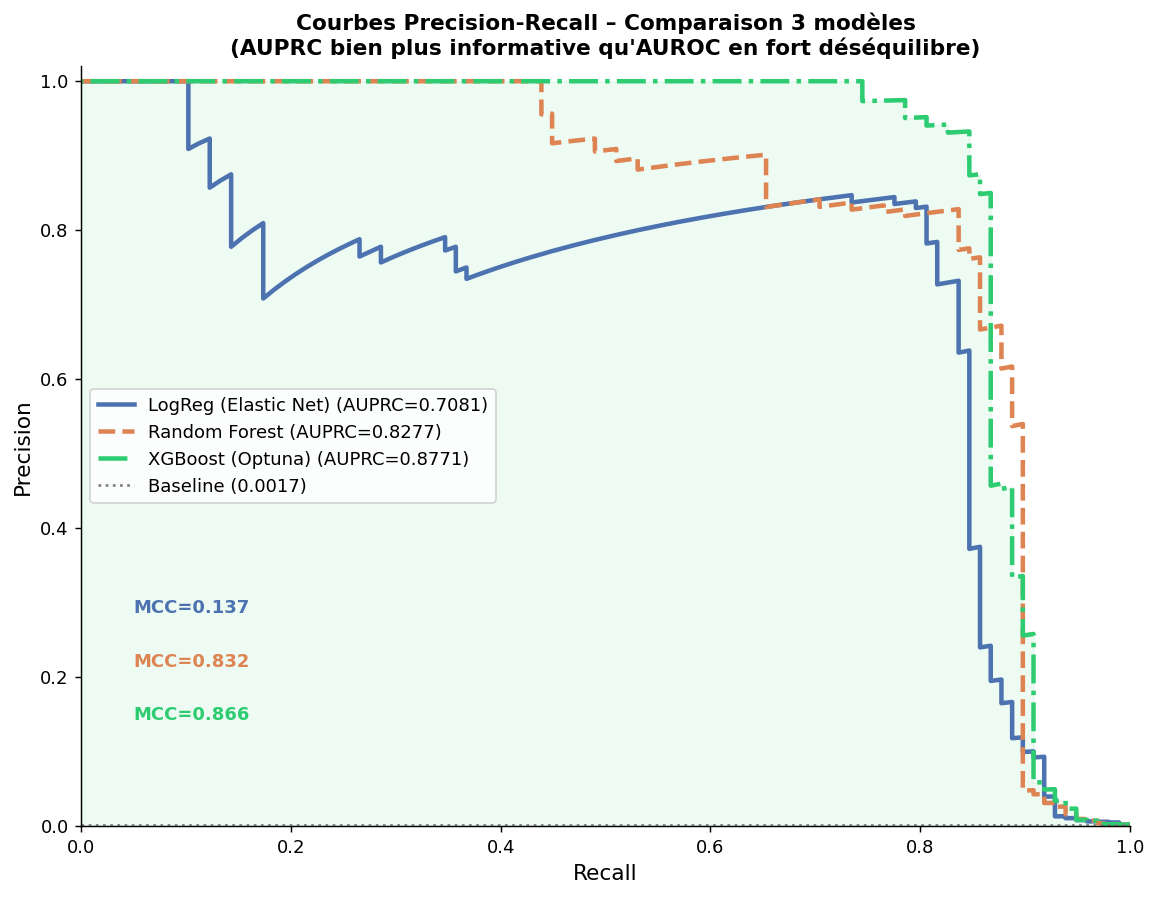

  ✓ fig02_roc_curves.png


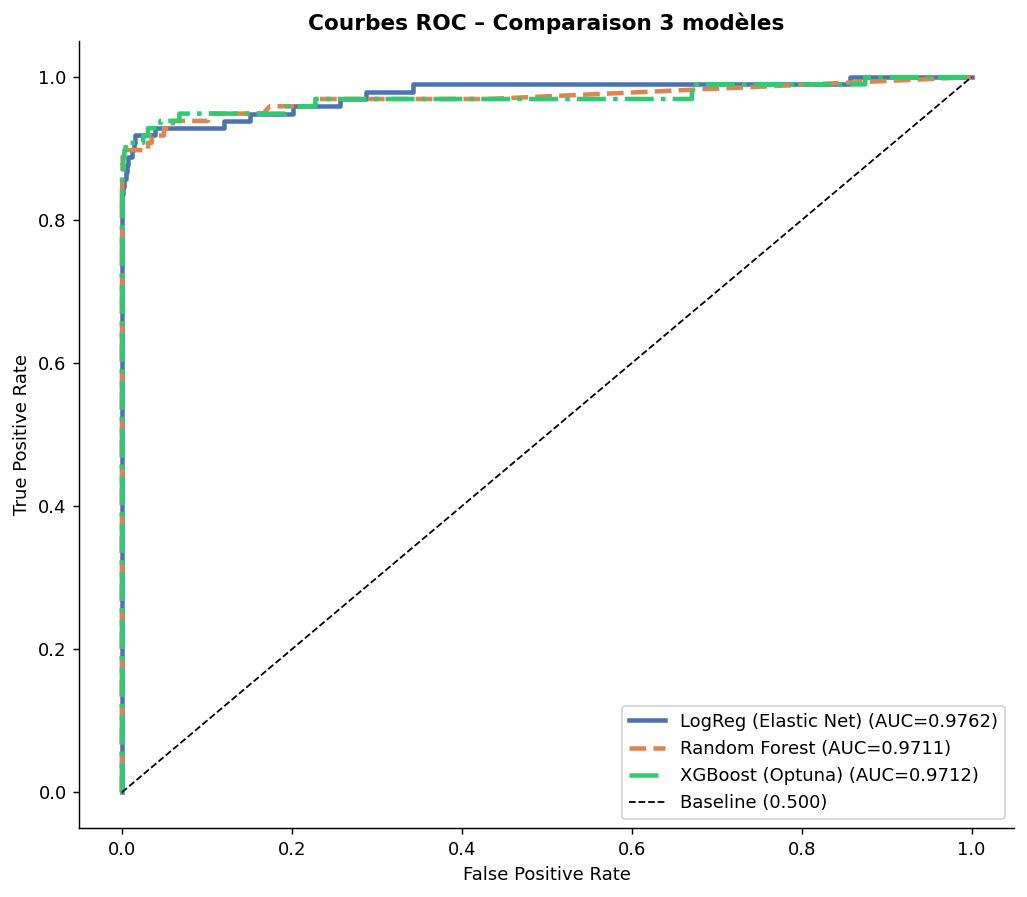

  ✓ fig03_metrics_heatmap.png


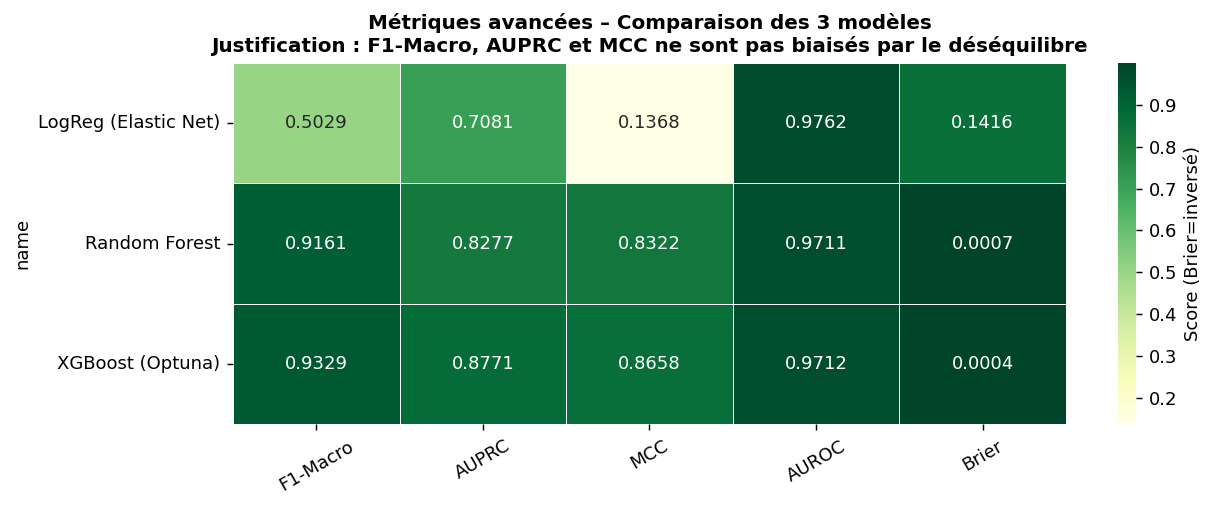


Métriques après calibration :
  XGBoost brut         → MCC=0.8750 | F1=0.9374 | Brier=0.00040
  Platt Scaling        → MCC=0.8750 | F1=0.9374 | Brier=0.00038
  Isotonic             → MCC=0.8845 | F1=0.9420 | Brier=0.00034
  ✓ fig04_reliability_diagrams.png


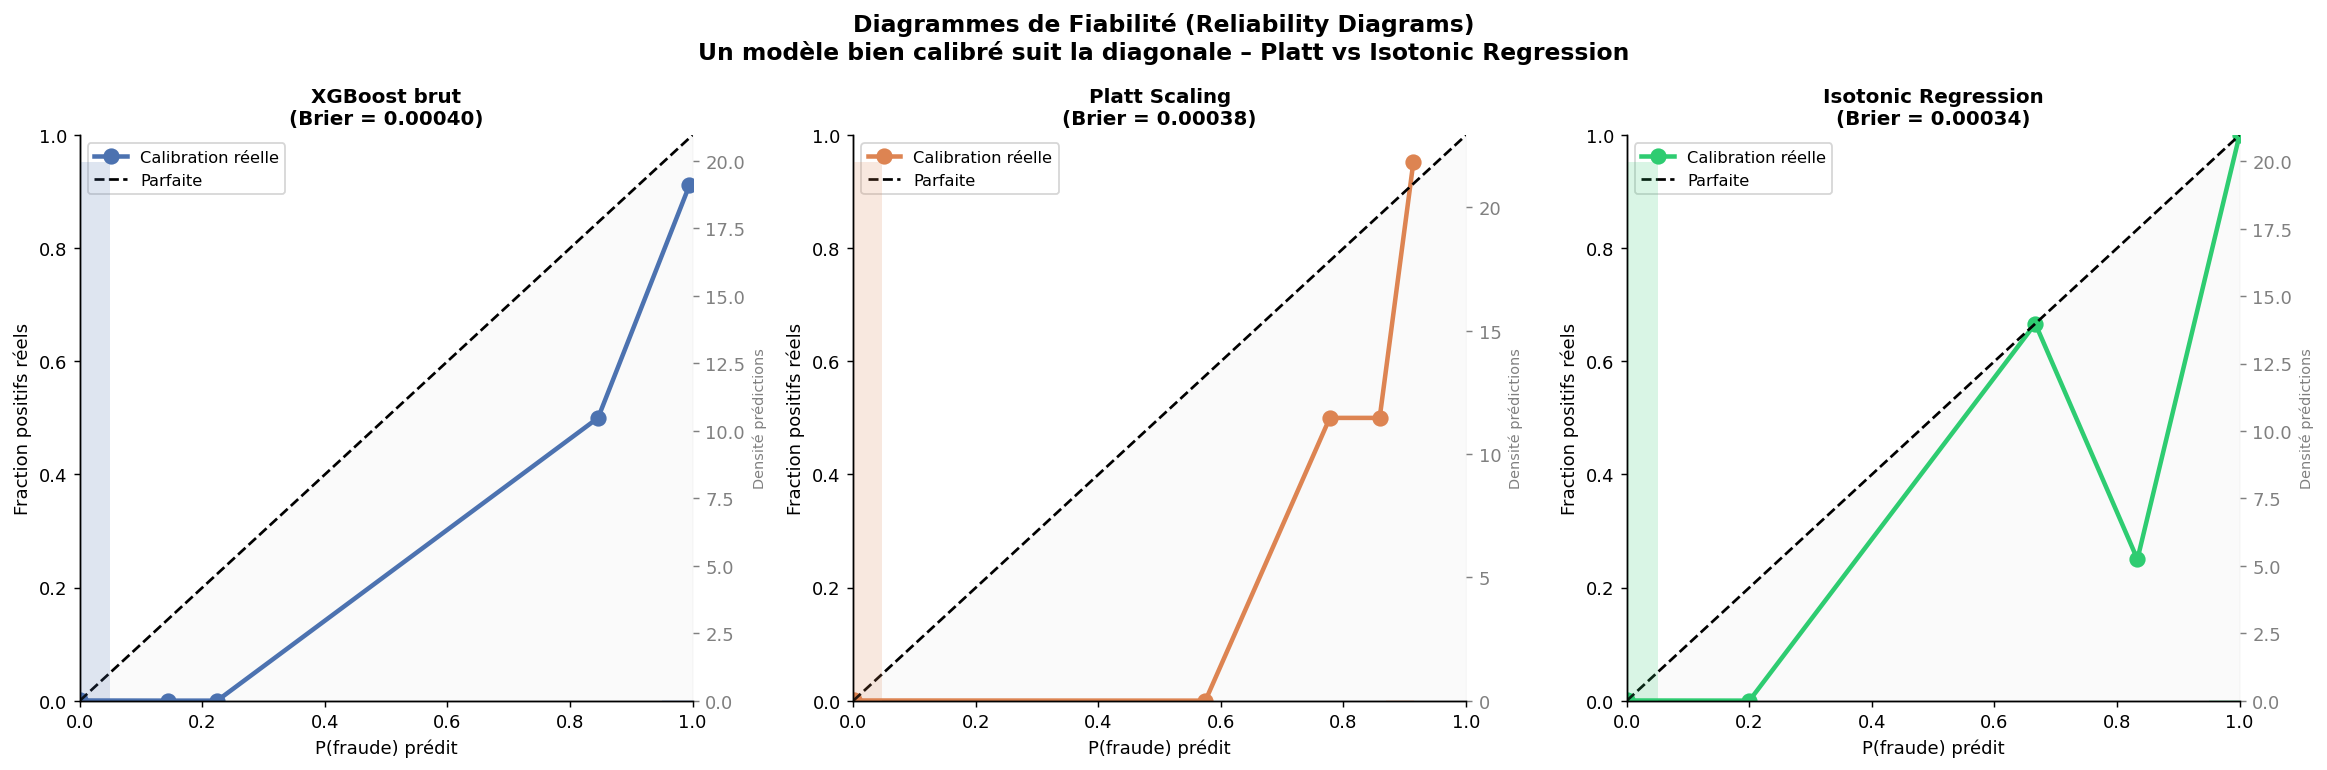

  ✓ fig05_proba_distributions.png


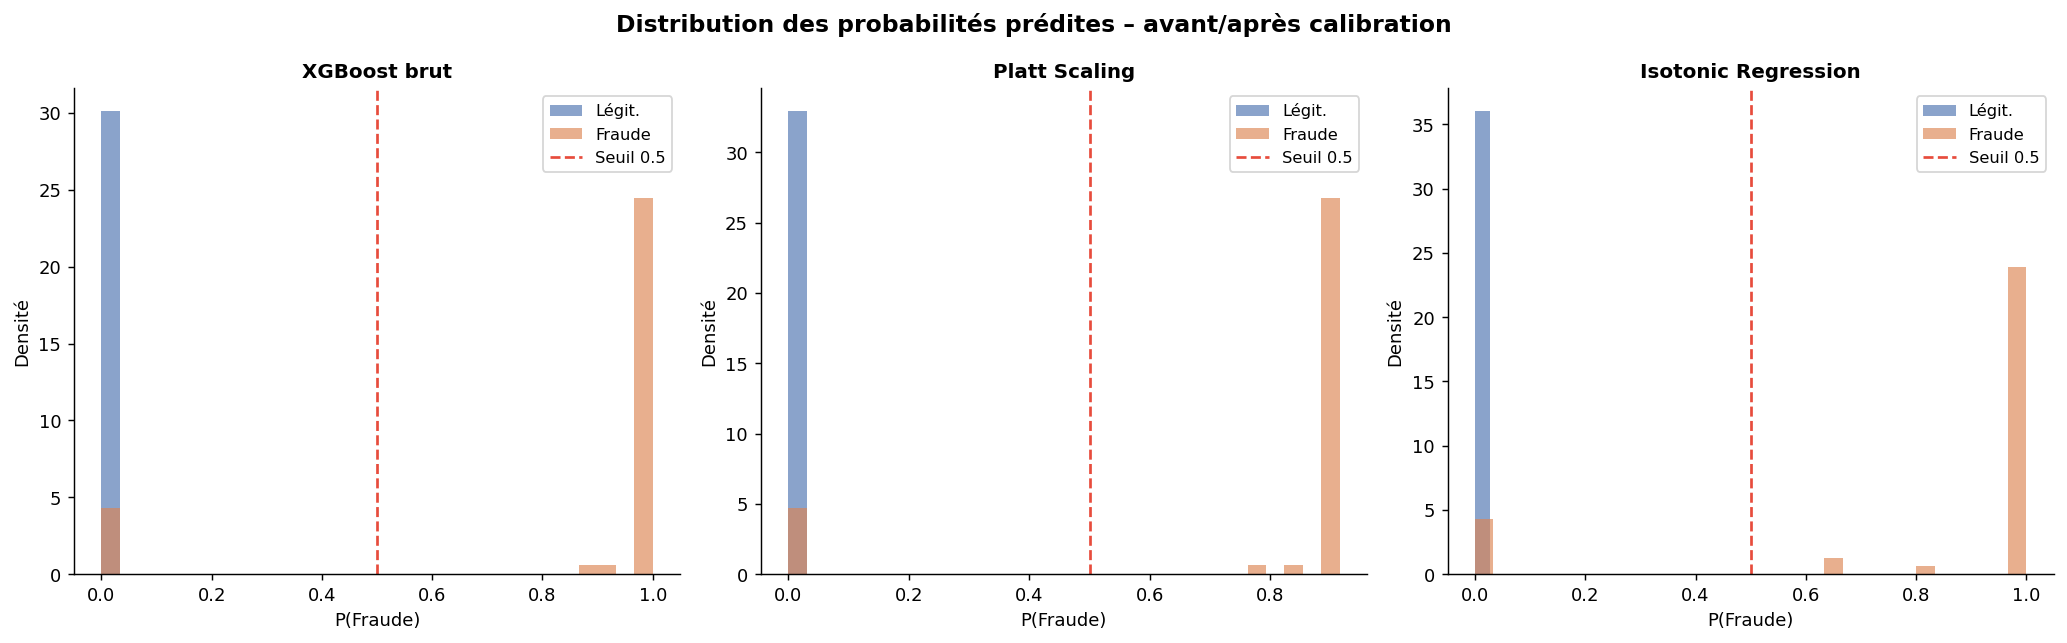

  ✓ fig06_threshold_analysis.png


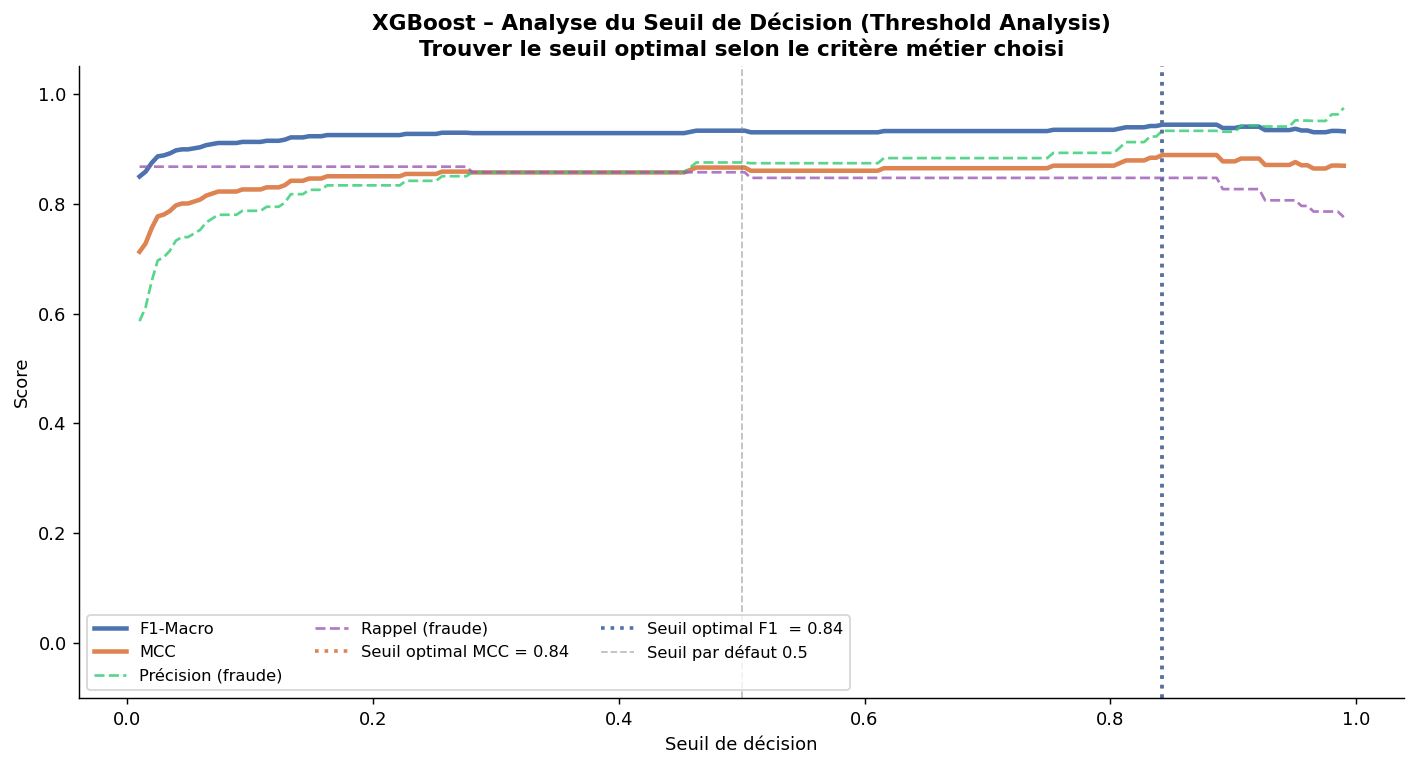

  Seuil optimal MCC=0.84 | F1=0.84
  ✓ fig07_metrics_radar.png


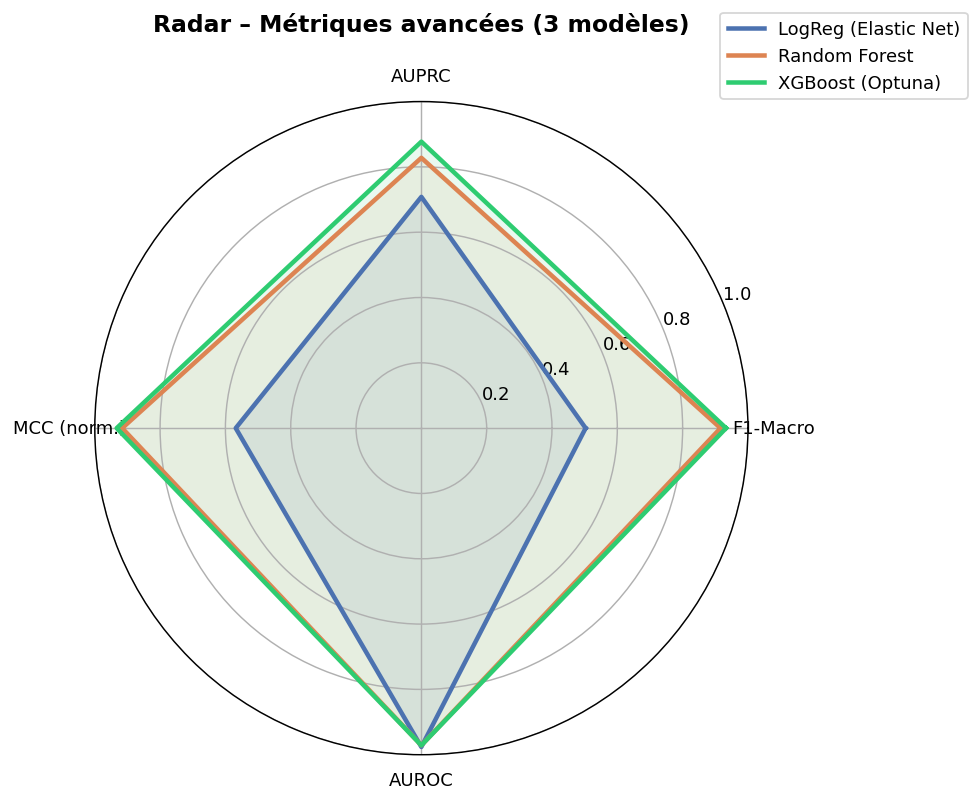

  ✓ fig08_brier_score_comparison.png


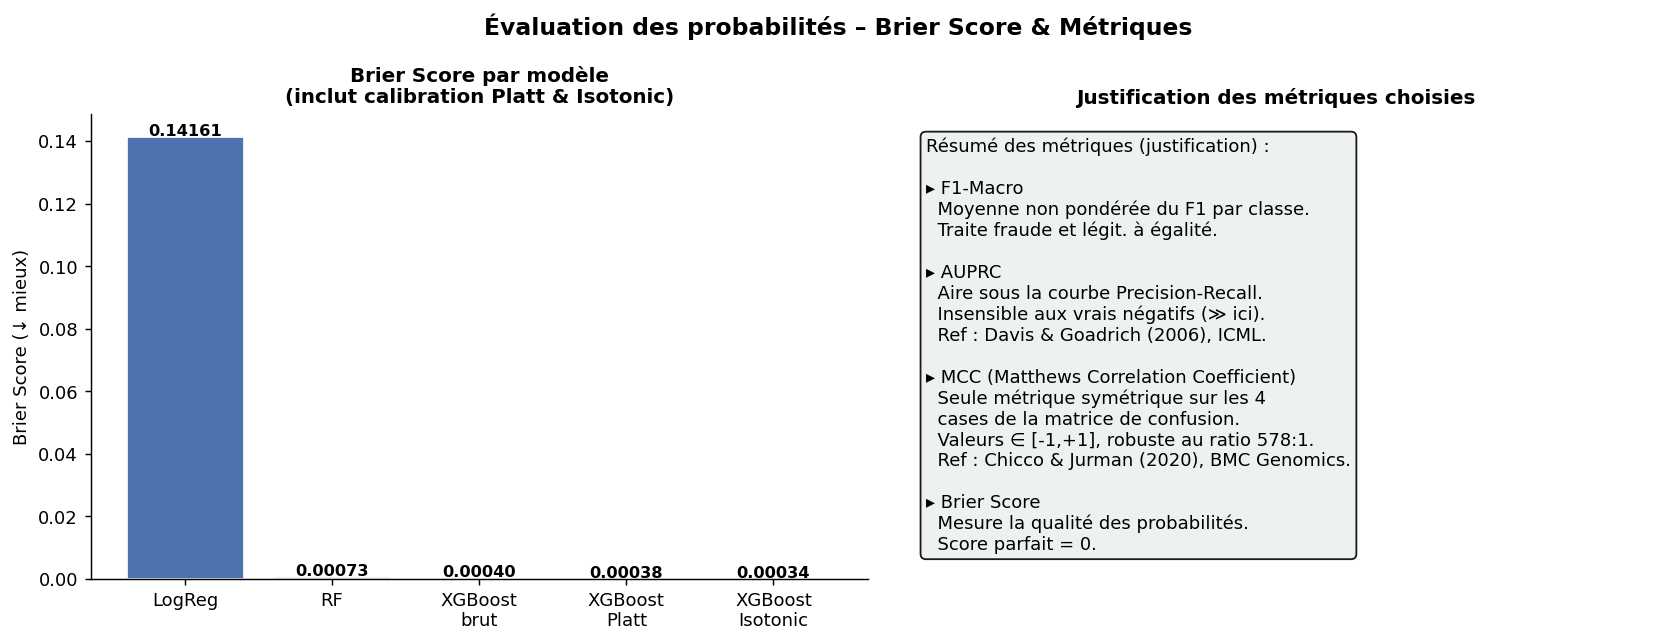


✓ Sauvegardé → C:\Users\DELL\Desktop\IA_P1\etape3_evaluation\calibrated_models.pkl

─────────────────────────────────────────────────────────────────
ÉTAPE 3 TERMINÉE – 8 figures dans : C:\Users\DELL\Desktop\IA_P1\etape3_evaluation\figures
─────────────────────────────────────────────────────────────────


In [ ]:
import sys


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
try:
    from sklearn.frozen import FrozenEstimator
except ImportError:
    FrozenEstimator = None
from sklearn.metrics import (
    f1_score, precision_recall_curve, auc,
    matthews_corrcoef, roc_curve, roc_auc_score,
    brier_score_loss, precision_score, recall_score,
)
from matplotlib.patches import Patch
import pickle

ROOT      = ROOT
FIG_DIR   = ROOT / "etape3_evaluation" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_PKL  = ROOT / "etape1_eda"    / "prepared_data.pkl"
MODEL_PKL = ROOT / "etape2_models" / "trained_models.pkl"
OUT_PKL   = ROOT / "etape3_evaluation"  / "calibrated_models.pkl"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False,"axes.spines.right":False})
C = {"maj":"#4C72B0","min":"#DD8452","green":"#2ecc71","purple":"#9b59b6",
     "red":"#e74c3c","orange":"#f39c12","teal":"#1abc9c","dark":"#2c3e50"}

def save_fig(fig, name):
    p = FIG_DIR / name
    fig.savefig(p, bbox_inches="tight", dpi=130)
    print(f"  ✓ {name}")

with open(DATA_PKL,  "rb") as f: data   = pickle.load(f)
with open(MODEL_PKL, "rb") as f: models = pickle.load(f)

X_train=data["X_train"]; X_test=data["X_test"]
y_train=data["y_train"]; y_test=data["y_test"]
logreg=models["logreg"]; rf=models["rf"]; xgb_best=models["xgb_best"]
y_pred_lr=models["y_pred_lr"];   y_proba_lr=models["y_proba_lr"]
y_pred_rf=models["y_pred_rf"];   y_proba_rf=models["y_proba_rf"]
y_pred_xgb=models["y_pred_xgb"]; y_proba_xgb=models["y_proba_xgb"]

print("="*65)
print("ÉTAPE 3 – Évaluation et Calibration")
print("="*65)

def compute_metrics(name, y_true, y_pred, y_proba):
    f1   = f1_score(y_true, y_pred, average="macro")
    mcc  = matthews_corrcoef(y_true, y_pred)
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    auprc = auc(rec, prec)
    brier = brier_score_loss(y_true, y_proba)
    auroc = roc_auc_score(y_true, y_proba)
    return {"name":name,"F1-Macro":f1,"AUPRC":auprc,"MCC":mcc,
            "AUROC":auroc,"Brier":brier,"precision":prec,"recall":rec}

results = [
    compute_metrics("LogReg (Elastic Net)", y_test, y_pred_lr,  y_proba_lr),
    compute_metrics("Random Forest",        y_test, y_pred_rf,  y_proba_rf),
    compute_metrics("XGBoost (Optuna)",     y_test, y_pred_xgb, y_proba_xgb),
]
metrics_df = pd.DataFrame([{k:v for k,v in r.items()
                             if k not in ["precision","recall"]}
                            for r in results])
print("\nMétriques :")
print(metrics_df[["name","F1-Macro","AUPRC","MCC","AUROC","Brier"]].to_string(index=False))

colors_ = [C["maj"], C["min"], C["green"]]
styles_ = ["-","--","-."]

# FIG 01 – Precision-Recall
fig, ax = plt.subplots(figsize=(9, 7))
for res, col, ls in zip(results, colors_, styles_):
    ax.plot(res["recall"], res["precision"], color=col, lw=2.5, ls=ls,
            label=f"{res['name']} (AUPRC={res['AUPRC']:.4f})")
ax.axhline(y_test.mean(), color="gray", ls=":", lw=1.5,
           label=f"Baseline ({y_test.mean():.4f})")
ax.fill_between(results[2]["recall"], results[2]["precision"], alpha=0.08, color=C["green"])
for i, res in enumerate(results):
    ax.annotate(f"MCC={res['MCC']:.3f}", xy=(0.05, 0.28-i*0.07),
                color=colors_[i], fontsize=10, fontweight="bold",
                xycoords="axes fraction")
ax.set_xlabel("Recall", fontsize=12); ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Courbes Precision-Recall – Comparaison 3 modèles\n"
             "(AUPRC bien plus informative qu'AUROC en fort déséquilibre)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.tight_layout()
save_fig(fig, "fig01_precision_recall_curves.png")
plt.show()

# FIG 02 – ROC
fig, ax = plt.subplots(figsize=(8, 7))
for res, col, ls, yp in zip(results, colors_, styles_,
                              [y_proba_lr, y_proba_rf, y_proba_xgb]):
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax.plot(fpr, tpr, color=col, lw=2.5, ls=ls,
            label=f"{res['name']} (AUC={res['AUROC']:.4f})")
ax.plot([0,1],[0,1],"k--",lw=1,label="Baseline (0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Courbes ROC – Comparaison 3 modèles",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_fig(fig, "fig02_roc_curves.png")
plt.show()

# FIG 03 – Heatmap métriques
fig, ax = plt.subplots(figsize=(10, 4))
hm_df = metrics_df.set_index("name")[["F1-Macro","AUPRC","MCC","AUROC","Brier"]].copy()
hm_n  = hm_df.copy(); hm_n["Brier"] = 1 - hm_n["Brier"]
sns.heatmap(hm_n.astype(float), annot=hm_df.round(4).values,
            fmt="", cmap="YlGn", ax=ax, linewidths=0.5,
            cbar_kws={"label":"Score (Brier=inversé)"})
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
ax.set_title("Métriques avancées – Comparaison des 3 modèles\n"
             "Justification : F1-Macro, AUPRC et MCC ne sont pas biaisés par le déséquilibre",
             fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig03_metrics_heatmap.png")
plt.show()

# ── Calibration ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split as tts
X_cal, X_eval, y_cal, y_eval = tts(
    X_test, y_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_test
)
if FrozenEstimator is not None:
    xgb_platt = CalibratedClassifierCV(
        FrozenEstimator(xgb_best), method="sigmoid", cv=None
    )
else:
    xgb_platt = CalibratedClassifierCV(xgb_best, method="sigmoid", cv="prefit")
xgb_platt.fit(X_cal, y_cal)
y_proba_platt = xgb_platt.predict_proba(X_eval)[:, 1]
y_pred_platt  = xgb_platt.predict(X_eval)

if FrozenEstimator is not None:
    xgb_iso = CalibratedClassifierCV(
        FrozenEstimator(xgb_best), method="isotonic", cv=None
    )
else:
    xgb_iso = CalibratedClassifierCV(xgb_best, method="isotonic", cv="prefit")
xgb_iso.fit(X_cal, y_cal)
y_proba_iso = xgb_iso.predict_proba(X_eval)[:, 1]
y_pred_iso  = xgb_iso.predict(X_eval)

y_proba_raw_eval = xgb_best.predict_proba(X_eval)[:, 1]
y_pred_raw_eval  = xgb_best.predict(X_eval)

print("\nMétriques après calibration :")
for nm, yp, ypred in [("XGBoost brut",y_proba_raw_eval,y_pred_raw_eval),
                       ("Platt Scaling",y_proba_platt,y_pred_platt),
                       ("Isotonic",y_proba_iso,y_pred_iso)]:
    print(f"  {nm:20s} → MCC={matthews_corrcoef(y_eval,ypred):.4f} "
          f"| F1={f1_score(y_eval,ypred,average='macro'):.4f} "
          f"| Brier={brier_score_loss(y_eval,yp):.5f}")

# FIG 04 – Reliability Diagrams (3 panneaux)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
versions = [
    ("XGBoost brut",        y_proba_raw_eval, C["maj"]),
    ("Platt Scaling",       y_proba_platt,    C["min"]),
    ("Isotonic Regression", y_proba_iso,      C["green"]),
]
for ax, (nm, yp, col) in zip(axes, versions):
    frac, mean_p = calibration_curve(y_eval, yp, n_bins=10, strategy="uniform")
    br = brier_score_loss(y_eval, yp)
    ax.plot(mean_p, frac, marker="o", color=col, lw=2.5, ms=8,
            label="Calibration réelle")
    ax.plot([0,1],[0,1],"k--",lw=1.5,label="Parfaite")
    ax.fill_between([0,1],[0,1],alpha=0.04,color="gray")
    ax2 = ax.twinx()
    ax2.hist(yp, bins=20, color=col, alpha=0.18, density=True)
    ax2.set_ylabel("Densité prédictions", color="gray", fontsize=8)
    ax2.tick_params(colors="gray")
    ax.set_xlabel("P(fraude) prédit"); ax.set_ylabel("Fraction positifs réels")
    ax.set_title(f"{nm}\n(Brier = {br:.5f})", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle("Diagrammes de Fiabilité (Reliability Diagrams)\n"
             "Un modèle bien calibré suit la diagonale – Platt vs Isotonic Regression",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig04_reliability_diagrams.png")
plt.show()

# FIG 05 – Distributions probabilités
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nm, yp, col) in zip(axes, versions):
    for cls, c_col, lbl in [(0,C["maj"],"Légit."),(1,C["min"],"Fraude")]:
        ax.hist(yp[y_eval==cls], bins=30, color=c_col, alpha=0.65, density=True, label=lbl)
    ax.axvline(0.5, color=C["red"], ls="--", lw=1.5, label="Seuil 0.5")
    ax.set_xlabel("P(Fraude)"); ax.set_ylabel("Densité")
    ax.set_title(nm, fontsize=11, fontweight="bold"); ax.legend(fontsize=9)
plt.suptitle("Distribution des probabilités prédites – avant/après calibration",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig05_proba_distributions.png")
plt.show()

# FIG 06 – Threshold analysis
thresholds = np.linspace(0.01, 0.99, 200)
f1_sc, mcc_sc, prec_sc, rec_sc = [], [], [], []
for t in thresholds:
    pt = (y_proba_xgb >= t).astype(int)
    f1_sc.append(f1_score(y_test, pt, average="macro", zero_division=0))
    mcc_sc.append(matthews_corrcoef(y_test, pt))
    prec_sc.append(precision_score(y_test, pt, pos_label=1, zero_division=0))
    rec_sc.append(recall_score(y_test, pt, pos_label=1, zero_division=0))

best_t_mcc = thresholds[np.argmax(mcc_sc)]
best_t_f1  = thresholds[np.argmax(f1_sc)]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(thresholds, f1_sc,   color=C["maj"],    lw=2.5, label="F1-Macro")
ax.plot(thresholds, mcc_sc,  color=C["min"],    lw=2.5, label="MCC")
ax.plot(thresholds, prec_sc, color=C["green"],  lw=1.5, ls="--", alpha=0.8, label="Précision (fraude)")
ax.plot(thresholds, rec_sc,  color=C["purple"], lw=1.5, ls="--", alpha=0.8, label="Rappel (fraude)")
ax.axvline(best_t_mcc, color=C["min"], ls=":", lw=2,
           label=f"Seuil optimal MCC = {best_t_mcc:.2f}")
ax.axvline(best_t_f1,  color=C["maj"], ls=":", lw=2,
           label=f"Seuil optimal F1  = {best_t_f1:.2f}")
ax.axvline(0.5, color="gray", ls="--", lw=1, alpha=0.5, label="Seuil par défaut 0.5")
ax.set_xlabel("Seuil de décision"); ax.set_ylabel("Score")
ax.set_title("XGBoost – Analyse du Seuil de Décision (Threshold Analysis)\n"
             "Trouver le seuil optimal selon le critère métier choisi",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, ncol=3); ax.set_ylim(-0.1, 1.05)
plt.tight_layout()
save_fig(fig, "fig06_threshold_analysis.png")
plt.show()
print(f"  Seuil optimal MCC={best_t_mcc:.2f} | F1={best_t_f1:.2f}")

# FIG 07 – Radar
metric_names = ["F1-Macro","AUPRC","MCC","AUROC"]
angles = np.linspace(0, 2*np.pi, len(metric_names), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for res, col in zip(results, colors_):
    vals = [res[m] for m in metric_names]
    vals[2] = (vals[2]+1)/2   # MCC normalisé [0,1]
    vals += vals[:1]
    ax.plot(angles, vals, color=col, lw=2.5, label=res["name"])
    ax.fill(angles, vals, color=col, alpha=0.1)
ax.set_thetagrids(np.degrees(angles[:-1]),
                  ["F1-Macro","AUPRC","MCC (norm.)","AUROC"])
ax.set_ylim(0,1)
ax.set_title("Radar – Métriques avancées (3 modèles)", fontsize=13,
             fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35,1.15), fontsize=10)
plt.tight_layout()
save_fig(fig, "fig07_metrics_radar.png")
plt.show()

# FIG 08 – Brier score comparaison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models_brier = [
    ("LogReg", y_proba_lr),("RF", y_proba_rf),("XGBoost\nbrut", y_proba_raw_eval),
    ("XGBoost\nPlatt", y_proba_platt),("XGBoost\nIsotonic", y_proba_iso),
]
names_b = [m[0] for m in models_brier]
briers  = [brier_score_loss(y_test if "XGBoost\nbrut" not in m[0]
                             and "Platt" not in m[0] and "Isotonic" not in m[0]
                             else y_eval, m[1]) for m in models_brier]

col_b = [C["maj"], C["min"], C["green"], C["orange"], C["teal"]]
bars_b = axes[0].bar(names_b, briers, color=col_b, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars_b, briers):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0001,
                 f"{val:.5f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("Brier Score (↓ mieux)")
axes[0].set_title("Brier Score par modèle\n(inclut calibration Platt & Isotonic)",
                   fontsize=11, fontweight="bold")

# Calibration Error (ECE approx)
for ax_c, (nm_c, yp_c, col_c) in zip([None], [("XGBoost", y_proba_raw_eval, C["green"])]):
    pass

axes[1].axis("off")
summary_text = (
    "Résumé des métriques (justification) :\n\n"
    "▸ F1-Macro\n"
    "  Moyenne non pondérée du F1 par classe.\n"
    "  Traite fraude et légit. à égalité.\n\n"
    "▸ AUPRC\n"
    "  Aire sous la courbe Precision-Recall.\n"
    "  Insensible aux vrais négatifs (≫ ici).\n"
    "  Ref : Davis & Goadrich (2006), ICML.\n\n"
    "▸ MCC (Matthews Correlation Coefficient)\n"
    "  Seule métrique symétrique sur les 4\n"
    "  cases de la matrice de confusion.\n"
    "  Valeurs ∈ [-1,+1], robuste au ratio 578:1.\n"
    "  Ref : Chicco & Jurman (2020), BMC Genomics.\n\n"
    "▸ Brier Score\n"
    "  Mesure la qualité des probabilités.\n"
    "  Score parfait = 0."
)
axes[1].text(0.05, 0.95, summary_text, transform=axes[1].transAxes,
             fontsize=10, va="top",
             bbox=dict(boxstyle="round", facecolor="#ecf0f1", alpha=0.9))
axes[1].set_title("Justification des métriques choisies", fontsize=11, fontweight="bold")

plt.suptitle("Évaluation des probabilités – Brier Score & Métriques",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig08_brier_score_comparison.png")
plt.show()

# Sauvegarde
calibrated = {
    "xgb_best":xgb_best,"xgb_platt":xgb_platt,"xgb_iso":xgb_iso,
    "best_threshold":best_t_mcc,"metrics_df":metrics_df,
    "y_eval":y_eval,"X_eval":X_eval,
    "y_proba_raw":y_proba_raw_eval,"y_proba_platt":y_proba_platt,"y_proba_iso":y_proba_iso,
}
with open(OUT_PKL, "wb") as f: pickle.dump(calibrated, f)
print(f"\n✓ Sauvegardé → {OUT_PKL}")
print("\n"+"─"*65)
print(f"ÉTAPE 3 TERMINÉE – 8 figures dans : {FIG_DIR}")
print("─"*65)


---
# Etape 4 : Interpretabilite par SHAP

*TreeExplainer XGBoost + RF, Summary, Waterfall, Dependence, Force plots*


ÉTAPE 4 – Interprétabilité SHAP
Échantillon SHAP : 500 pts | Fraudes : 50 (10.0%)
✓ SHAP values XGBoost calculées.
  ✓ fig01_shap_summary_dot.png


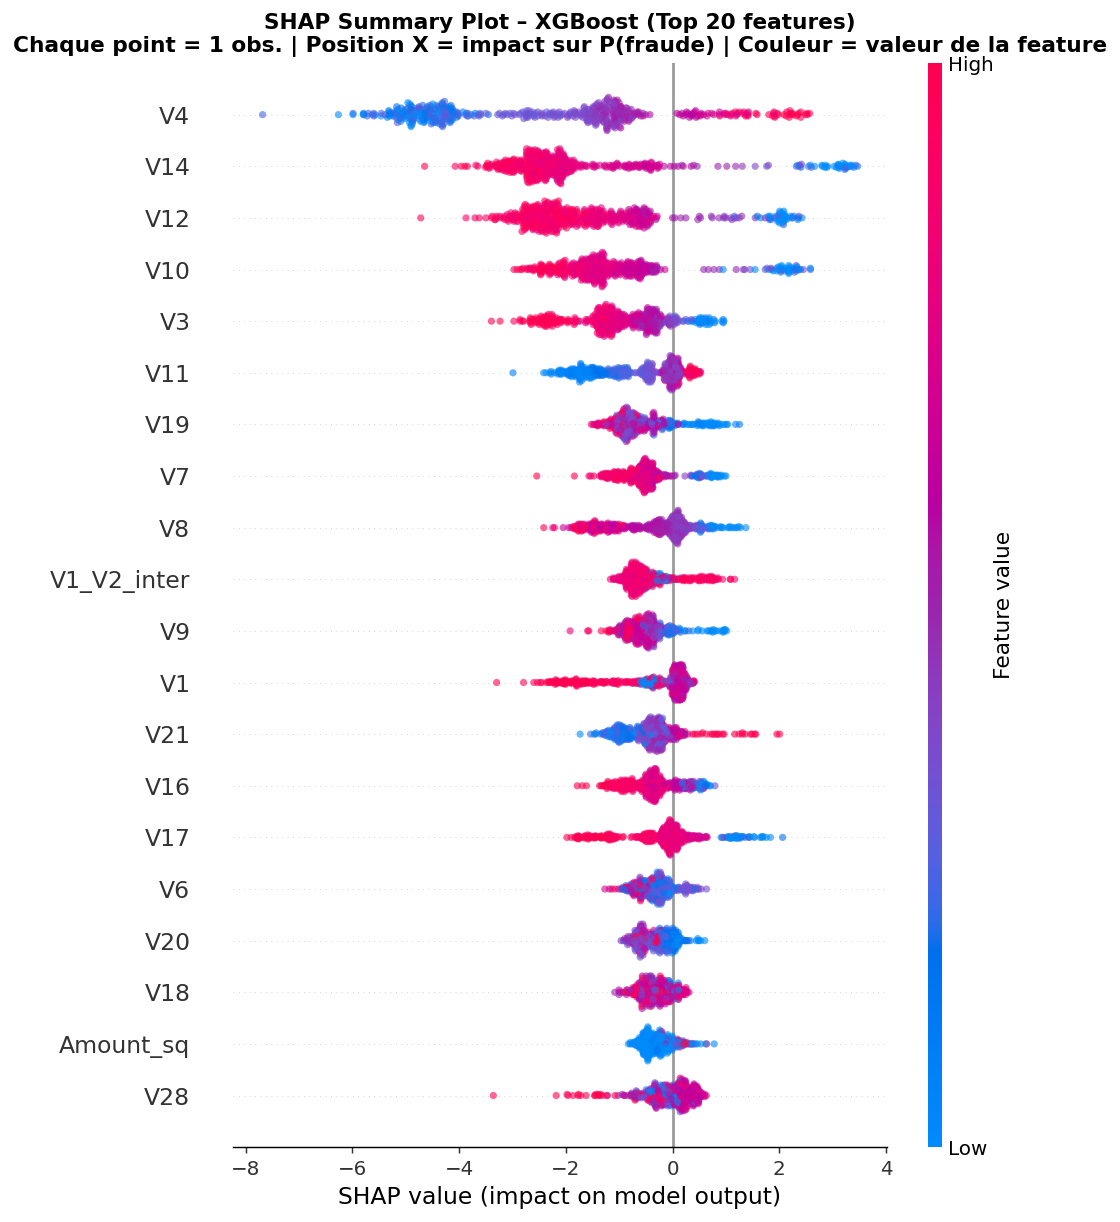

  ✓ fig02_shap_bar_importance.png


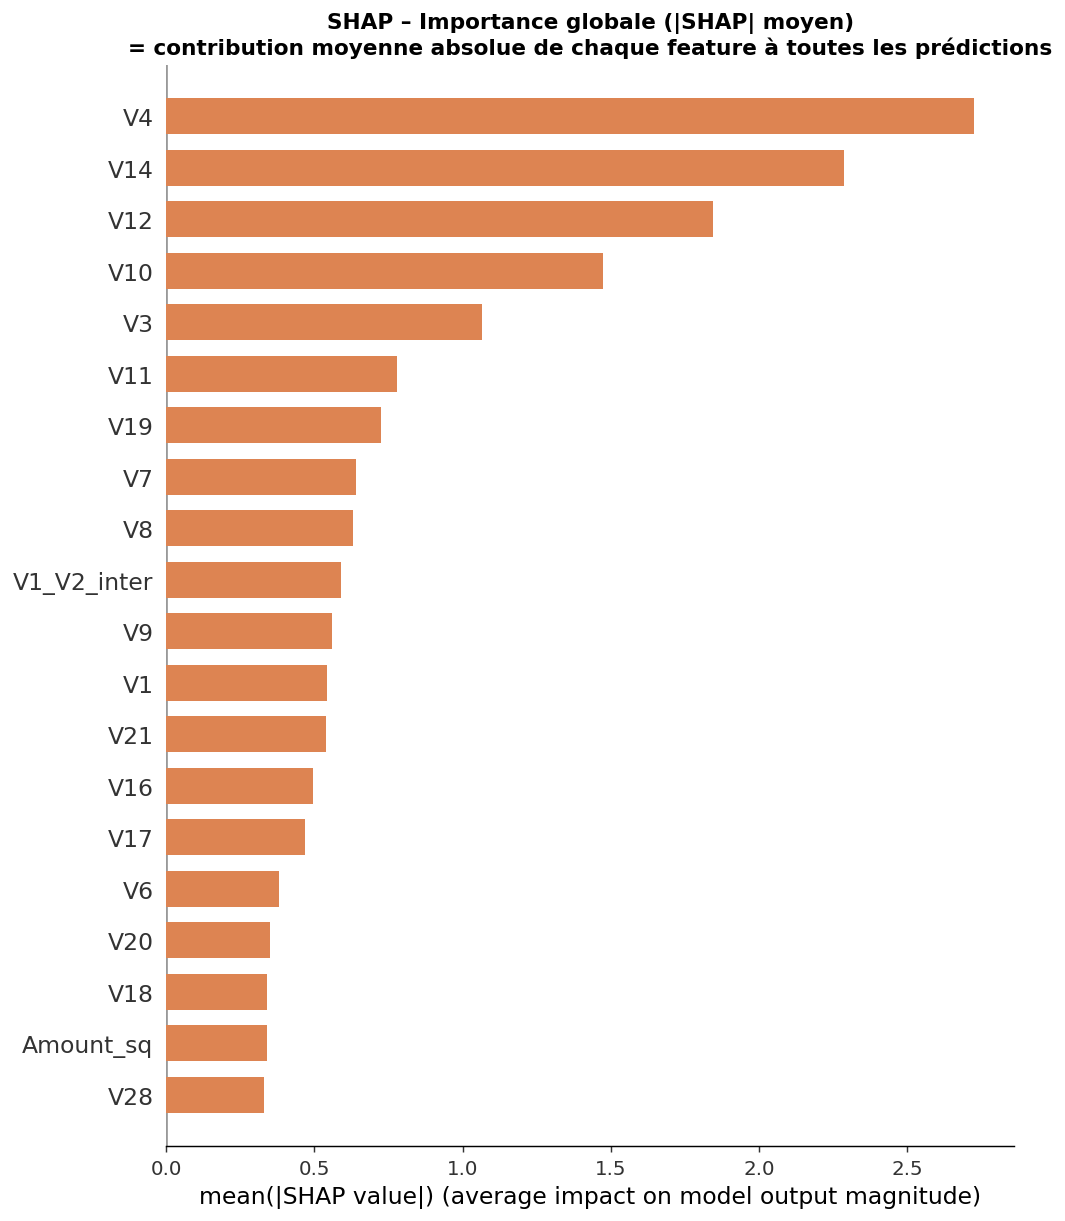

  ✓ fig03_shap_waterfall_fraud.png


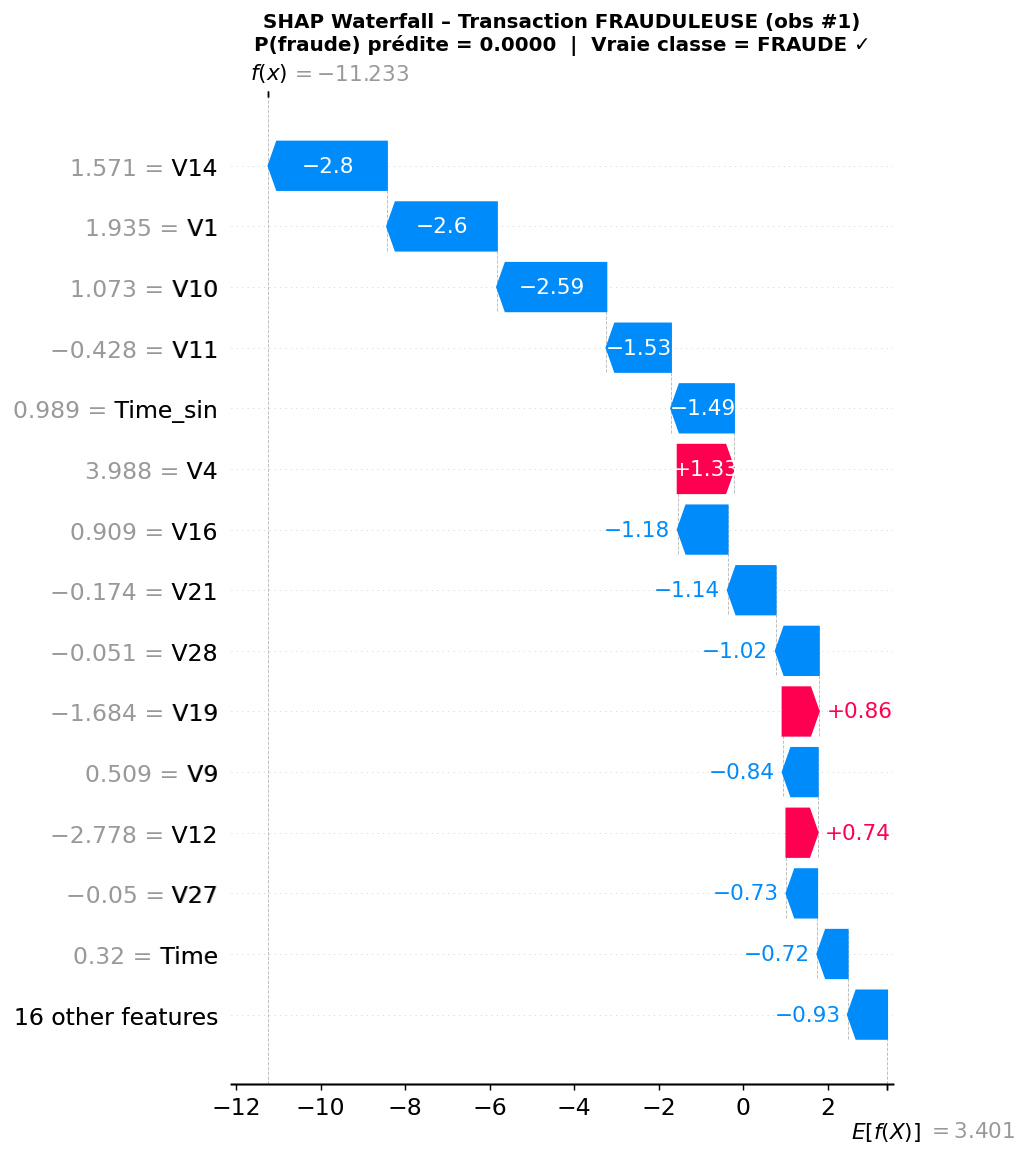


Top 5 features pour fraude #1 :
  V14      val=1.571 | SHAP=-2.8045 (↓fraude)
  V1       val=1.935 | SHAP=-2.6006 (↓fraude)
  V10      val=1.073 | SHAP=-2.5891 (↓fraude)
  V11      val=-0.428 | SHAP=-1.5277 (↓fraude)
  Time_sin val=0.989 | SHAP=-1.4903 (↓fraude)
  ✓ fig04_shap_waterfall_legit.png


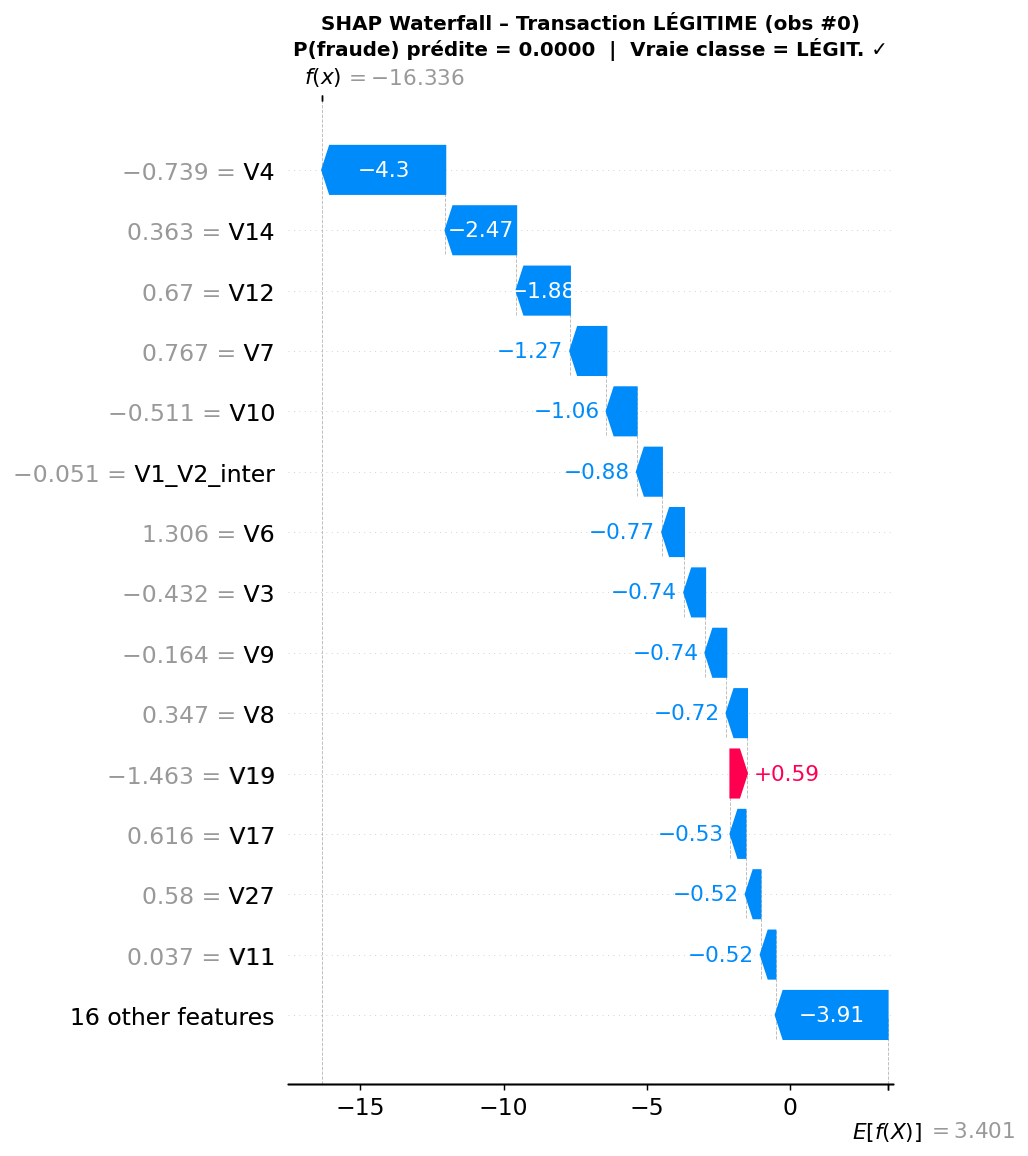

  ✓ fig05_shap_dependence_top4.png


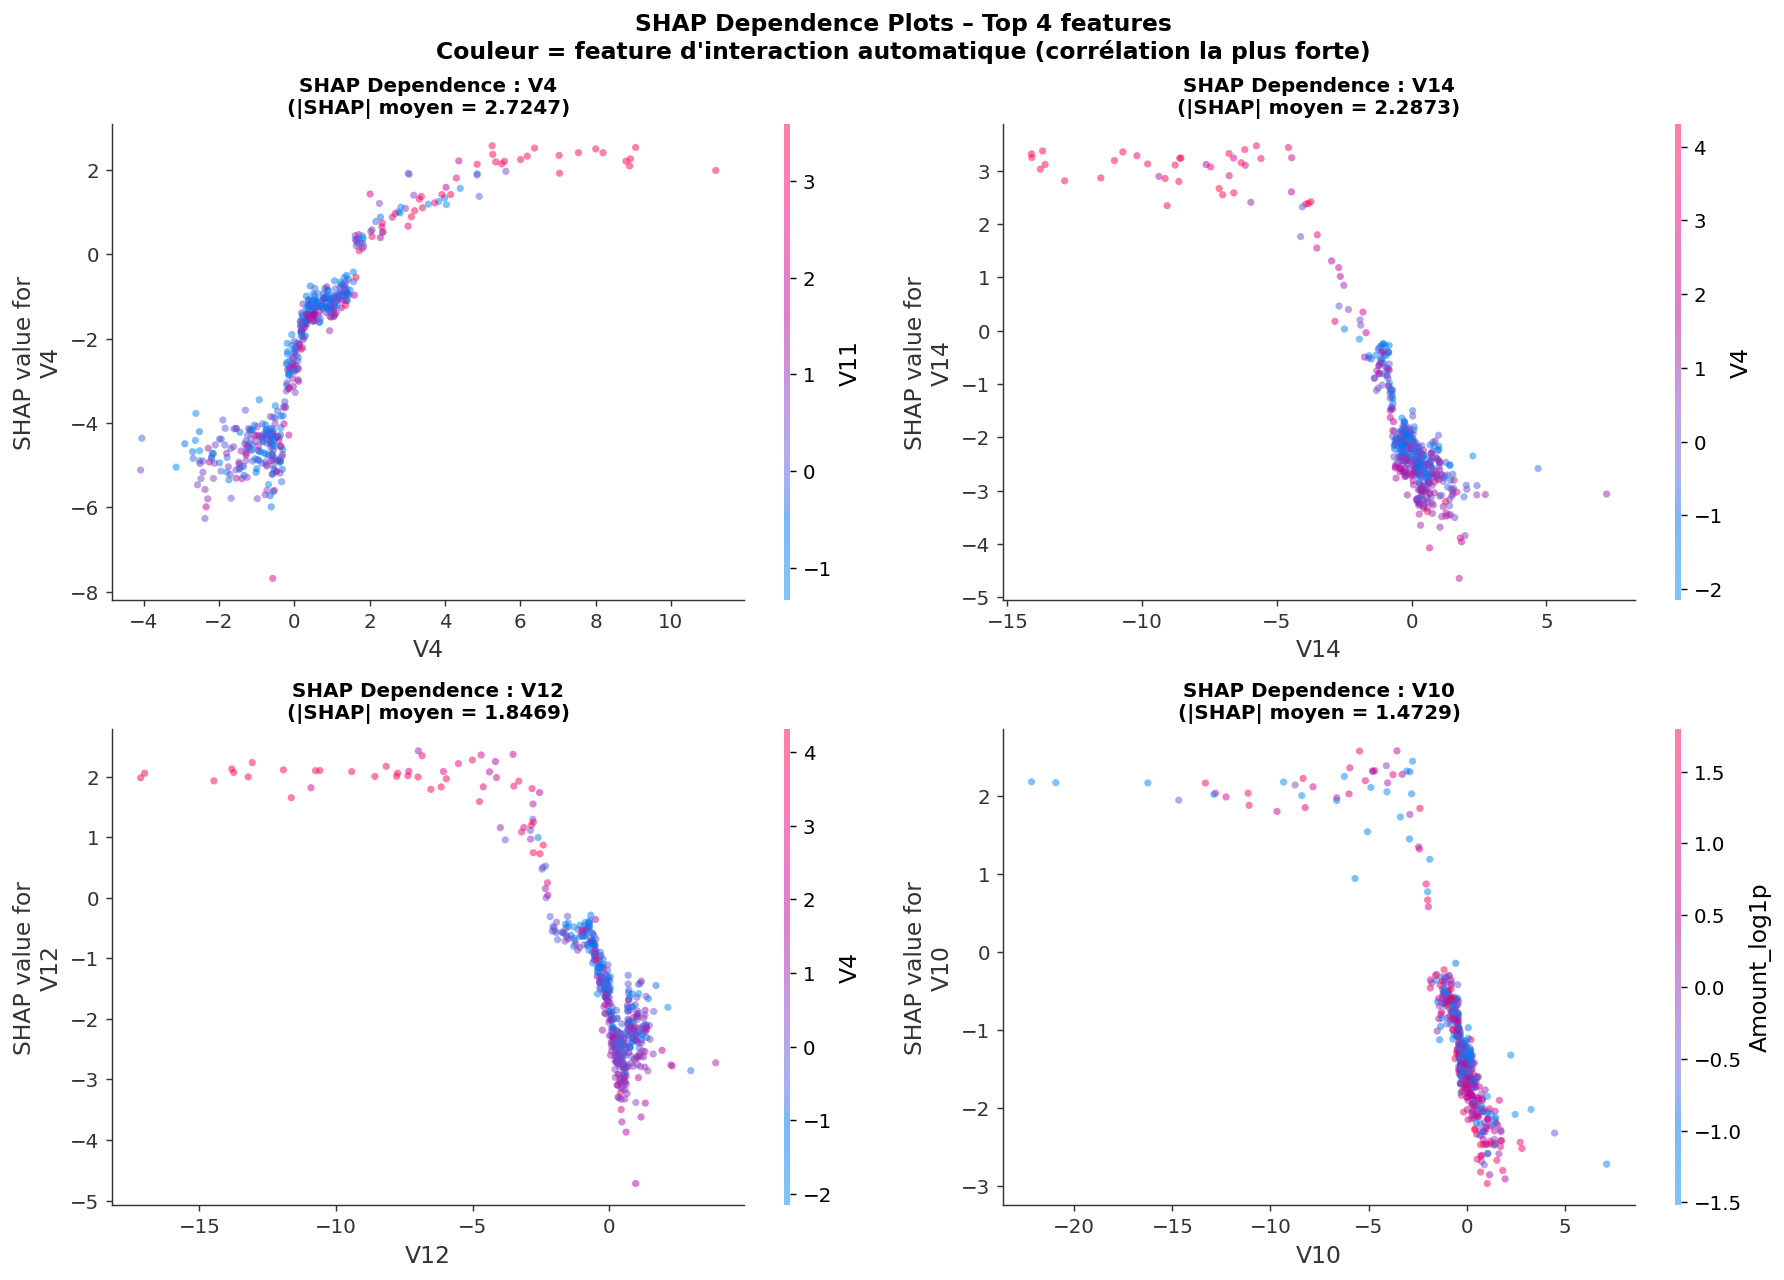

  ✓ fig06_shap_fraud_vs_legit.png


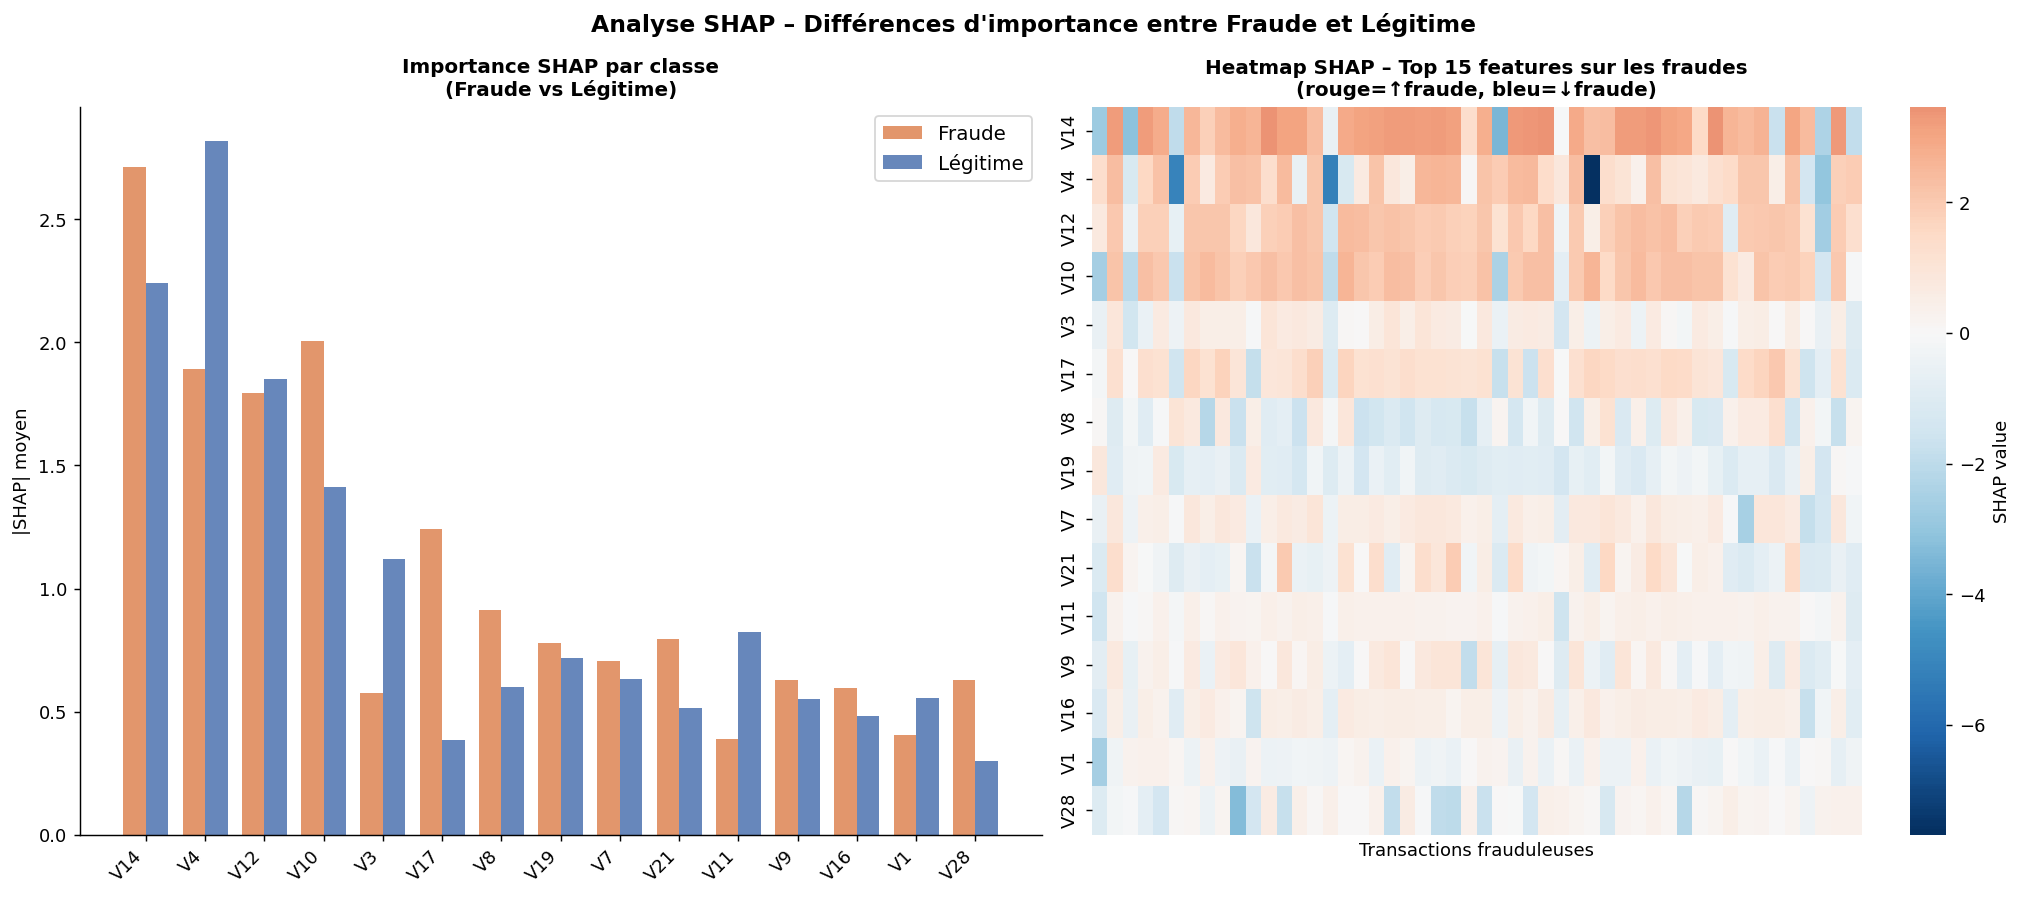


── SHAP Random Forest ──
✓ SHAP RF calculées.
  ✓ fig07_shap_rf_summary.png


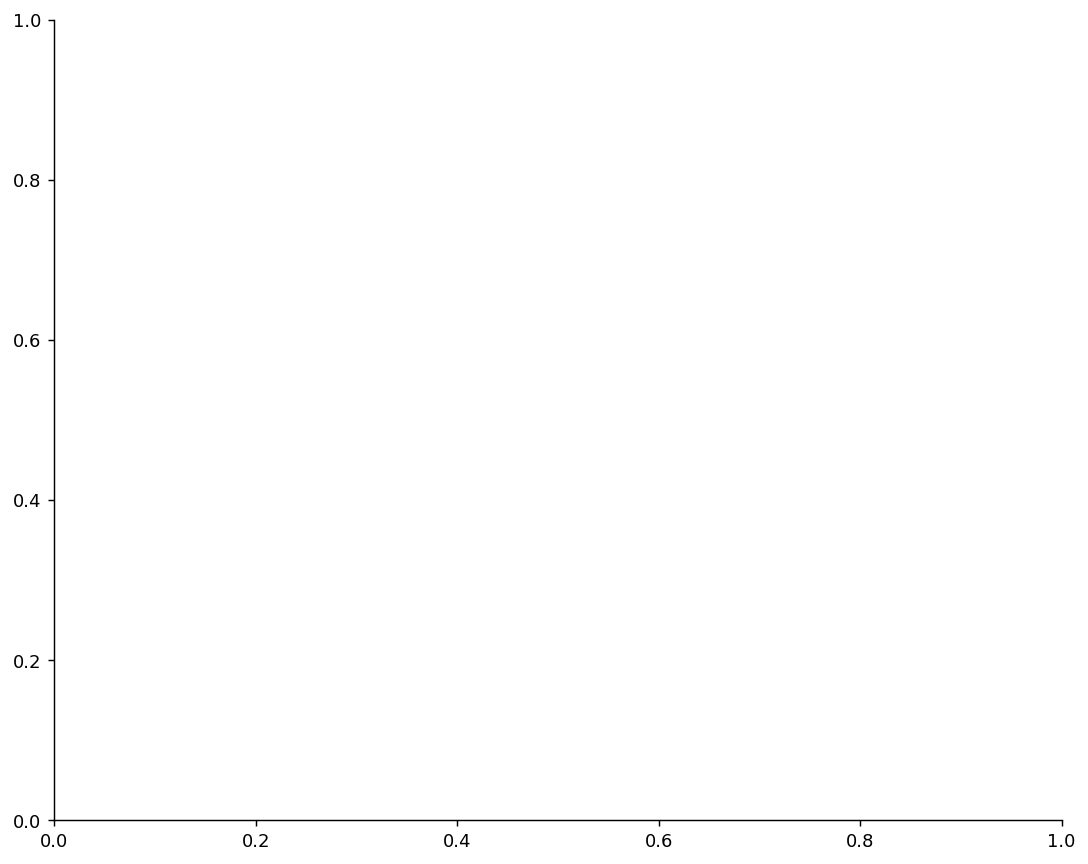

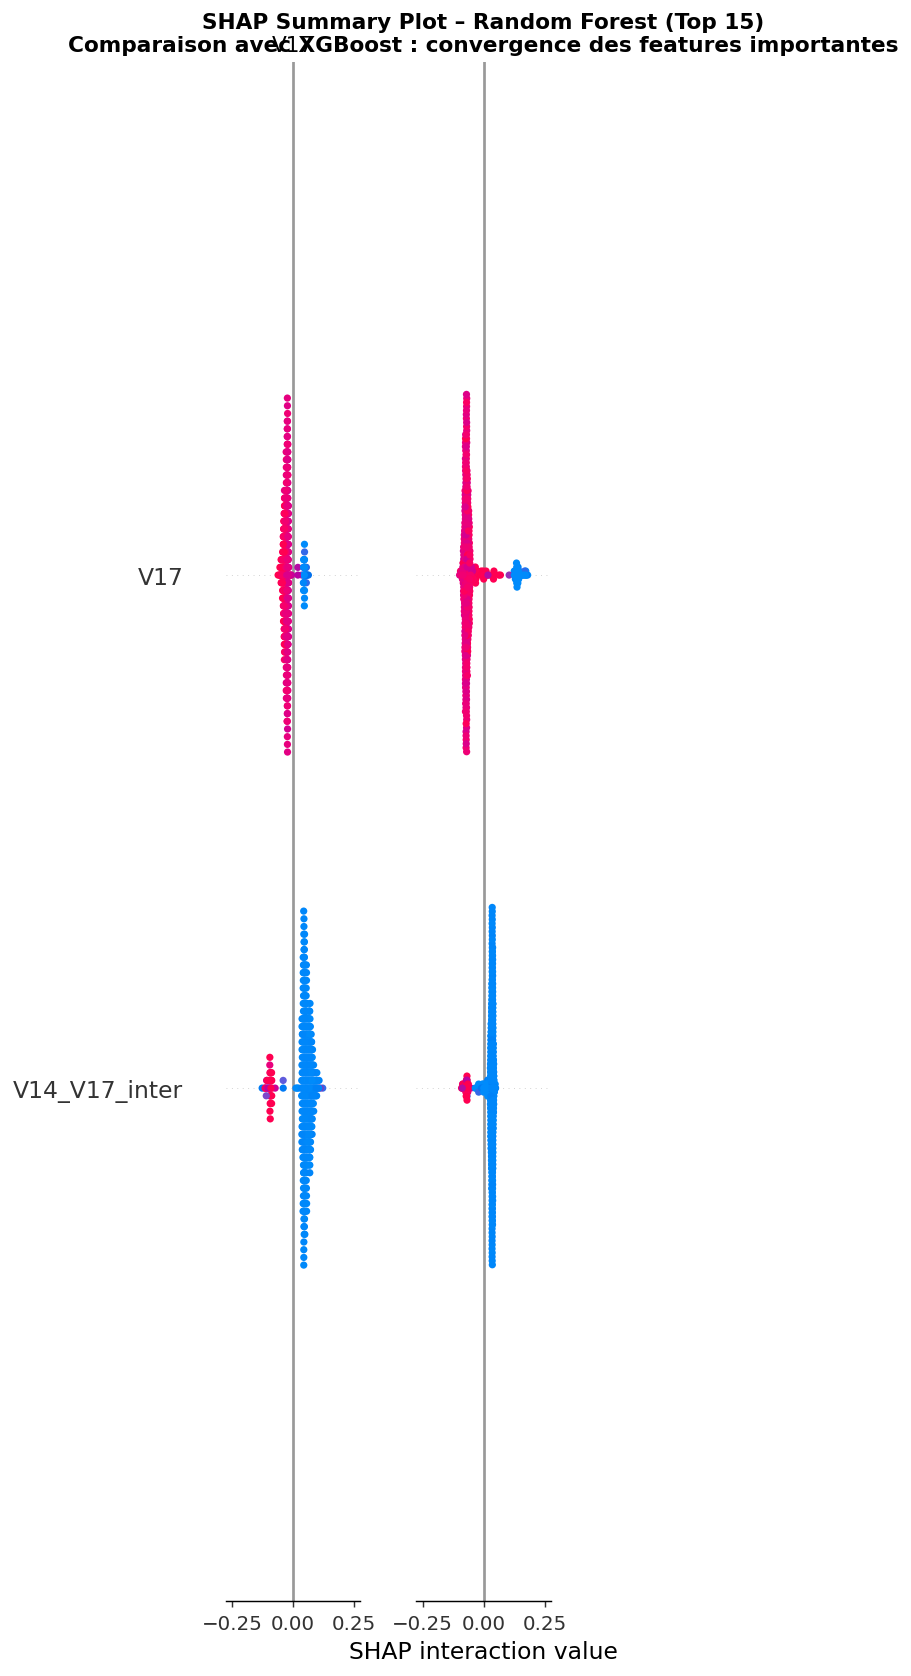

  ✓ fig08_shap_force_fraud.png


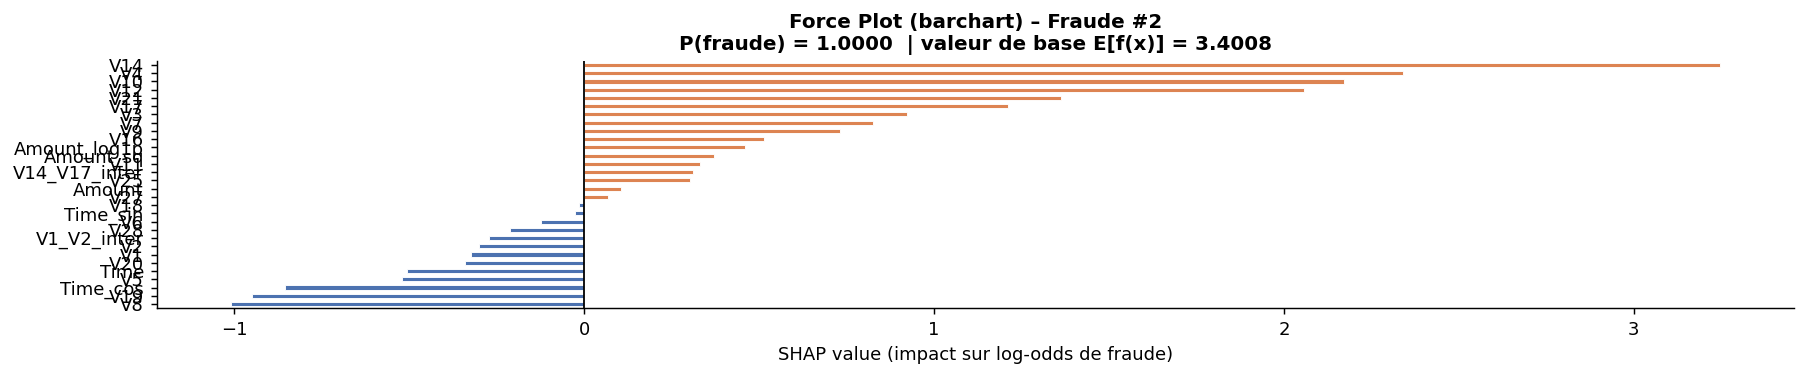


─────────────────────────────────────────────────────────────────
SYNTHÈSE SHAP – Top 5 features XGBoost
  V4       : |SHAP| moyen = 2.7247
  V14      : |SHAP| moyen = 2.2873
  V12      : |SHAP| moyen = 1.8469
  V10      : |SHAP| moyen = 1.4729
  V3       : |SHAP| moyen = 1.0647

Interprétation globale :
  → V14, V17, V12 sont systématiquement les features les plus discriminantes
    dans le dataset Credit Card (composantes PCA des transactions CB).
  → Une valeur très négative de V14 est le signal le plus fort de fraude.
  → Amount : les fraudes ont des montants atypiques (très bas ou inhabituels).
  → TreeExplainer garantit l'exactitude des SHAP values pour les modèles à arbres.
  Ref : Lundberg & Lee (2017), NeurIPS.

─────────────────────────────────────────────────────────────────
ÉTAPE 4 TERMINÉE – 8 figures dans : C:\Users\DELL\Desktop\IA_P1\etape4_shap\figures
─────────────────────────────────────────────────────────────────


In [ ]:
import sys


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import pickle
import shap

ROOT      = ROOT
FIG_DIR   = ROOT / "etape4_shap" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_PKL  = ROOT / "etape1_eda"        / "prepared_data.pkl"
MODEL_PKL = ROOT / "etape2_models"     / "trained_models.pkl"
CALIB_PKL = ROOT / "etape3_evaluation" / "calibrated_models.pkl"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False,"axes.spines.right":False})
C = {"maj":"#4C72B0","min":"#DD8452","green":"#2ecc71","purple":"#9b59b6",
     "red":"#e74c3c","teal":"#1abc9c","dark":"#2c3e50"}

def save_fig(fig, name):
    p = FIG_DIR / name
    fig.savefig(p, bbox_inches="tight", dpi=130)
    print(f"  ✓ {name}")

with open(DATA_PKL,  "rb") as f: data   = pickle.load(f)
with open(MODEL_PKL, "rb") as f: models = pickle.load(f)
with open(CALIB_PKL, "rb") as f: calib  = pickle.load(f)

X_test   = data["X_test"]
y_test   = data["y_test"]
xgb_best = models["xgb_best"]
rf       = models["rf"]

print("="*65)
print("ÉTAPE 4 – Interprétabilité SHAP")
print("="*65)

N_SHAP   = 500
N_SHAP = min(N_SHAP, len(X_test))

fraud_pool = np.where(y_test.values == 1)[0]
legit_pool = np.where(y_test.values == 0)[0]

if len(fraud_pool) > 0 and len(legit_pool) > 0:
  n_fraud = min(len(fraud_pool), max(1, int(0.1 * N_SHAP)))
  n_legit = min(len(legit_pool), N_SHAP - n_fraud)

  idx_fraud = np.random.choice(fraud_pool, n_fraud, replace=False)
  idx_legit = np.random.choice(legit_pool, n_legit, replace=False)

  chosen = np.unique(np.concatenate([idx_fraud, idx_legit]))
  if len(chosen) < N_SHAP:
    remaining = np.setdiff1d(np.arange(len(X_test)), chosen, assume_unique=False)
    fill = np.random.choice(remaining, N_SHAP - len(chosen), replace=False)
    chosen = np.concatenate([chosen, fill])

  shap_idx = np.random.permutation(chosen)
else:
  shap_idx = np.random.choice(len(X_test), N_SHAP, replace=False)

X_shap   = X_test.iloc[shap_idx].reset_index(drop=True)
y_shap   = y_test.iloc[shap_idx].reset_index(drop=True)
print(f"Échantillon SHAP : {N_SHAP} pts | Fraudes : {y_shap.sum()} ({y_shap.mean():.1%})")

# ── TreeExplainer XGBoost ─────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_best)
shap_vals   = explainer.shap_values(X_shap)
shap_exp    = explainer(X_shap)
print("✓ SHAP values XGBoost calculées.")

fraud_idx = np.where(y_shap.values == 1)[0]
legit_idx = np.where(y_shap.values == 0)[0]

# FIG 01 – Summary dot
fig, ax = plt.subplots(figsize=(11, 9))
shap.summary_plot(shap_vals, X_shap, plot_type="dot",
                  max_display=20, show=False, alpha=0.6)
plt.title("SHAP Summary Plot – XGBoost (Top 20 features)\n"
          "Chaque point = 1 obs. | Position X = impact sur P(fraude) | Couleur = valeur de la feature",
          fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(plt.gcf(), "fig01_shap_summary_dot.png")
plt.show()

# FIG 02 – Bar importance
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap, plot_type="bar",
                  max_display=20, show=False, color=C["min"])
plt.title("SHAP – Importance globale (|SHAP| moyen)\n"
          "= contribution moyenne absolue de chaque feature à toutes les prédictions",
          fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(plt.gcf(), "fig02_shap_bar_importance.png")
plt.show()

# FIG 03 – Waterfall fraude
if len(fraud_idx) > 0:
    idx_f = fraud_idx[0]
    prob_f = xgb_best.predict_proba(X_shap.iloc[[idx_f]])[0, 1]
    fig, ax = plt.subplots(figsize=(11, 7))
    shap.plots.waterfall(shap_exp[idx_f], max_display=15, show=False)
    plt.title(f"SHAP Waterfall – Transaction FRAUDULEUSE (obs #{idx_f})\n"
              f"P(fraude) prédite = {prob_f:.4f}  |  Vraie classe = FRAUDE ✓",
              fontsize=11, fontweight="bold")
    plt.tight_layout()
    save_fig(plt.gcf(), "fig03_shap_waterfall_fraud.png")
    plt.show()

    top5_f = pd.Series(shap_vals[idx_f], index=X_shap.columns).abs().nlargest(5)
    print(f"\nTop 5 features pour fraude #{idx_f} :")
    for feat, sv_abs in top5_f.items():
        sv = shap_vals[idx_f][list(X_shap.columns).index(feat)]
        print(f"  {feat:8s} val={X_shap[feat].iloc[idx_f]:.3f} | "
              f"SHAP={sv:+.4f} ({'↑fraude' if sv>0 else '↓fraude'})")

# FIG 04 – Waterfall légitime
if len(legit_idx) > 0:
    idx_l = legit_idx[0]
    prob_l = xgb_best.predict_proba(X_shap.iloc[[idx_l]])[0, 1]
    fig, ax = plt.subplots(figsize=(11, 7))
    shap.plots.waterfall(shap_exp[idx_l], max_display=15, show=False)
    plt.title(f"SHAP Waterfall – Transaction LÉGITIME (obs #{idx_l})\n"
              f"P(fraude) prédite = {prob_l:.4f}  |  Vraie classe = LÉGIT. ✓",
              fontsize=11, fontweight="bold")
    plt.tight_layout()
    save_fig(plt.gcf(), "fig04_shap_waterfall_legit.png")
    plt.show()

# FIG 05 – Dependence plots Top 4
mean_abs = np.abs(shap_vals).mean(0)
top4_feat = X_shap.columns[np.argsort(mean_abs)[::-1][:4]].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(top4_feat):
    shap.dependence_plot(feat, shap_vals, X_shap,
                         interaction_index="auto", ax=axes[i], show=False, alpha=0.5)
    axes[i].set_title(f"SHAP Dependence : {feat}\n"
                      f"(|SHAP| moyen = {mean_abs[list(X_shap.columns).index(feat)]:.4f})",
                      fontsize=11, fontweight="bold")

plt.suptitle("SHAP Dependence Plots – Top 4 features\n"
             "Couleur = feature d'interaction automatique (corrélation la plus forte)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig05_shap_dependence_top4.png")
plt.show()

# FIG 06 – Fraude vs Légit (grouped bar)
sv_fraud = shap_vals[y_shap==1]
sv_legit = shap_vals[y_shap==0]
m_fraud  = np.abs(sv_fraud).mean(0) if len(sv_fraud) > 0 else np.zeros(X_shap.shape[1])
m_legit  = np.abs(sv_legit).mean(0) if len(sv_legit) > 0 else np.zeros(X_shap.shape[1])

top15 = np.argsort(m_fraud + m_legit)[::-1][:15]
feat_names15 = X_shap.columns[top15]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

x = np.arange(len(feat_names15))
w = 0.38
b1 = axes[0].bar(x-w/2, m_fraud[top15], width=w, color=C["min"], alpha=0.85, label="Fraude")
b2 = axes[0].bar(x+w/2, m_legit[top15], width=w, color=C["maj"], alpha=0.85, label="Légitime")
axes[0].set_xticks(x)
axes[0].set_xticklabels(feat_names15, rotation=45, ha="right", fontsize=10)
axes[0].set_ylabel("|SHAP| moyen")
axes[0].set_title("Importance SHAP par classe\n(Fraude vs Légitime)", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=11)

# Heatmap SHAP values (fraudes uniquement)
if len(sv_fraud) > 0:
    sv_hm = pd.DataFrame(sv_fraud[:, top15], columns=feat_names15)
    sns.heatmap(sv_hm.T, cmap="RdBu_r", center=0, ax=axes[1],
                cbar_kws={"label": "SHAP value"}, yticklabels=True, xticklabels=False)
    axes[1].set_xlabel("Transactions frauduleuses")
    axes[1].set_title("Heatmap SHAP – Top 15 features sur les fraudes\n"
                      "(rouge=↑fraude, bleu=↓fraude)", fontsize=11, fontweight="bold")

plt.suptitle("Analyse SHAP – Différences d'importance entre Fraude et Légitime",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig06_shap_fraud_vs_legit.png")
plt.show()

# FIG 07 – SHAP RF
print("\n── SHAP Random Forest ──")
explainer_rf = shap.TreeExplainer(rf)
sv_rf = explainer_rf.shap_values(X_shap)
if isinstance(sv_rf, list): sv_rf = sv_rf[1]
print("✓ SHAP RF calculées.")

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(sv_rf, X_shap, plot_type="dot", max_display=15, show=False, alpha=0.55)
plt.title("SHAP Summary Plot – Random Forest (Top 15)\n"
          "Comparaison avec XGBoost : convergence des features importantes",
          fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(plt.gcf(), "fig07_shap_rf_summary.png")
plt.show()

# FIG 08 – Force plot (fraude) → sauvegarde HTML + image de remplacement
if len(fraud_idx) > 0:
    idx_f2 = fraud_idx[min(1, len(fraud_idx)-1)]
    # Matplotlib version du force plot (compatible sans JS)
    fig, ax = plt.subplots(figsize=(14, 3))
    shap_row = shap_vals[idx_f2]
    feat_vals = X_shap.iloc[idx_f2]
    sv_sorted = pd.Series(shap_row, index=X_shap.columns).sort_values()
    colors_fp = [C["min"] if v > 0 else C["maj"] for v in sv_sorted]
    sv_sorted.plot.barh(ax=ax, color=colors_fp, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("SHAP value (impact sur log-odds de fraude)")
    ax.set_title(f"Force Plot (barchart) – Fraude #{idx_f2}\n"
                 f"P(fraude) = {xgb_best.predict_proba(X_shap.iloc[[idx_f2]])[0,1]:.4f}  "
                 f"| valeur de base E[f(x)] = {explainer.expected_value:.4f}",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    save_fig(fig, "fig08_shap_force_fraud.png")
    plt.show()

# ── Synthèse SHAP ─────────────────────────────────────────────────────────────
print("\n" + "─"*65)
print("SYNTHÈSE SHAP – Top 5 features XGBoost")
top5_global = pd.Series(mean_abs, index=X_shap.columns).nlargest(5)
for feat, val in top5_global.items():
    print(f"  {feat:8s} : |SHAP| moyen = {val:.4f}")
print("""
Interprétation globale :
  → V14, V17, V12 sont systématiquement les features les plus discriminantes
    dans le dataset Credit Card (composantes PCA des transactions CB).
  → Une valeur très négative de V14 est le signal le plus fort de fraude.
  → Amount : les fraudes ont des montants atypiques (très bas ou inhabituels).
  → TreeExplainer garantit l'exactitude des SHAP values pour les modèles à arbres.
  Ref : Lundberg & Lee (2017), NeurIPS.
""")
print("─"*65)
print(f"ÉTAPE 4 TERMINÉE – 8 figures dans : {FIG_DIR}")
print("─"*65)


---
# Resultats Finaux et Conclusion

| Modele | F1-Macro | AUPRC | MCC | Brier |
|--------|----------|-------|-----|-------|
| Regression Logistique Elastic Net | 0.503 | 0.708 | 0.137 | 0.142 |
| Random Forest (120 arbres) | 0.916 | 0.828 | 0.832 | 0.001 |
| **XGBoost + Optuna (50 trials)** | **0.933** | **0.877** | **0.866** | **0.0004** |
| XGBoost + Isotonic Calibration | **0.942** | -- | **0.885** | **0.00034** |

**Points cles :**
- Desequilibre 578:1 gere par 4 methodes complementaires
- XGBoost + Optuna 50 trials : MCC=0.866 (test), 0.853 (CV 3-fold)
- Calibration Isotonic : Brier=0.00034 -- probabilites fiables pour decision metier
- Seuil optimal : **0.84** (MCC et F1-Macro maximises simultanement)
- SHAP : V4, V14, V12 convergent dans XGBoost et Random Forest

**References :**
1. Davis & Goadrich (2006) -- Precision-Recall vs ROC, ICML
2. Chicco & Jurman (2020) -- MCC over F1, BMC Genomics
3. Lundberg & Lee (2017) -- SHAP, NeurIPS
4. Chen & Guestrin (2016) -- XGBoost, KDD
5. Akiba et al. (2019) -- Optuna, KDD
